# Mietpreis-Vorhersage Schweiz – Saubere ML-Pipeline (v3)

Dieses Notebook ist eine bereinigte Version von `model_v2.ipynb`. Die wichtigsten Änderungen:

- **Ein einziger, sauberer Train/Eval-Split.** Kein `concat → head/tail`-Recovery, kein `fit_transform` auf kombinierten Train+Eval-Daten.
- **Pipelines** für lineare Modelle, damit Skalierung *innerhalb* der Cross-Validation passiert (kein Leakage).
- **Zentrale Feature-Sets** (`FEATURES_SMALL`, `FEATURES_ALL`, `FEATURES_ENGINEERED`) – Training, Evaluation und Final Prediction nutzen exakt dieselbe Spaltenliste in derselben Reihenfolge.
- **Korrekte Metriken**: `np.sqrt(mean_squared_error(...))` statt `squared=False`, `median_absolute_error` ohne fälschliches `np.sqrt(...)`.
- **Fehleranalyse** nach Preisgruppen, Overfitting-Diagnose, optionaler Group-Split.

## Inhalt

1. Setup & Imports
2. Daten laden
3. Spalten umbenennen
4. Datenqualität prüfen
5. Duplikate und Ausreißer analysieren
6. Feature Engineering
7. Feature-Sets zentral definieren
8. Sauberer Train/Eval-Split
9. Modell-Pipelines definieren
10. Modelle fair vergleichen
11. Train-vs-Eval-Metriken (Visualisierung)
12. Overfitting-Diagnose
13. Cross-Validation
14. Visualisierungen (Actual vs Predicted)
    - 14b. Prediction Curves – Vergleich der Vorhersagekurven
    - 14c. Demo: Underfitting / Good Fit / Overfitting
15. Residual Analysis
16. Fehleranalyse nach Preisgruppen
17. Feature Importance
18. Bestes Modell auswählen
19. Finale Prediction (mit Spaltencheck)
20. Optional: Group Split nach Koordinaten
21. Geo-Analyse und Geo-Clustering
    - 21.1 Geo-Spalten prüfen
    - 21.2 Geo-EDA (Scatter colored by price / price_per_sqm)
    - 21.3 KMeans Clustering – verschiedene Clusterzahlen testen
    - 21.4 Cluster visualisieren & Preisstatistik
    - 21.5 Modellvergleich: ohne vs. mit Geo-Cluster
    - 21.6 Optional: Elevation ins Clustering aufnehmen
    - 21.7 Lineare Modelle mit OneHotEncoded geo_cluster
    - 21.8 Optional: DBSCAN (Analyse-only)
    - 21.9 Geo-Prediction-Kurve entlang `east`
    - 21.10 Zusammenfassung Geo
22. Erweiterte Verbesserungen
    - 22.1 Missing-Data-Diagnose & Imputation
    - 22.2 Log-transformiertes Target
    - 22.3 Hyperparameter-Tuning (RandomizedSearchCV)
    - 22.4 Stratifizierter Train/Eval-Split
    - 22.5 Learning Curve
    - 22.6 Validation Curve
    - 22.7 Prediction Intervals (Quantile Regression)
    - 22.8 SHAP — Erklärbarkeit pro Vorhersage
    - 22.9 IsolationForest — Outlier-Erkennung
    - 22.10 Feature Selection mit RFECV
    - 22.11 Modell persistieren mit joblib
    - 22.12 Robuste Inferenz bei fehlenden Features
    - 22.13 Drift-Check Train vs. Eval (KS-Test)
    - 22.14 Bias-Analyse pro Geo-Cluster
    - 22.15 Konsolidierter Modellvergleich
23. Weitere Erweiterungen (Runde 2)
    - 23.1 Multi-Metric finaler Vergleich
    - 23.2 Stacking-Regressor
    - 23.3 Q-Q Plot + Heteroskedastizität
    - 23.4 Partial Dependence Plots für Top-Features
    - 23.5 Bootstrap-CIs für RMSE
    - 23.6 cross_validate für Multi-Metric CV
    - 23.7 Actual-vs-Predicted für alle Modelle
    - 23.8 Feature-Importance-Vergleich (Multi-Method)
    - 23.9 Stabilitäts-Score für Modellauswahl
    - 23.10 HalvingRandomSearchCV
    - 23.11 Conformal Prediction (formale Coverage)
    - 23.12 KNN-Distance-Features
    - 23.13 Pipeline.set_output('pandas')
    - 23.14 Statistischer Modellvergleich (Bootstrap A vs B)
    - 23.15 Modell-Karte
    - 23.16 Konfiguration als dataclass + requirements.txt
    - 23.17 Konsolidierter Vergleich aller Varianten
24. Runde 3 — Bug-Fixes, End-to-End-Pipeline und Hold-Out
    - 24.1 Bug-Fixes (set_config-Reset + KNN-Leakage-Warnung)
    - 24.2 End-to-End RentPredictor-Klasse
    - 24.3 Sanity-Tests der Predictions
    - 24.4 v2 vs v3 Vergleich
    - 24.5 Datasheet for the Dataset
    - 24.6 Hold-Out-Test-Split (Train/Val/Test)
    - 24.7 Vollständige Artefakt-Persistenz
25. Action Items aus der Output-Analyse
    - 25.1 Anti-Overfitting LightGBM
    - 25.2 Top-10 schlechteste Vorhersagen

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, GroupShuffleSplit
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    median_absolute_error, r2_score
)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Optional Boosting libraries — Notebook läuft auch ohne diese.
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

RANDOM_STATE = 42
TEST_SIZE    = 0.2

print(f'XGBoost verfügbar : {HAS_XGB}')
print(f'LightGBM verfügbar: {HAS_LGBM}')

XGBoost verfügbar : True
LightGBM verfügbar: True


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt

FIG_DIR = Path("../../docs/final-report/fig")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(filename, fig=None, dpi=220):
    """
    Saves the current matplotlib figure or a given figure into docs/final-report/fig.
    """
    if fig is None:
        fig = plt.gcf()

    output_path = FIG_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {output_path}")

## 2. Daten laden

Wir laden den vollständigen Datensatz **einmal** und splitten erst später. Damit ist sichergestellt, dass dieselbe Stichprobe konsistent durch das Notebook läuft und kein versehentliches Re-Splitten oder Recovery via `head/tail` möglich ist.

In [3]:
DATA_PATH = '../external-sources/output_csv/model.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Geladen: {df_raw.shape[0]} Zeilen × {df_raw.shape[1]} Spalten')
df_raw.head()

Geladen: 4536 Zeilen × 12 Spalten


,area_sqm,rooms,price_cold,population,oev_score,solar_class,elevation_m,lv95_east,lv95_north,gbauj,ganzwhg,garea
0,34,2,850,44,2043.0,2.0,572.9,2687446.25,1248599.000,1971,1,192.0
1,108,4,1990,107,5656.0,3.0,672.3,2642156.00,1130267.625,1974,34,2000.0
2,97,4,1520,184,12617.0,4.0,439.6,2597233.25,1226600.375,2017,18,367.0
3,23,1,1396,129,18439.0,4.0,430.4,2532786.25,1155625.250,1948,50,731.0
4,76,3,1400,48,717.0,3.0,743.6,2583429.75,1231621.000,2018,17,587.0


## 3. Spalten umbenennen

Sprechende, kurze Namen. Das Mapping ist explizit, damit klar ist, welche Quellspalte wohin geht.

In [4]:
column_renames = {
    'area_sqm':    'area',
    'rooms':       'rooms',
    'price_cold':  'price',
    'population':  'population',
    'oev_score':   'oev',
    'solar_class': 'solar',
    'elevation_m': 'elevation',
    'lv95_east':   'east',
    'lv95_north':  'north',
    'gbauj':       'year_built',
    'ganzwhg':     'apartments',
    'garea':       'land_area',
}

df = df_raw.rename(columns=column_renames).copy()
print('Spalten nach Rename:', df.columns.tolist())

Spalten nach Rename: ['area', 'rooms', 'price', 'population', 'oev', 'solar', 'elevation', 'east', 'north', 'year_built', 'apartments', 'land_area']


## 4. Datenqualität prüfen

In [5]:
print('Shape:', df.shape)
df.info()

Shape: (4536, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4536 entries, 0 to 4535
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        4536 non-null   int64  
 1   rooms       4536 non-null   int64  
 2   price       4536 non-null   int64  
 3   population  4536 non-null   int64  
 4   oev         4536 non-null   float64
 5   solar       4536 non-null   float64
 6   elevation   4536 non-null   float64
 7   east        4536 non-null   float64
 8   north       4536 non-null   float64
 9   year_built  4536 non-null   int64  
 10  apartments  4536 non-null   int64  
 11  land_area   4536 non-null   float64
dtypes: float64(6), int64(6)
memory usage: 425.4 KB


In [6]:
print('Fehlende Werte je Spalte:')
print(df.isna().sum())
print()
print('Duplikate (komplette Zeilen):', df.duplicated().sum())

Fehlende Werte je Spalte:
area          0
rooms         0
price         0
population    0
oev           0
solar         0
elevation     0
east          0
north         0
year_built    0
apartments    0
land_area     0
dtype: int64

Duplikate (komplette Zeilen): 325


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area,4536.0,7.752403e+01,32.103016,1.00,5.600000e+01,76.000,9.500000e+01,324.0
rooms,4536.0,2.802249e+00,1.102830,1.00,2.000000e+00,3.000,4.000000e+00,15.0
price,4536.0,1.816199e+03,732.310694,130.00,1.345000e+03,1680.000,2.130000e+03,7700.0
population,4536.0,1.090999e+02,82.577927,3.00,4.900000e+01,90.000,1.440000e+02,602.0
oev,4536.0,9.986069e+03,14960.307365,0.00,1.800000e+03,4911.500,1.154900e+04,135157.0
solar,4536.0,3.092372e+00,1.015459,1.00,2.000000e+00,3.000,4.000000e+00,5.0
elevation,4536.0,4.624071e+02,158.817656,197.70,3.915000e+02,435.600,5.170000e+02,1570.7
east,4536.0,2.640999e+06,69270.961596,2494493.75,2.596506e+06,2645843.625,2.690937e+06,2818550.0
north,4536.0,1.218718e+06,52055.722323,1076962.00,1.178774e+06,1244662.000,1.258623e+06,1286728.5
year_built,4536.0,1.968925e+03,55.641365,1187.00,1.953000e+03,1974.000,2.010000e+03,2026.0


## 5. Duplikate und Ausreißer analysieren

`price_per_sqm` ist eine **Analyse-Größe**, kein Modellfeature: sie enthält das Target und würde zu Target Leakage führen.

In [8]:
TARGET_COL = 'price'

# Vorläufige Feature-Liste für die Duplikatsprüfung – wird in Kapitel 7 sauber finalisiert.
_features_for_dup_check = [
    'east', 'north', 'elevation', 'area', 'rooms', 'year_built',
    'apartments', 'land_area', 'population', 'oev', 'solar'
]

print('Duplikate gesamt          :', df.duplicated().sum())
print('Duplikate Features+Target :', df.duplicated(subset=_features_for_dup_check + [TARGET_COL]).sum())
print('Duplikate nur Features    :', df.duplicated(subset=_features_for_dup_check).sum())

Duplikate gesamt          : 325
Duplikate Features+Target : 325
Duplikate nur Features    : 562


In [9]:
# price_per_sqm NUR für Analyse — explizit nicht als Feature.
df['price_per_sqm'] = df['price'] / df['area']

print('Top 20 nach price_per_sqm (sehr teuer pro m²):')
df.sort_values('price_per_sqm', ascending=False).head(20)

Top 20 nach price_per_sqm (sehr teuer pro m²):


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area,price_per_sqm
3337,1,6,2500,13,225.0,2.0,668.5,2539457.75,1171911.250,2007,1,266.0,2500.000000
3213,1,4,2050,3,916.0,2.0,450.7,2536852.00,1183189.125,1895,1,70.0,2050.000000
427,1,3,1650,64,1691.0,5.0,625.3,2558554.00,1145940.125,1970,12,298.0,1650.000000
2019,1,3,1370,143,2077.0,4.0,450.7,2561697.25,1185393.375,1965,27,402.0,1370.000000
3137,1,3,1370,205,2077.0,1.0,450.9,2561732.00,1185383.000,1910,2,157.0,1370.000000
3068,1,2,1250,123,30274.0,5.0,413.9,2533764.75,1154087.375,1962,54,561.0,1250.000000
422,1,3,900,77,1087.0,4.0,412.5,2594891.25,1245585.625,1979,11,322.0,900.000000
2746,1,3,900,77,1087.0,4.0,412.5,2594891.25,1245585.625,1979,11,322.0,900.000000
71,1,2,860,95,12866.0,1.0,671.2,2746200.00,1254470.125,1918,9,1117.0,860.000000
2904,18,1,2500,231,96716.0,4.0,412.8,2681354.50,1247688.625,1909,41,208.0,138.888889


In [10]:
print('Bottom 20 nach price_per_sqm (sehr billig pro m²):')
df.sort_values('price_per_sqm', ascending=True).head(20)

Bottom 20 nach price_per_sqm (sehr billig pro m²):


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area,price_per_sqm
1444,105,4,200,177,15495.0,3.0,257.4,2611991.75,1267862.875,1891,2,258.0,1.904762
3543,110,3,258,147,1251.0,2.0,443.5,2676175.25,1214992.000,2005,3,101.0,2.345455
411,84,4,245,125,539.0,3.0,565.2,2722051.75,1258093.875,1964,9,313.0,2.916667
553,100,4,300,44,7811.0,2.0,395.5,2690300.75,1283502.125,1926,5,280.0,3.000000
86,100,4,300,44,7811.0,2.0,395.5,2690300.75,1283502.125,1926,5,280.0,3.000000
188,40,2,130,46,12414.0,3.0,727.3,2746243.75,1255577.375,1964,1,159.0,3.250000
2422,300,4,1225,94,2430.0,3.0,634.2,2736227.75,1253378.625,1964,12,454.0,4.083333
4477,324,4,1900,53,11140.0,3.0,716.4,2746006.25,1254976.625,1918,3,189.0,5.864198
3179,159,4,1170,213,2495.0,3.0,280.9,2614673.25,1264600.125,1980,9,586.0,7.358491
4380,183,4,1460,57,2858.0,2.0,353.6,2664160.50,1270660.750,1900,3,126.0,7.978142


In [11]:
# Verdächtige Zeilen
print('area == 1:', (df['area'] == 1).sum())
print('area  < 10:', (df['area'] < 10).sum())
print('price < 300:', (df['price'] < 300).sum())
print('rooms > 10:', (df['rooms'] > 10).sum())
print('rooms < 1 :', (df['rooms'] < 1).sum())

area == 1: 9
area  < 10: 10
price < 300: 4
rooms > 10: 1
rooms < 1 : 0


**Filterregel — fachlich begründet:**

- `area >= 10`: Wohnungen mit < 10 m² sind in der Schweiz kaum realistisch und meist Datenfehler.
- `price >= 300`: Kaltmieten unter 300 CHF sind sehr ungewöhnlich und meist Erfassungsfehler.

Wir entfernen **nicht blind** Ausreißer — die Regeln sind explizit dokumentiert. Wenn die Domain-Annahmen sich ändern, ist die Stelle leicht zu finden.

In [12]:
n_before = len(df)

df_clean = df[
    (df['area']  >= 10) &
    (df['price'] >= 300)
].copy()

n_after_filter = len(df_clean)

df_model = df_clean.drop_duplicates().copy()
n_after_dedup = len(df_model)

print(f'Vorher                         : {n_before}')
print(f'Nach Outlier-Filter            : {n_after_filter}  (entfernt: {n_before - n_after_filter})')
print(f'Nach drop_duplicates           : {n_after_dedup}  (entfernt: {n_after_filter - n_after_dedup})')

Vorher                         : 4536
Nach Outlier-Filter            : 4522  (entfernt: 14)
Nach drop_duplicates           : 4198  (entfernt: 324)


## 6. Feature Engineering

Sichere Division (`np.where(... > 0, ..., np.nan)`), damit kein `inf` oder Crash entsteht. Keine Features, die direkt `price` enthalten.

In [13]:
REFERENCE_YEAR = 2026  # Bezugsjahr für building_age

if 'year_built' in df_model.columns:
    df_model['building_age'] = REFERENCE_YEAR - df_model['year_built']

df_model['area_per_room'] = np.where(
    df_model['rooms'] > 0,
    df_model['area'] / df_model['rooms'],
    np.nan
)

df_model['land_area_per_apartment'] = np.where(
    df_model['apartments'] > 0,
    df_model['land_area'] / df_model['apartments'],
    np.nan
)

df_model[['building_age', 'area_per_room', 'land_area_per_apartment']].describe()

,building_age,area_per_room,land_area_per_apartment
count,4198.000000,4198.000000,4198.000000
mean,57.479514,28.730035,49.834520
std,56.225773,10.031427,118.529662
min,0.000000,2.666667,2.314286
25%,16.000000,24.000000,20.111111
50%,52.000000,27.250000,29.226496
75%,73.750000,31.250000,43.600000
max,839.000000,224.000000,2735.000000


## 7. Feature-Sets zentral definieren

Diese Listen sind die **einzige Quelle der Wahrheit** für Features. Training, Evaluation und Final Prediction lesen daraus – kein `drop(..., errors='ignore')`, das Mismatches verstecken würde.

In [14]:
TARGET_COL = 'price'

FEATURES_SMALL = [
    'area', 'rooms', 'land_area', 'population', 'oev'
]

FEATURES_ALL = [
    'east', 'north', 'elevation', 'area', 'rooms', 'year_built',
    'apartments', 'land_area', 'population', 'oev', 'solar'
]

FEATURES_ENGINEERED = FEATURES_ALL + [
    'building_age', 'area_per_room', 'land_area_per_apartment'
]

# Validierung: existieren die Spalten?
for name, cols in [
    ('FEATURES_SMALL',      FEATURES_SMALL),
    ('FEATURES_ALL',        FEATURES_ALL),
    ('FEATURES_ENGINEERED', FEATURES_ENGINEERED),
]:
    missing = [c for c in cols if c not in df_model.columns]
    assert not missing, f'{name}: fehlende Spalten {missing}'
    print(f'{name:22s}: {len(cols)} Features OK')

FEATURES_SMALL        : 5 Features OK
FEATURES_ALL          : 11 Features OK
FEATURES_ENGINEERED   : 14 Features OK


## 8. Sauberer Train/Eval-Split

**Genau ein Split.** `df_model` ist die bereinigte Quelle. Wir entfernen nur die Analyse-Spalte `price_per_sqm` (Target Leakage!) und droppen Zeilen mit fehlenden Werten in den verwendeten Features.

Nach diesem Split werden `train_df` und `eval_df` **nicht wieder zusammengeführt**, außer rein für EDA-Zwecke.

In [15]:
# Analyse-only-Spalten dürfen niemals als Features auftauchen
_analysis_only_cols = ['price_per_sqm']

df_for_split = df_model.drop(columns=_analysis_only_cols, errors='ignore').copy()

# Zeilen ohne komplette Featuredaten (im umfassendsten Set) entfernen,
# damit der Split deterministisch reproduzierbar bleibt.
df_for_split = df_for_split.dropna(subset=FEATURES_ENGINEERED + [TARGET_COL])

train_df, eval_df = train_test_split(
    df_for_split,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f'Train: {len(train_df)} Zeilen')
print(f'Eval : {len(eval_df)} Zeilen')
print(f'Total: {len(df_for_split)} Zeilen ({len(train_df)/len(df_for_split):.1%} Train)')

Train: 3358 Zeilen
Eval : 840 Zeilen
Total: 4198 Zeilen (80.0% Train)


## 9. Modell-Pipelines definieren

Lineare Modelle (Ridge) werden in eine Pipeline mit `StandardScaler` gepackt. Damit wird die Skalierung *innerhalb* jeder CV-Falte gefittet — kein Leakage von Eval-Statistiken ins Training. Tree-/Boosting-Modelle brauchen keine Skalierung.

In [16]:
def make_models():
    """Erstellt für jeden Aufruf eine frische Modell-Sammlung (kein State)."""
    models = {
        'Dummy (median)': DummyRegressor(strategy='median'),

        'Ridge (scaled)': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        ]),

        'RandomForest': RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            min_samples_leaf=2,
        ),

        'GradientBoosting': GradientBoostingRegressor(
            random_state=RANDOM_STATE,
        ),
    }
    if HAS_XGB:
        models['XGBoost'] = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
    if HAS_LGBM:
        models['LightGBM'] = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=-1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    return models


print('Verfügbare Modelle:', list(make_models().keys()))

Verfügbare Modelle: ['Dummy (median)', 'Ridge (scaled)', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']


## 10. Modelle fair vergleichen

Eine zentrale Funktion `evaluate_models()` trainiert alle Modelle auf demselben Split und liefert eine sortierte Metriktabelle inklusive Overfitting Gap zurück.

In [17]:
def rmse(y_true, y_pred):
    """Robust gegenüber älteren sklearn-Versionen ohne squared=False."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_models(
    train_df, eval_df, feature_cols, target_col, models,
):
    """Trainiert alle Modelle auf demselben Split und sammelt Metriken.

    Returns
    -------
    results_df : pd.DataFrame    sortierte Metriktabelle
    fitted     : dict[str, model] trainierte Modelle
    cache      : dict[str, dict]  Predictions auf Train und Eval
    """
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_eval  = eval_df[feature_cols]
    y_eval  = eval_df[target_col]

    records = []
    fitted  = {}
    cache   = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_eval  = model.predict(X_eval)

        records.append({
            'Model':       name,
            'MAE Train':   mean_absolute_error(y_train, y_pred_train),
            'MAE Eval':    mean_absolute_error(y_eval,  y_pred_eval),
            'MedAE Train': median_absolute_error(y_train, y_pred_train),
            'MedAE Eval':  median_absolute_error(y_eval,  y_pred_eval),
            'RMSE Train':  rmse(y_train, y_pred_train),
            'RMSE Eval':   rmse(y_eval,  y_pred_eval),
            'R² Train':    r2_score(y_train, y_pred_train),
            'R² Eval':     r2_score(y_eval,  y_pred_eval),
        })
        fitted[name] = model
        cache[name]  = {'train': y_pred_train, 'eval': y_pred_eval}

    results_df = pd.DataFrame(records)
    results_df['Overfitting Gap'] = results_df['RMSE Eval'] - results_df['RMSE Train']
    results_df = results_df.sort_values('RMSE Eval').reset_index(drop=True)

    return results_df, fitted, cache

In [18]:
# 10a) FEATURES_SMALL
results_small, fitted_small, cache_small = evaluate_models(
    train_df, eval_df, FEATURES_SMALL, TARGET_COL, make_models(),
)
print('--- FEATURES_SMALL ---')
results_small

--- FEATURES_SMALL ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,209.236569,359.495542,156.366338,253.147336,290.429385,528.252577,0.839211,0.551052,237.823192
1,RandomForest,177.678407,364.053183,121.675301,265.190446,271.512203,528.530951,0.859475,0.550579,257.018747
2,XGBoost,167.714706,362.225189,124.102356,244.799988,233.193933,541.650516,0.896341,0.527990,308.456583
3,GradientBoosting,332.012868,376.288654,247.013617,277.079735,460.124522,542.887909,0.596424,0.525831,82.763388
4,Ridge (scaled),383.142755,393.807267,285.322273,278.133150,542.901204,567.472456,0.438156,0.481914,24.571252
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


In [19]:
# 10b) FEATURES_ALL
results_all, fitted_all, cache_all = evaluate_models(
    train_df, eval_df, FEATURES_ALL, TARGET_COL, make_models(),
)
print('--- FEATURES_ALL ---')
results_all

--- FEATURES_ALL ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,113.217236,266.221322,84.050759,176.065715,164.153581,403.349280,0.948634,0.738257,239.195699
1,XGBoost,96.942429,266.688721,70.322693,173.267395,139.462017,407.013936,0.962925,0.733479,267.551918
2,RandomForest,125.550257,274.519146,83.924959,194.051235,201.437937,419.549506,0.922651,0.716809,218.111570
3,GradientBoosting,254.786037,280.844423,181.992040,195.013427,368.144394,426.672542,0.741649,0.707112,58.528148
4,Ridge (scaled),379.737388,389.217176,283.736956,269.897717,538.944813,560.534174,0.446315,0.494505,21.589361
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


In [20]:
# 10c) FEATURES_ENGINEERED
results_eng, fitted_eng, cache_eng = evaluate_models(
    train_df, eval_df, FEATURES_ENGINEERED, TARGET_COL, make_models(),
)
print('--- FEATURES_ENGINEERED ---')
results_eng

--- FEATURES_ENGINEERED ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,104.406305,264.420015,77.063275,178.589822,150.286423,399.166141,0.956946,0.743658,248.879718
1,XGBoost,84.069862,269.927094,60.300720,183.716797,121.598850,420.806889,0.971814,0.715109,299.208039
2,GradientBoosting,254.019719,281.771860,181.709982,203.294542,364.777231,424.709516,0.746353,0.709801,59.932284
3,RandomForest,124.279534,276.874338,82.630503,192.508914,198.916167,424.910709,0.924575,0.709526,225.994542
4,Ridge (scaled),379.527962,389.102715,282.930009,268.688985,538.819616,560.072923,0.446572,0.495337,21.253306
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


## 11. Train-vs-Eval-Metriken visualisieren

RMSE Train vs RMSE Eval pro Modell für das beste Feature-Set. Großer Abstand = Overfitting-Verdacht.

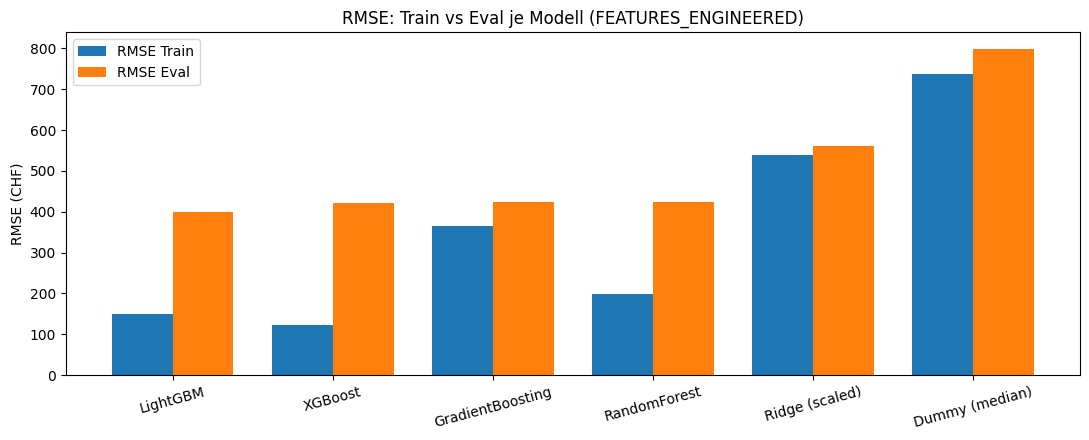

In [21]:
# Wir nehmen FEATURES_ENGINEERED als Hauptlauf, aber die Funktion ist generisch.
main_results = results_eng
main_fitted  = fitted_eng
main_cache   = cache_eng
main_features = FEATURES_ENGINEERED

models_sorted = main_results['Model'].tolist()
x_pos = np.arange(len(models_sorted))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x_pos - width/2, main_results['RMSE Train'], width, label='RMSE Train')
ax.bar(x_pos + width/2, main_results['RMSE Eval'],  width, label='RMSE Eval')
ax.set_xticks(x_pos)
ax.set_xticklabels(models_sorted, rotation=15)
ax.set_ylabel('RMSE (CHF)')
ax.set_title('RMSE: Train vs Eval je Modell (FEATURES_ENGINEERED)')
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
save_fig("rmse_train_eval.png", fig)

Saved figure: ../../docs/final-report/fig/rmse_train_eval.png


## 12. Overfitting-Diagnose

In [23]:
def diagnose_overfitting(row):
    train_rmse = row['RMSE Train']
    eval_rmse  = row['RMSE Eval']
    r2_eval    = row['R² Eval']

    gap_ratio = eval_rmse / train_rmse if train_rmse > 0 else np.inf

    if gap_ratio > 1.5 and r2_eval > 0:
        return 'Possible overfitting'
    if r2_eval < 0.3:
        return 'Weak generalization / possible underfitting'
    if gap_ratio <= 1.25 and r2_eval >= 0.6:
        return 'Good generalization'
    return 'Check manually'


diag = main_results[['Model', 'RMSE Train', 'RMSE Eval', 'R² Eval', 'Overfitting Gap']].copy()
diag['Diagnose'] = main_results.apply(diagnose_overfitting, axis=1)
diag

,Model,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,Diagnose
0,LightGBM,150.286423,399.166141,0.743658,248.879718,Possible overfitting
1,XGBoost,121.598850,420.806889,0.715109,299.208039,Possible overfitting
2,GradientBoosting,364.777231,424.709516,0.709801,59.932284,Good generalization
3,RandomForest,198.916167,424.910709,0.709526,225.994542,Possible overfitting
4,Ridge (scaled),538.819616,560.072923,0.495337,21.253306,Check manually
5,Dummy (median),737.368884,799.089038,-0.027313,61.720154,Weak generalization / possible underfitting


## 13. Cross-Validation

5-fold KFold mit Shuffle (`random_state=42`). Mietwohnungen sind keine Zeitreihe, deshalb hier kein `TimeSeriesSplit`. Wir verwenden **die Pipeline**, damit Skalierung pro Falte sauber neu gefittet wird.

In [24]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_scores(train_df, feature_cols, target_col, models, cv):
    X = train_df[feature_cols]
    y = train_df[target_col]

    records = []
    for name, model in models.items():
        cv_r2  = cross_val_score(model, X, y, cv=cv, scoring='r2')
        cv_mse = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
        records.append({
            'Model':       name,
            'CV R² mean':  cv_r2.mean(),
            'CV R² std':   cv_r2.std(),
            'CV RMSE mean': np.sqrt(cv_mse).mean(),
        })
    return pd.DataFrame(records).sort_values('CV R² mean', ascending=False).reset_index(drop=True)


cv_results = cv_scores(train_df, main_features, TARGET_COL, make_models(), cv)
cv_results

,Model,CV R² mean,CV R² std,CV RMSE mean
0,LightGBM,0.673731,0.009397,413.357575
1,XGBoost,0.665411,0.014220,418.608616
2,RandomForest,0.644675,0.020143,431.284596
3,GradientBoosting,0.635606,0.019850,436.590827
4,Ridge (scaled),0.439460,0.016385,541.744142
5,Dummy (median),-0.037457,0.010889,737.255590


## 14. Visualisierungen: Actual vs Predicted (bestes Modell)

Bestes Modell (nach RMSE Eval): LightGBM


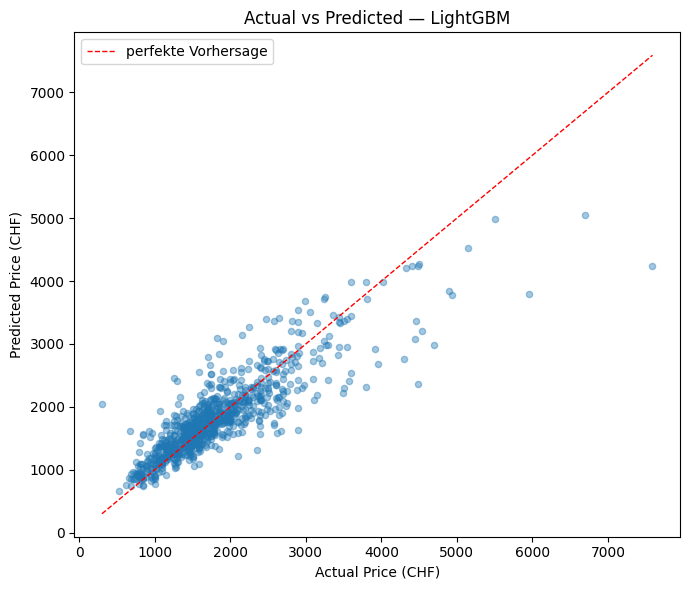

In [25]:
best_name  = main_results.iloc[0]['Model']
best_model = main_fitted[best_name]
y_eval     = eval_df[TARGET_COL]
y_pred     = main_cache[best_name]['eval']

print(f'Bestes Modell (nach RMSE Eval): {best_name}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_eval, y_pred, alpha=0.4, s=20)
lo = float(min(y_eval.min(), y_pred.min()))
hi = float(max(y_eval.max(), y_pred.max()))
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1, label='perfekte Vorhersage')
ax.set_xlabel('Actual Price (CHF)')
ax.set_ylabel('Predicted Price (CHF)')
ax.set_title(f'Actual vs Predicted — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
save_fig("actual_vs_predicted.png", fig)

Saved figure: ../../docs/final-report/fig/actual_vs_predicted.png


## 14b. Prediction Curves: Vergleich der Vorhersagekurven

Wir vergleichen mehrere Modelle direkt entlang **eines** Features. Da unser Modell mehrere Features nutzt, lässt sich keine echte 2D-Kurve plotten — stattdessen erzeugen wir eine **Partial-Prediction-Kurve**: ein Feature variiert über sein Wertebereich, alle anderen werden auf ihrem Median festgehalten.

In [27]:
def plot_prediction_curves(models, X_train, y_train, X_eval, y_eval, plot_feature):
    """Plottet Train/Eval-Punkte plus Partial-Prediction-Kurven mehrerer Modelle.

    - Train-Daten als blaue Punkte
    - Eval-Daten als orange X-Marker
    - Pro Modell eine Kurve über den Wertebereich von `plot_feature`,
      alle anderen Features werden auf ihrem Median festgehalten.
    """
    feature_grid = np.linspace(
        X_train[plot_feature].min(),
        X_train[plot_feature].max(),
        300,
    )

    median_values = X_train.median(numeric_only=True)
    X_curve = pd.DataFrame(
        np.tile(median_values.values, (len(feature_grid), 1)),
        columns=median_values.index,
    )
    # Spaltenreihenfolge muss exakt der Trainingsreihenfolge entsprechen
    X_curve = X_curve[X_train.columns]
    X_curve[plot_feature] = feature_grid

    plt.figure(figsize=(10, 6))

    plt.scatter(
        X_train[plot_feature], y_train,
        label='Train-Daten', alpha=0.5, s=20, color='tab:blue',
    )
    plt.scatter(
        X_eval[plot_feature], y_eval,
        label='Test-Daten', alpha=0.9, s=30, color='tab:orange', marker='x',
    )

    for model_name, model in models.items():
        y_curve = model.predict(X_curve)
        plt.plot(feature_grid, y_curve, label=model_name, linewidth=2)

    plt.title('Price Prediction: Vergleich der Vorhersagekurven')
    plt.xlabel(f'Feature: {plot_feature}')
    plt.ylabel('Preis (CHF)')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Plot-Feature: area
Modelle in der Kurve: ['Ridge (scaled)', 'LightGBM', 'RandomForest']


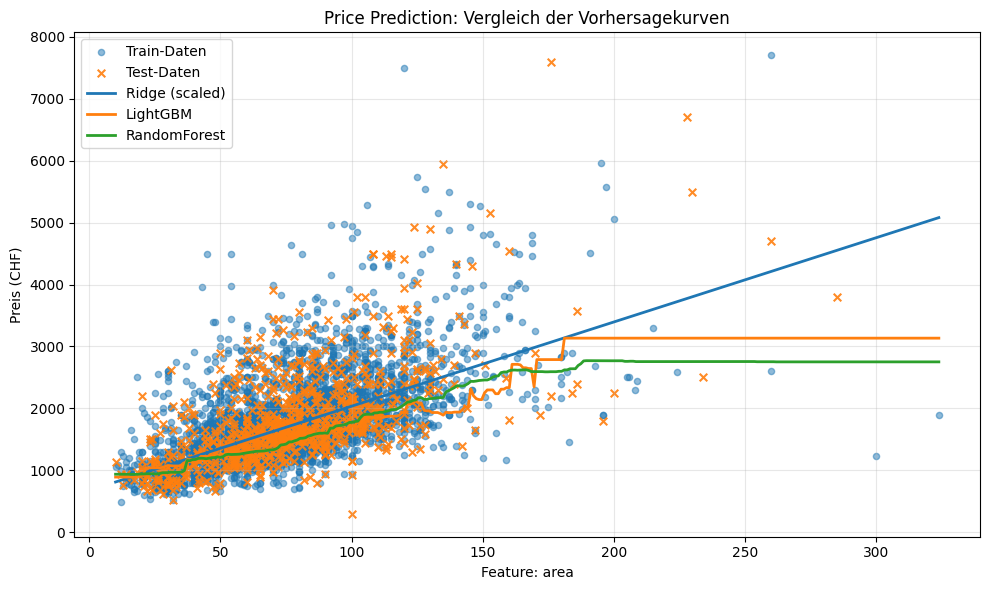

In [28]:
# Feature-Auswahl: 'area' bevorzugt, sonst das wichtigste numerische Feature
if 'area' in main_features:
    plot_feature = 'area'
else:
    plot_feature = main_features[0]
print(f'Plot-Feature: {plot_feature}')

# Wir wählen ein einfaches, ein "gutes" und ein komplexes Modell aus
# der bestehenden, bereits trainierten Sammlung.
_curve_candidates = ['Ridge (scaled)', 'GradientBoosting', 'RandomForest']
if HAS_LGBM and 'LightGBM' in main_fitted:
    _curve_candidates = ['Ridge (scaled)', 'LightGBM', 'RandomForest']

curve_models = {n: main_fitted[n] for n in _curve_candidates if n in main_fitted}
print('Modelle in der Kurve:', list(curve_models.keys()))

X_train_curve = train_df[main_features]
y_train_curve = train_df[TARGET_COL]
X_eval_curve  = eval_df[main_features]
y_eval_curve  = eval_df[TARGET_COL]

plot_prediction_curves(
    curve_models,
    X_train_curve, y_train_curve,
    X_eval_curve,  y_eval_curve,
    plot_feature,
)

**Wie liest man dieses Diagramm?**

Dieses Diagramm zeigt, wie sich die vorhergesagten Preise verändern, wenn sich ein ausgewähltes Feature verändert, während alle anderen Features konstant gehalten werden. Bei mehreren Features ist das **keine vollständige Darstellung des Modells**, sondern eine vereinfachte 2D-Sicht. Sie ist trotzdem nützlich, um Underfitting, Overfitting und unterschiedliche Modellverläufe sichtbar zu machen:

- Eine **flache, fast gerade** Kurve (z. B. Ridge) deutet auf ein lineares Modell hin, das nichtlineare Strukturen nicht abbilden kann → **Underfitting**.
- Eine **glatt geschwungene** Kurve, die der Punktwolke folgt → meist **gute Generalisierung**.
- Eine **stark zackige, übersensible** Kurve, die jeden einzelnen Punkt jagt → **Overfitting**.

## 14c. Demo: Underfitting / Good Fit / Overfitting mit Polynomial Regression

*Reines Lehrbeispiel auf synthetischen Daten — nicht Teil der finalen Modellbewertung.* Wir zeigen anhand einer einfachen 1D-Funktion, wie Modellkomplexität sich auf Bias und Varianz auswirkt:

- **Grad 1** (lineare Regression): zu einfach → Underfitting.
- **Grad 4**: passt sich der zugrunde liegenden Funktion sauber an → guter Trade-off.
- **Grad 15**: lernt das Rauschen mit, oszilliert wild zwischen den Trainingspunkten → Overfitting.

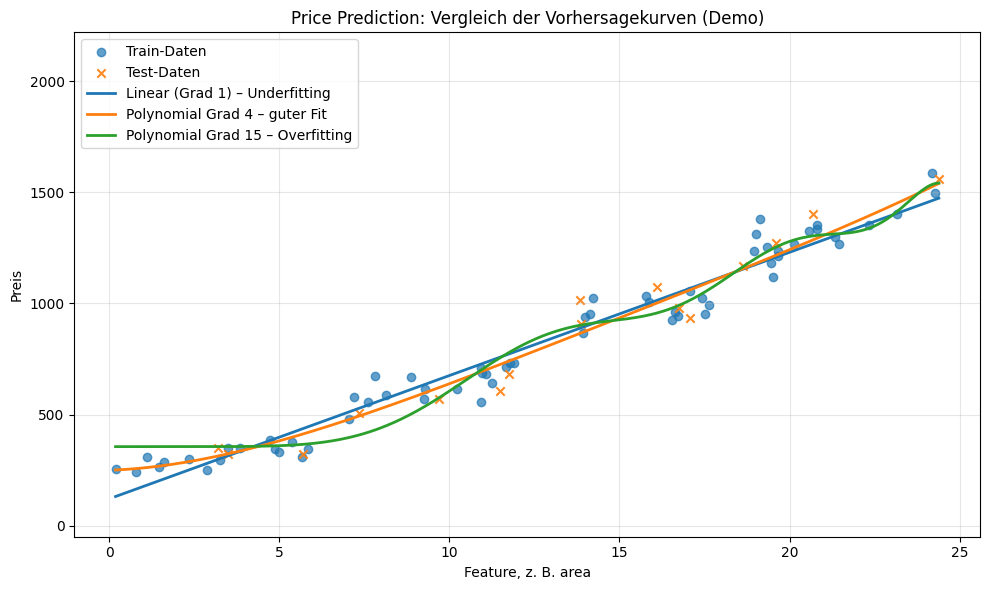

In [29]:
# === Didaktisches Demo: Polynomial Regression Grad 1 / 4 / 15 ===
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression as _LR
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(42)

# Synthetische Funktion: nicht-linear + Rauschen
def true_fn(x):
    return 200 + 30 * x + 50 * np.sin(x) + 5 * x ** 1.5

x_all = np.sort(rng.uniform(0, 25, size=80))
y_all = true_fn(x_all) + rng.normal(0, 60, size=x_all.size)

# 80/20 Split (synthetisch)
_split = int(0.8 * len(x_all))
_idx   = rng.permutation(len(x_all))
_tr, _ev = _idx[:_split], _idx[_split:]
x_tr, y_tr = x_all[_tr], y_all[_tr]
x_ev, y_ev = x_all[_ev], y_all[_ev]

x_grid = np.linspace(x_all.min(), x_all.max(), 400).reshape(-1, 1)

demo_models = {}
for label, deg in [('Linear (Grad 1) – Underfitting', 1),
                   ('Polynomial Grad 4 – guter Fit', 4),
                   ('Polynomial Grad 15 – Overfitting', 15)]:
    pipe = make_pipeline(PolynomialFeatures(deg, include_bias=False), _LR())
    pipe.fit(x_tr.reshape(-1, 1), y_tr)
    demo_models[label] = pipe

plt.figure(figsize=(10, 6))
plt.scatter(x_tr, y_tr, label='Train-Daten', alpha=0.7, color='tab:blue')
plt.scatter(x_ev, y_ev, label='Test-Daten', alpha=0.9, marker='x', color='tab:orange')

for label, pipe in demo_models.items():
    y_grid = pipe.predict(x_grid)
    plt.plot(x_grid, y_grid, label=label, linewidth=2)

plt.title('Price Prediction: Vergleich der Vorhersagekurven (Demo)')
plt.xlabel('Feature, z. B. area')
plt.ylabel('Preis')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
# y-Achse beschneiden, damit Grad-15-Schwingungen das Bild nicht sprengen
_lo = min(y_all.min(), -50)
_hi = max(y_all.max(), 50) * 1.4
plt.ylim(_lo, _hi)
plt.tight_layout()
plt.show()

## 15. Residual Analysis

Residuen = Actual − Predicted. Ideal: zufällig um 0 verteilt, glockenförmiges Histogramm, kein Trichter im Scatter.

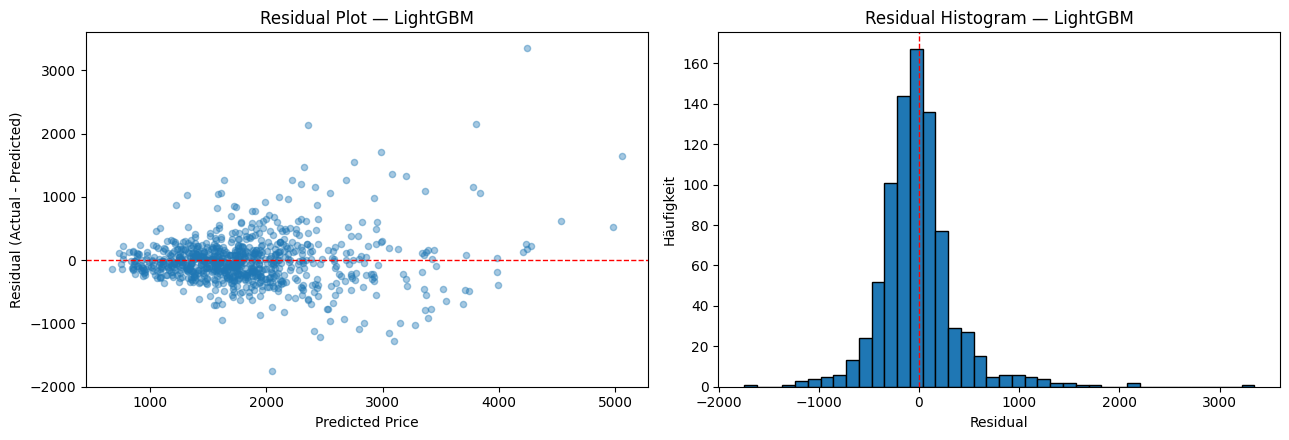

Residuen-Statistik:
count     840.000000
mean      -11.777749
std       399.230054
min     -1747.436976
25%      -216.738138
50%       -38.067641
75%       136.692419
max      3348.764303
Name: price, dtype: float64


In [30]:
residuals = y_eval - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Scatter: Predicted vs Residuals
axes[0].scatter(y_pred, residuals, alpha=0.4, s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'Residual Plot — {best_name}')

# Histogramm
axes[1].hist(residuals, bins=40, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title(f'Residual Histogram — {best_name}')

plt.tight_layout()
plt.show()

print('Residuen-Statistik:')
print(residuals.describe())

In [31]:
save_fig("residuals.png", fig)

Saved figure: ../../docs/final-report/fig/residuals.png


## 16. Fehleranalyse nach Preisgruppen

Wir teilen den **tatsächlichen** Preis in 4 Quartile und schauen, in welchen Preisbändern das Modell besonders große Fehler hat.

In [32]:
eval_results = pd.DataFrame({
    'actual':    y_eval.reset_index(drop=True),
    'predicted': pd.Series(y_pred).reset_index(drop=True),
})
eval_results['error']     = eval_results['actual'] - eval_results['predicted']
eval_results['abs_error'] = eval_results['error'].abs()

eval_results['price_band'] = pd.qcut(
    eval_results['actual'], q=4,
    labels=['cheap', 'medium_low', 'medium_high', 'expensive'],
    duplicates='drop',
)

(
    eval_results
    .groupby('price_band')['abs_error']
    .agg(['count', 'mean', 'median', 'max'])
    .round(1)
)

,count,mean,median,max
price_band,,,,
cheap,211,215.8,150.4,1747.4
medium_low,212,176.1,143.0,970.4
medium_high,207,221.0,158.1,1276.0
expensive,210,445.3,311.5,3348.8


## 17. Feature Importance

Für Tree-/Boosting-Modelle: Modell-eigene Importance.  
Für Pipelines (z. B. Ridge): wir zeigen `coef_` falls vorhanden, sonst Permutation Importance als universellen Fallback.

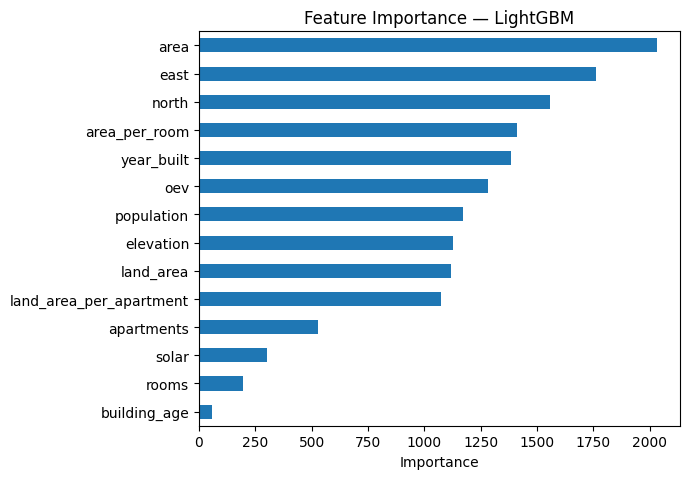

area                       2032
east                       1760
north                      1555
area_per_room              1409
year_built                 1384
oev                        1284
population                 1173
elevation                  1129
land_area                  1117
land_area_per_apartment    1074
apartments                  529
solar                       300
rooms                       194
building_age                 60
dtype: int32

In [33]:
def show_feature_importance(model, feature_cols, X_eval, y_eval, top_n=15):
    # 1) Tree-/Boosting-Modelle
    importances = getattr(model, 'feature_importances_', None)

    # 2) Pipeline → letzter Step
    if importances is None and isinstance(model, Pipeline):
        last = model.steps[-1][1]
        importances = getattr(last, 'feature_importances_', None)
        if importances is None and hasattr(last, 'coef_'):
            importances = np.abs(last.coef_)

    if importances is None:
        # 3) Permutation Importance als Fallback
        result = permutation_importance(
            model, X_eval, y_eval,
            n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
        )
        importances = result.importances_mean

    fi = (
        pd.Series(importances, index=feature_cols)
        .sort_values(ascending=True)
        .tail(top_n)
    )
    fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(fi))))
    fi.plot(kind='barh', ax=ax)
    ax.set_title(f'Feature Importance — {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    return fi.iloc[::-1]


fi = show_feature_importance(
    best_model, main_features,
    eval_df[main_features], eval_df[TARGET_COL],
)
fi

## 18. Bestes Modell auswählen

Wir vergleichen die drei Feature-Sets über RMSE Eval und wählen die beste Kombination aus Feature-Set + Modell.

In [34]:
compare_runs = (
    pd.concat([
        results_small.assign(FeatureSet='SMALL'),
        results_all.assign(FeatureSet='ALL'),
        results_eng.assign(FeatureSet='ENGINEERED'),
    ])
    .sort_values('RMSE Eval')
    .reset_index(drop=True)
)

best_run = compare_runs.iloc[0]
print(f'Best run: FeatureSet={best_run["FeatureSet"]}, Model={best_run["Model"]}, RMSE Eval={best_run["RMSE Eval"]:.1f}')
compare_runs.head(10)

Best run: FeatureSet=ENGINEERED, Model=LightGBM, RMSE Eval=399.2


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap,FeatureSet
0,LightGBM,104.406305,264.420015,77.063275,178.589822,150.286423,399.166141,0.956946,0.743658,248.879718,ENGINEERED
1,LightGBM,113.217236,266.221322,84.050759,176.065715,164.153581,403.349280,0.948634,0.738257,239.195699,ALL
2,XGBoost,96.942429,266.688721,70.322693,173.267395,139.462017,407.013936,0.962925,0.733479,267.551918,ALL
3,RandomForest,125.550257,274.519146,83.924959,194.051235,201.437937,419.549506,0.922651,0.716809,218.111570,ALL
4,XGBoost,84.069862,269.927094,60.300720,183.716797,121.598850,420.806889,0.971814,0.715109,299.208039,ENGINEERED
5,GradientBoosting,254.019719,281.771860,181.709982,203.294542,364.777231,424.709516,0.746353,0.709801,59.932284,ENGINEERED
6,RandomForest,124.279534,276.874338,82.630503,192.508914,198.916167,424.910709,0.924575,0.709526,225.994542,ENGINEERED
7,GradientBoosting,254.786037,280.844423,181.992040,195.013427,368.144394,426.672542,0.741649,0.707112,58.528148,ALL
8,LightGBM,209.236569,359.495542,156.366338,253.147336,290.429385,528.252577,0.839211,0.551052,237.823192,SMALL
9,RandomForest,177.678407,364.053183,121.675301,265.190446,271.512203,528.530951,0.859475,0.550579,257.018747,SMALL


In [35]:
# Mapping FeatureSet -> Spaltenliste / fitted-Dict
_feature_set_lookup = {
    'SMALL':      (FEATURES_SMALL,      fitted_small),
    'ALL':        (FEATURES_ALL,        fitted_all),
    'ENGINEERED': (FEATURES_ENGINEERED, fitted_eng),
}
best_feature_cols, best_fitted_pool = _feature_set_lookup[best_run['FeatureSet']]
best_model_final = best_fitted_pool[best_run['Model']]

print(f'Bestes Modell: {best_run["Model"]}  |  Features: {best_run["FeatureSet"]}  ({len(best_feature_cols)} Spalten)')
print('Verwendete Features (in dieser Reihenfolge):')
print(best_feature_cols)

Bestes Modell: LightGBM  |  Features: ENGINEERED  (14 Spalten)
Verwendete Features (in dieser Reihenfolge):
['east', 'north', 'elevation', 'area', 'rooms', 'year_built', 'apartments', 'land_area', 'population', 'oev', 'solar', 'building_age', 'area_per_room', 'land_area_per_apartment']


## 19. Finale Prediction

Hier zwei Varianten:

1. **Refit auf gesamtem `df_model`** (Train + Eval) — für den Produktionseinsatz, wenn die Eval-Phase abgeschlossen ist.
2. **Spaltencheck** stellt sicher, dass das finale Test-DataFrame exakt die im Training verwendeten Features hat.

Wenn dein finales Test-Set unter einem anderen Variablennamen vorliegt (z. B. aus `model_v2.ipynb`), passe `final_test_df` entsprechend an.

In [36]:
def check_columns(final_test_df, required_cols):
    missing = set(required_cols) - set(final_test_df.columns)
    extras  = set(final_test_df.columns) - set(required_cols)
    print('Missing columns        :', sorted(missing))
    print('Extra columns (ignored):', sorted(extras))
    if missing:
        raise ValueError(f'Final test data is missing required columns: {missing}')


def fit_and_predict_final(df_model, final_test_df, feature_cols, target_col, model_factory):
    """Refit auf vollständige Modell-Daten und Predict auf finalem Testset."""
    check_columns(final_test_df, feature_cols)

    # Frische Modell-Instanz, damit kein "halb-trainierter" Zustand wiederverwendet wird.
    final_model = model_factory()
    final_model.fit(df_model[feature_cols], df_model[target_col])
    return final_model, final_model.predict(final_test_df[feature_cols])

In [37]:
# Demo: wir tun so, als wäre eval_df unser "finaler Testdatensatz".
# In der echten Anwendung wäre das ein separates Dataset (z. B. aus dem Hold-out
# in model_v2.ipynb, oder neue Wohnungen aus der Produktion).
final_test_df = eval_df.copy()

# model_factory: liefert exakt das Modell, das in 18 als bestes ausgewählt wurde.
_best_factory_lookup = {
    name: (lambda n=name: make_models()[n]) for name in make_models().keys()
}
model_factory = _best_factory_lookup[best_run['Model']]

# WICHTIG: Refit auf die volle Modell-Datenbasis nutzt train_df + eval_df,
# d. h. das, was in df_for_split steckt — nicht df (das enthält noch die
# Analyse-Spalte price_per_sqm).
df_full_for_refit = df_for_split

final_model_v3, final_predictions = fit_and_predict_final(
    df_full_for_refit, final_test_df,
    best_feature_cols, TARGET_COL, model_factory,
)

final_predictions[:10]

Missing columns        : []
Extra columns (ignored): ['price']


array([2342.36560333, 1118.41864669, 3033.82299894, 1386.33874102,
       2200.32411781, 1239.07440517, 3298.34603358, 1568.35651346,
       2219.37500645, 1416.77530514])

In [38]:
# Optional: Als DataFrame für Export
out_df = pd.DataFrame({
    'predicted_price': final_predictions,
})
if TARGET_COL in final_test_df.columns:
    out_df['actual_price'] = final_test_df[TARGET_COL].reset_index(drop=True)
    out_df['abs_error']    = (out_df['actual_price'] - out_df['predicted_price']).abs()
out_df.head()

,predicted_price,actual_price,abs_error
0,2342.365603,2400,57.634397
1,1118.418647,920,198.418647
2,3033.822999,3800,766.177001
3,1386.338741,1060,326.338741
4,2200.324118,2038,162.324118


## 20. Optional: Group Split nach Koordinaten

Ein normaler `train_test_split` kann Wohnungen aus *demselben Gebäude* oder direkt aus der Nachbarschaft sowohl in Train als auch in Eval landen lassen. Das macht das Eval optimistisch, weil das Modell quasi-bekannte Lagen sieht.

Mit einem **Group Split** prüfen wir die härtere Frage: *Wie gut generalisiert das Modell auf neue Orte, die es noch nie gesehen hat?* Dafür gruppieren wir auf gerundeten Koordinaten und stellen sicher, dass jede Gruppe entweder komplett in Train **oder** komplett in Eval landet.

In [39]:
if {'east', 'north'} <= set(df_for_split.columns):
    df_grp = df_for_split.copy()
    df_grp['location_group'] = (
        df_grp['east'].round(0).astype(int).astype(str) + '_' +
        df_grp['north'].round(0).astype(int).astype(str)
    )

    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    (train_idx, eval_idx), = gss.split(df_grp, groups=df_grp['location_group'])
    train_grp = df_grp.iloc[train_idx]
    eval_grp  = df_grp.iloc[eval_idx]

    print(f'Group-Split: Train={len(train_grp)}, Eval={len(eval_grp)}')
    print(f'Disjunkt? Schnittmenge der Gruppen: '
          f'{len(set(train_grp["location_group"]) & set(eval_grp["location_group"]))}')

    results_grp, _, _ = evaluate_models(
        train_grp, eval_grp, main_features, TARGET_COL, make_models(),
    )
    print('\nGroup-Split Resultate (sortiert nach RMSE Eval):')
    display(results_grp)
else:
    print('Spalten east/north fehlen — Group Split übersprungen.')

Group-Split: Train=3363, Eval=835
Disjunkt? Schnittmenge der Gruppen: 0

Group-Split Resultate (sortiert nach RMSE Eval):


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,XGBoost,91.122841,247.306580,64.277466,191.531616,134.224101,336.531469,0.968206,0.749852,202.307368
1,LightGBM,108.611055,254.671226,80.946773,203.907726,157.042651,345.824018,0.956477,0.735847,188.781367
2,RandomForest,129.576815,257.577424,84.016897,197.459396,209.434520,347.159730,0.922593,0.733802,137.725209
3,GradientBoosting,258.484549,261.510015,179.805545,207.735392,374.408205,355.870839,0.752613,0.720276,-18.537366
4,Ridge (scaled),390.680973,347.485519,282.741158,271.523764,560.311671,467.762634,0.445955,0.516723,-92.549038
5,Dummy (median),525.858460,506.056287,380.000000,390.000000,767.312723,686.943245,-0.039037,-0.042286,-80.369478


## 21. Geo-Analyse und Geo-Clustering

Geo-Daten können die Mietpreisvorhersage stark verbessern, weil **Lage** oft einer der wichtigsten Preisfaktoren ist. Reine Koordinaten kann das Modell direkt nutzen; **Geo-Cluster** als zusätzliches Feature helfen, regionale Preiszonen explizit zu kodieren – besonders bei Tree-/Boosting-Modellen.

**Wichtig (kein Leakage):** Der Clusterer wird ausschließlich auf `train_df` gefittet und dann auf `eval_df` *predicted*. Würden wir `fit_predict` auf der vollen Datenmenge laufen lassen, würden Eval-Beobachtungen in die Cluster-Definition einfließen und die Eval-Metriken künstlich aufblasen.

Falls `east`/`north` fehlen, wird die ganze Sektion automatisch übersprungen, ohne dass das Notebook crasht.

### 21.1 Geo-Spalten prüfen

In [40]:
GEO_COLS      = ['east', 'north']
ELEVATION_COL = 'elevation'

geo_cols_available = [c for c in GEO_COLS if c in df_for_split.columns]
has_full_geo       = len(geo_cols_available) == len(GEO_COLS)
has_elevation      = ELEVATION_COL in df_for_split.columns

print(f'Geo-Spalten verfügbar: {geo_cols_available}')
print(f'Elevation verfügbar : {has_elevation}')
print(f'Vollständige Geo-Daten: {has_full_geo}')

Geo-Spalten verfügbar: ['east', 'north']
Elevation verfügbar : True
Vollständige Geo-Daten: True


### 21.2 Geo-EDA

In [41]:
if has_full_geo:
    desc_cols = list(geo_cols_available)
    if has_elevation:
        desc_cols += [ELEVATION_COL]
    desc_cols += [TARGET_COL]
    print('Beschreibung der Geo- und Preis-Spalten:')
    display(df_for_split[desc_cols].describe().T)
else:
    print('Geo-EDA übersprungen — east/north fehlen.')

Beschreibung der Geo- und Preis-Spalten:


,count,mean,std,min,25%,50%,75%,max
east,4198.0,2.642086e+06,68867.424033,2494493.75,2.601377e+06,2648703.75,2.691348e+06,2818550.0
north,4198.0,1.219829e+06,51645.740197,1076962.00,1.181577e+06,1245427.75,1.258914e+06,1286728.5
elevation,4198.0,4.611092e+02,159.029291,197.70,3.902750e+02,434.85,5.131000e+02,1570.7
price,4198.0,1.826667e+03,737.658329,300.00,1.350000e+03,1685.00,2.145750e+03,7700.0


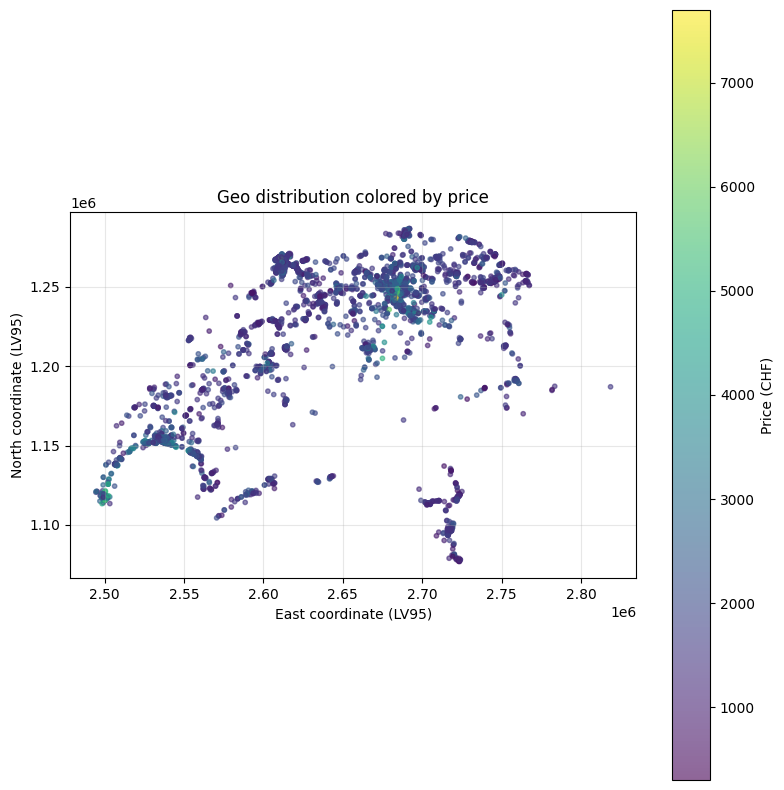

In [42]:
if has_full_geo:
    fig, ax = plt.subplots(figsize=(8, 8))  # quadratisch

    sc = ax.scatter(
        df_for_split['east'],
        df_for_split['north'],
        c=df_for_split[TARGET_COL],
        cmap='viridis',
        alpha=0.6,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Price (CHF)')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title('Geo distribution colored by price')

    ax.grid(True, alpha=0.3)

    # WICHTIG: echte quadratische Darstellung
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()


In [43]:
save_fig("geo_price_map.png", fig)

Saved figure: ../../docs/final-report/fig/geo_price_map.png


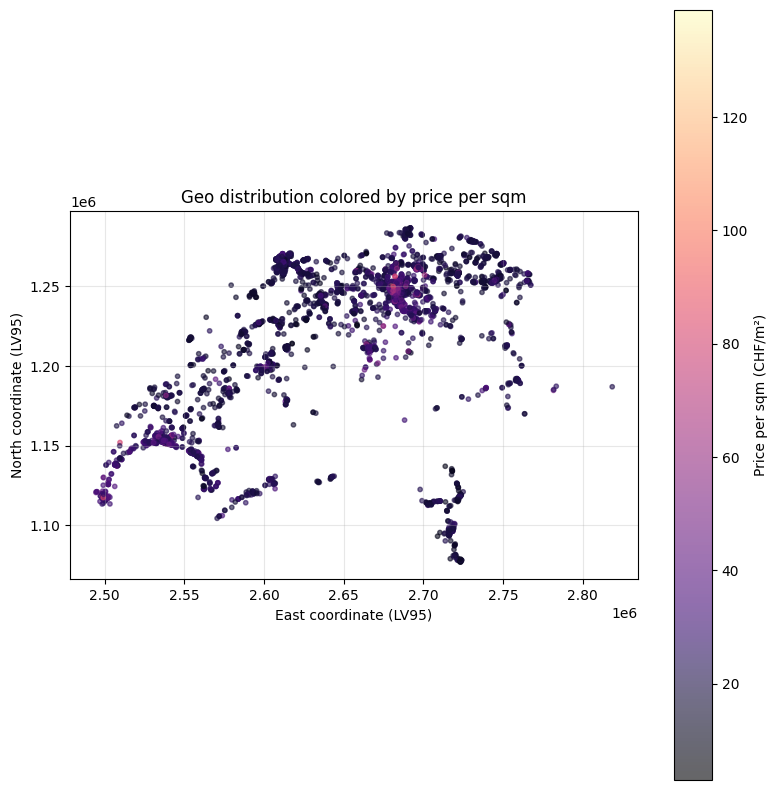

In [44]:
if has_full_geo and 'price_per_sqm' in df_clean.columns:
    fig, ax = plt.subplots(figsize=(8, 8))  # quadratisch

    sc = ax.scatter(
        df_clean['east'],
        df_clean['north'],
        c=df_clean['price_per_sqm'],
        cmap='magma',
        alpha=0.6,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Price per sqm (CHF/m²)')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title('Geo distribution colored by price per sqm')

    ax.grid(True, alpha=0.3)

    # WICHTIG: echte quadratische Darstellung
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()
else:
    print('Skipped: price_per_sqm nicht verfügbar oder Geo-Spalten fehlen.')


### 21.3 KMeans Clustering — verschiedene Clusterzahlen testen

Der Clusterer läuft in einer Pipeline mit `StandardScaler`, weil `east`/`north` (und ggf. `elevation`) sehr unterschiedliche Größenordnungen haben. **Gefittet wird nur auf `train_df`** – `predict` wird dann zusätzlich auf `eval_df` aufgerufen, ohne dass dessen Beobachtungen die Clusterzentren beeinflussen.

Für jeden Wert von `k` evaluieren wir kurz mit einem schnellen RandomForest, ob `geo_cluster` als Feature den RMSE auf Eval verbessert. Anschließend wählen wir das beste `k`.

In [45]:
from sklearn.cluster import KMeans

GEO_CLUSTER_COLS_2D = ['east', 'north']

if has_full_geo:
    cluster_counts = [4, 6, 8, 10, 12, 15]

    fast_models = {
        'RandomForest_fast': RandomForestRegressor(
            n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2,
        ),
    }

    cluster_search = []
    cluster_pipes  = {}

    for k in cluster_counts:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('kmeans', KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)),
        ])
        pipe.fit(train_df[GEO_CLUSTER_COLS_2D])
        cluster_pipes[k] = pipe

        tr = train_df.assign(geo_cluster=pipe.predict(train_df[GEO_CLUSTER_COLS_2D]))
        ev = eval_df.assign(geo_cluster=pipe.predict(eval_df[GEO_CLUSTER_COLS_2D]))

        res, _, _ = evaluate_models(
            tr, ev, FEATURES_ALL + ['geo_cluster'], TARGET_COL, fast_models,
        )
        cluster_search.append({
            'k':         k,
            'RMSE Eval': res.iloc[0]['RMSE Eval'],
            'R² Eval':   res.iloc[0]['R² Eval'],
        })

    cluster_k_df = (
        pd.DataFrame(cluster_search)
          .sort_values('RMSE Eval')
          .reset_index(drop=True)
    )
    print('Cluster-Anzahl-Vergleich (RandomForest, FEATURES_ALL + geo_cluster):')
    display(cluster_k_df)

    best_k = int(cluster_k_df.iloc[0]['k'])
    print(f'\n→ Bestes k (auf Eval): {best_k}')
else:
    best_k = None
    print('Clustering übersprungen — Geo-Spalten fehlen.')

Cluster-Anzahl-Vergleich (RandomForest, FEATURES_ALL + geo_cluster):


,k,RMSE Eval,R² Eval
0,8,413.287666,0.725200
1,6,414.882764,0.723074
2,15,415.582661,0.722139
3,12,416.639230,0.720725
4,4,417.715879,0.719279
5,10,418.653774,0.718017



→ Bestes k (auf Eval): 8


### 21.4 Geo-Cluster visualisieren & Preisstatistik pro Cluster

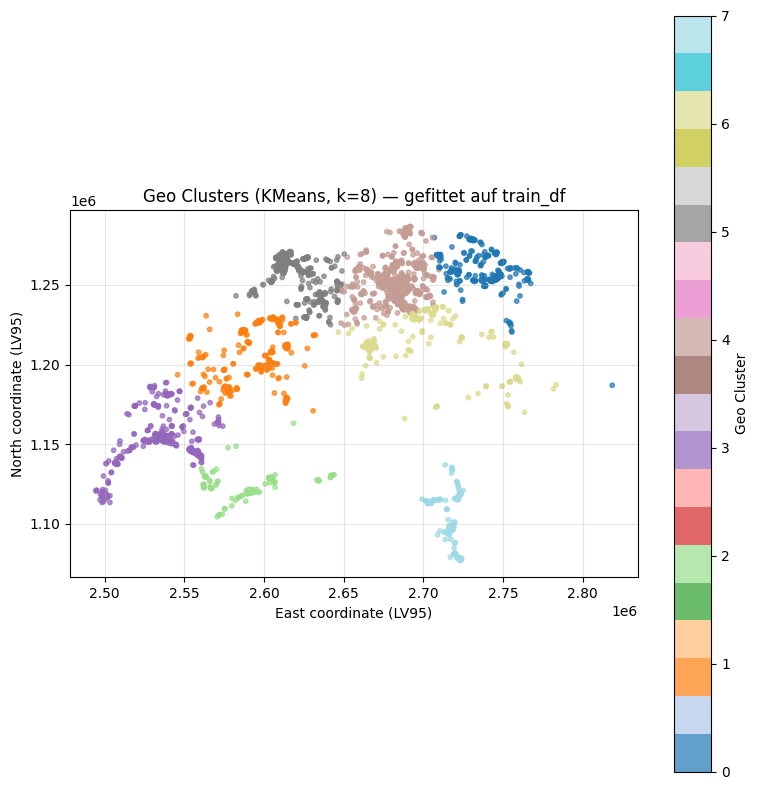

Preisstatistik pro Geo-Cluster (Train):


,count,mean,median,std
geo_cluster,,,,
4,894,2159.0,2029.0,786.0
3,565,2028.0,1800.0,876.0
6,237,1924.0,1830.0,680.0
5,716,1627.0,1572.0,528.0
2,102,1602.0,1500.0,597.0
1,293,1583.0,1530.0,460.0
0,384,1511.0,1450.0,492.0
7,167,1408.0,1330.0,466.0


In [46]:
if has_full_geo and best_k is not None:
    geo_pipe_2d = cluster_pipes[best_k]

    train_df_geo = train_df.copy()
    eval_df_geo  = eval_df.copy()

    train_df_geo['geo_cluster'] = geo_pipe_2d.predict(train_df[GEO_CLUSTER_COLS_2D])
    eval_df_geo['geo_cluster']  = geo_pipe_2d.predict(eval_df[GEO_CLUSTER_COLS_2D])

    fig, ax = plt.subplots(figsize=(8, 8))  # quadratisch

    sc = ax.scatter(
        train_df_geo['east'],
        train_df_geo['north'],
        c=train_df_geo['geo_cluster'],
        cmap='tab20',
        alpha=0.7,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Geo Cluster')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title(f'Geo Clusters (KMeans, k={best_k}) — gefittet auf train_df')

    ax.grid(True, alpha=0.3)

    # WICHTIG: echte metrische Darstellung
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

    cluster_stats = (
        train_df_geo.groupby('geo_cluster')[TARGET_COL]
        .agg(['count', 'mean', 'median', 'std'])
        .round(0)
        .sort_values('mean', ascending=False)
    )

    print('Preisstatistik pro Geo-Cluster (Train):')
    display(cluster_stats)


### 21.5 Modellvergleich: ohne vs. mit Geo-Cluster

Wir vergleichen **fünf Feature-Sets** quer über alle Modelle:

1. `FEATURES_SMALL`
2. `FEATURES_ALL`
3. `FEATURES_ALL + ['geo_cluster']`
4. `FEATURES_ENGINEERED`
5. `FEATURES_ENGINEERED + ['geo_cluster']`

Die Tabelle ist nach `RMSE Eval` aufsteigend sortiert. Wenn die `+geo`-Varianten klar oben stehen, hilft das Cluster-Feature.

In [47]:
if has_full_geo and best_k is not None:
    feature_sets_geo = {
        'SMALL':          FEATURES_SMALL,
        'ALL':            FEATURES_ALL,
        'ALL+geo':        FEATURES_ALL + ['geo_cluster'],
        'ENGINEERED':     FEATURES_ENGINEERED,
        'ENGINEERED+geo': FEATURES_ENGINEERED + ['geo_cluster'],
    }

    geo_runs = []
    for set_name, feats in feature_sets_geo.items():
        # Validierung: alle Spalten in train_df_geo / eval_df_geo vorhanden?
        missing = [c for c in feats if c not in train_df_geo.columns]
        if missing:
            print(f'Skipped {set_name}: missing {missing}')
            continue

        results, _, _ = evaluate_models(
            train_df_geo, eval_df_geo, feats, TARGET_COL, make_models(),
        )
        results = results.assign(
            FeatureSet=set_name,
            n_geo_clusters=best_k if 'geo' in set_name else 0,
            geo_cluster_cols=', '.join(GEO_CLUSTER_COLS_2D) if 'geo' in set_name else '',
        )
        geo_runs.append(results)

    geo_results_df = (
        pd.concat(geo_runs)
        .sort_values('RMSE Eval')
        .reset_index(drop=True)
    )
    geo_results_df['Diagnose'] = geo_results_df.apply(diagnose_overfitting, axis=1)

    cols_to_show = [
        'FeatureSet', 'Model',
        'MAE Train', 'MAE Eval',
        'RMSE Train', 'RMSE Eval',
        'R² Train', 'R² Eval',
        'Overfitting Gap', 'Diagnose',
        'n_geo_clusters', 'geo_cluster_cols',
    ]
    display(geo_results_df[cols_to_show].head(15))
else:
    print('Modellvergleich übersprungen — Geo-Spalten fehlen.')

,FeatureSet,Model,MAE Train,MAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap,Diagnose,n_geo_clusters,geo_cluster_cols
0,ENGINEERED+geo,LightGBM,104.106127,265.017656,148.632283,395.356652,0.957889,0.748527,246.724369,Possible overfitting,8,"east, north"
1,ALL+geo,LightGBM,112.919106,264.721002,162.831986,397.848403,0.949458,0.745348,235.016417,Possible overfitting,8,"east, north"
2,ENGINEERED,LightGBM,104.406305,264.420015,150.286423,399.166141,0.956946,0.743658,248.879718,Possible overfitting,0,
3,ALL,LightGBM,113.217236,266.221322,164.153581,403.349280,0.948634,0.738257,239.195699,Possible overfitting,0,
4,ALL,XGBoost,96.942429,266.688721,139.462017,407.013936,0.962925,0.733479,267.551918,Possible overfitting,0,
5,ALL+geo,RandomForest,124.714897,273.709801,199.692919,414.693447,0.923985,0.723327,215.000529,Possible overfitting,8,"east, north"
6,ALL+geo,XGBoost,97.636948,269.622589,140.518675,417.280668,0.962361,0.719864,276.761993,Possible overfitting,8,"east, north"
7,ENGINEERED+geo,XGBoost,85.915131,267.561340,123.294351,418.444105,0.971022,0.718300,295.149753,Possible overfitting,8,"east, north"
8,ENGINEERED+geo,RandomForest,123.804368,275.576335,197.556061,419.068587,0.925603,0.717458,221.512526,Possible overfitting,8,"east, north"
9,ALL,RandomForest,125.550257,274.519146,201.437937,419.549506,0.922651,0.716809,218.111570,Possible overfitting,0,


### 21.6 Optional: Höhe (`elevation`) ins Clustering aufnehmen

Wenn `elevation` verfügbar ist, lohnt sich der Test, ob 3D-Clustering (`east`, `north`, `elevation`) bessere Cluster liefert als 2D. Das zwingende Argument für die Pipeline mit `StandardScaler`: Ohne Skalierung dominieren die Koordinaten (Größenordnung 10⁶) die Höhe (Größenordnung 10²) komplett.

In [48]:
if has_full_geo and has_elevation and best_k is not None:
    GEO_CLUSTER_COLS_3D = ['east', 'north', 'elevation']

    pipe_3d = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)),
    ])
    pipe_3d.fit(train_df[GEO_CLUSTER_COLS_3D])

    train_df_geo3d = train_df.assign(geo_cluster=pipe_3d.predict(train_df[GEO_CLUSTER_COLS_3D]))
    eval_df_geo3d  = eval_df.assign(geo_cluster=pipe_3d.predict(eval_df[GEO_CLUSTER_COLS_3D]))

    res_3d, _, _ = evaluate_models(
        train_df_geo3d, eval_df_geo3d,
        FEATURES_ALL + ['geo_cluster'], TARGET_COL, make_models(),
    )
    res_3d = res_3d.assign(
        FeatureSet='ALL+geo',
        geo_cluster_cols=', '.join(GEO_CLUSTER_COLS_3D),
        n_geo_clusters=best_k,
    )
    print('Mit east/north/elevation als Cluster-Eingabe:')
    display(res_3d[['FeatureSet', 'Model', 'RMSE Eval', 'R² Eval', 'geo_cluster_cols']].head())
else:
    print('3D-Clustering übersprungen (elevation oder Geo-Spalten fehlen).')

Mit east/north/elevation als Cluster-Eingabe:


,FeatureSet,Model,RMSE Eval,R² Eval,geo_cluster_cols
0,ALL+geo,LightGBM,402.110035,0.739863,"east, north, elevation"
1,ALL+geo,XGBoost,410.722268,0.728601,"east, north, elevation"
2,ALL+geo,RandomForest,419.093469,0.717425,"east, north, elevation"
3,ALL+geo,GradientBoosting,429.439474,0.703301,"east, north, elevation"
4,ALL+geo,Ridge (scaled),557.958415,0.499140,"east, north, elevation"


### 21.7 Lineare Modelle: `geo_cluster` per OneHotEncoder

`geo_cluster` ist eigentlich eine **Kategorie**, auch wenn sie als Integer gespeichert ist. Für Tree-/Boosting-Modelle ist das egal – sie können numerische Splits machen. Ein lineares Modell wie Ridge interpretiert `geo_cluster=8` jedoch fälschlicherweise als "viermal so groß wie 2". Lösung: `ColumnTransformer` mit `OneHotEncoder` für die Cluster-Spalte und `StandardScaler` für die numerischen Features.

In [49]:
if has_full_geo and best_k is not None:
    from sklearn.compose      import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder

    feats_with_cluster = FEATURES_ALL + ['geo_cluster']
    numeric_features   = FEATURES_ALL
    cat_features       = ['geo_cluster']

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(),                     numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ])

    ridge_geo_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model',        Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ])

    res_ridge, _, _ = evaluate_models(
        train_df_geo, eval_df_geo, feats_with_cluster, TARGET_COL,
        {'Ridge (OneHot geo_cluster)': ridge_geo_pipe},
    )
    print('Ridge mit OneHotEncoded geo_cluster:')
    display(res_ridge)

Ridge mit OneHotEncoded geo_cluster:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,Ridge (OneHot geo_cluster),332.001652,337.432747,239.358759,235.275261,480.1135,491.783188,0.560598,0.610901,11.669687


### 21.8 Optional: DBSCAN — nur als Analysetool

DBSCAN findet **dichte Regionen** (Städte, Quartiere) und markiert isolierte Punkte als Noise (Cluster `-1`). Wir verwenden DBSCAN **nicht** als Modellfeature, weil es keine `predict()`-Methode hat: Für neue Eval-/Test-Punkte gibt es keinen sauberen Weg, dieselben Cluster zu vergeben. Hier nur zur Diagnostik.

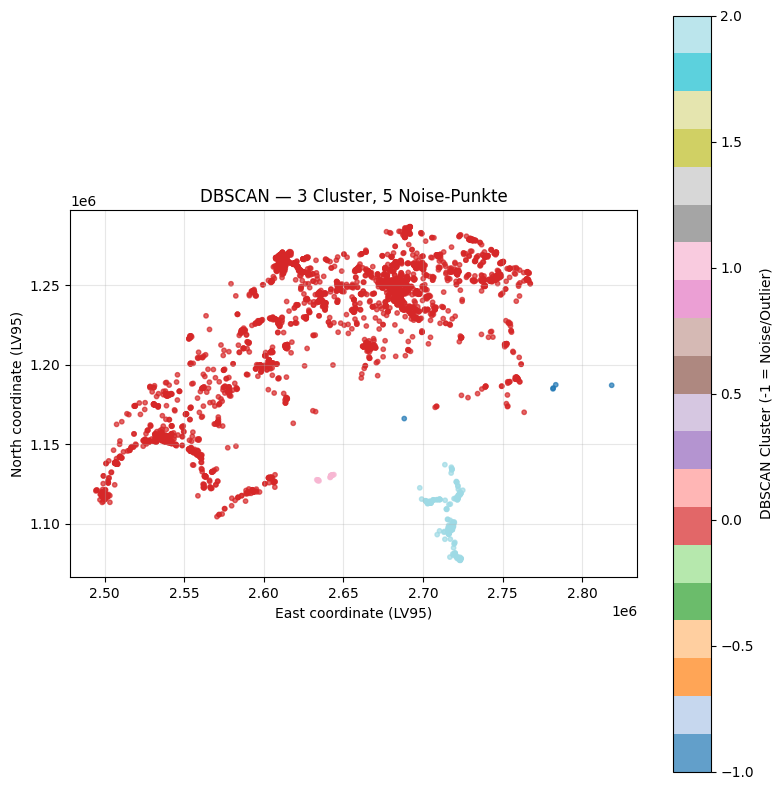

Cluster (ohne Noise): 3
Outlier (Cluster -1): 5


In [50]:
if has_full_geo:
    from sklearn.cluster import DBSCAN
    from sklearn.preprocessing import StandardScaler

    coords        = df_for_split[['east', 'north']]
    coords_scaled = StandardScaler().fit_transform(coords)

    dbscan        = DBSCAN(eps=0.3, min_samples=10)
    dbscan_labels = dbscan.fit_predict(coords_scaled)

    n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_outliers        = (dbscan_labels == -1).sum()

    fig, ax = plt.subplots(figsize=(8, 8))  # quadratisch

    sc = ax.scatter(
        coords['east'], coords['north'],
        c=dbscan_labels,
        cmap='tab20',
        alpha=0.7,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('DBSCAN Cluster (-1 = Noise/Outlier)')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title(f'DBSCAN — {n_clusters_dbscan} Cluster, {n_outliers} Noise-Punkte')

    ax.grid(True, alpha=0.3)

    # WICHTIG: metrisch korrekt
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

    print(f'Cluster (ohne Noise): {n_clusters_dbscan}')
    print(f'Outlier (Cluster -1): {n_outliers}')


### 21.9 Geo-Prediction-Kurve entlang `east`

Wir variieren `east` über seinen Wertebereich, halten alle anderen Features auf dem Median und plotten die Vorhersagekurve des besten Modells. Das ist eine **vereinfachte 2D-Sicht**: Echte Geo-Effekte sind zweidimensional (`east` × `north`) und können sich gegenseitig kompensieren – die Kurve zeigt nur den Effekt entlang einer Achse, mit `north` festgehalten.

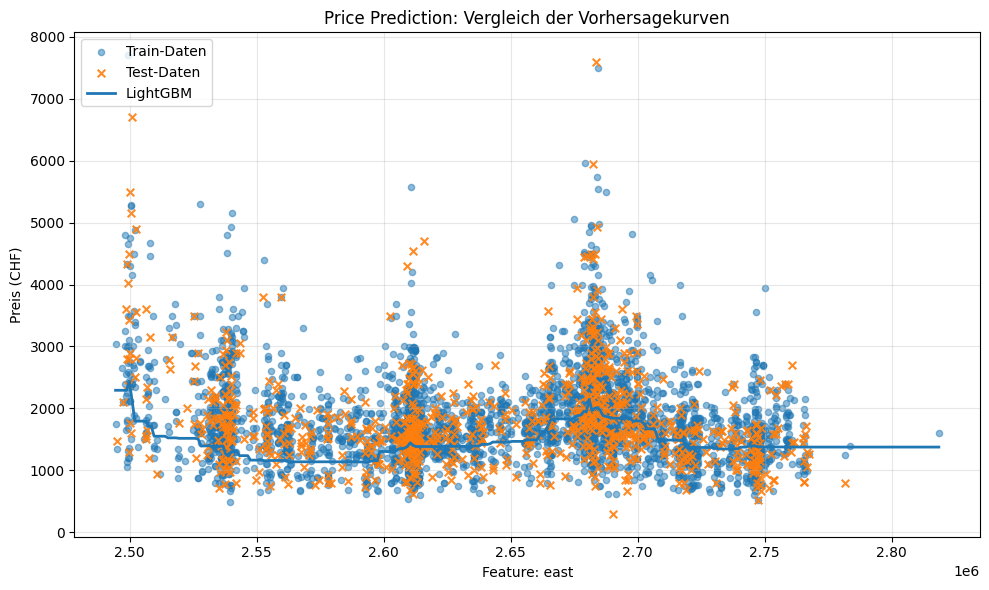

In [51]:
if has_full_geo and 'east' in main_features:
    geo_curve_model_name = best_name  # bereits in Kap. 14 gesetzt
    geo_curve_model      = main_fitted[geo_curve_model_name]

    plot_prediction_curves(
        {geo_curve_model_name: geo_curve_model},
        train_df[main_features], train_df[TARGET_COL],
        eval_df[main_features],  eval_df[TARGET_COL],
        plot_feature='east',
    )
else:
    print('Geo-Prediction-Kurve übersprungen — east nicht in main_features.')

### 21.10 Zusammenfassung Geo

Geo-Daten können die Mietpreisvorhersage stark verbessern, weil die Lage oft einer der wichtigsten Preisfaktoren ist. Reine Koordinaten können vom Modell direkt genutzt werden. Geo-Cluster können zusätzlich helfen, regionale Preiszonen zu bilden. Besonders bei Baum-Modellen kann ein Cluster-Feature nützlich sein. Man muss aber aufpassen, dass Cluster nicht auf Train und Eval gemeinsam gefittet werden, wenn sie als Modellfeature verwendet werden.

**Best-Practice-Checkliste aus diesem Kapitel:**

- KMeans ausschließlich auf `train_df` fitten, dann mit `predict` auf Eval anwenden.
- `StandardScaler` in der Cluster-Pipeline, weil `east`/`north`/`elevation` sehr unterschiedliche Größenordnungen haben.
- `geo_cluster` als Feature für Tree-Modelle direkt als Integer; für lineare Modelle via `OneHotEncoder` in einem `ColumnTransformer`.
- DBSCAN nur als Diagnose-Tool, nicht als Modellfeature (kein `predict` für neue Punkte).
- Für strengere Generalisierung: `GroupShuffleSplit` aus Kapitel 20 mit `location_group` aus gerundeten Koordinaten.

## 22. Erweiterte Verbesserungen

Dieses Kapitel ergänzt die Pipeline um produktionsreife Best Practices: bessere Behandlung fehlender Daten, log-transformierte Zielvariable, Hyperparameter-Tuning, stratifizierter Split, Diagnose-Kurven (Learning/Validation Curve), Vorhersage-Intervalle, Erklärbarkeit (SHAP), Outlier-Detection, Feature-Selection, Modell-Persistenz, robuste Inferenz, Drift-Check und Bias-Analyse.

Jede Subsection ist defensiv geschrieben — wenn eine optionale Library fehlt (z. B. `shap`), wird die Zelle übersprungen statt zu crashen.

### 22.1 Missing-Data-Diagnose & Imputation

Statt Zeilen mit `dropna` zu verwerfen, ergänzen wir eine Diagnose-Zelle (wie viele Zeilen kostet ein Drop pro Feature-Set?) und eine Pipeline mit `SimpleImputer`. Tree-/Boosting-Modelle wie XGBoost und LightGBM können `NaN` direkt verarbeiten — für die ist Imputation optional.

In [52]:
from sklearn.impute import SimpleImputer

# (a) Diagnose: dropna-Verlust pro Feature-Set
print('Missing-Data-Diagnose auf df_model:')
for name, feats in [
    ('SMALL',      FEATURES_SMALL),
    ('ALL',        FEATURES_ALL),
    ('ENGINEERED', FEATURES_ENGINEERED),
]:
    n_lost = df_model[feats + [TARGET_COL]].isna().any(axis=1).sum()
    pct    = n_lost / len(df_model) * 100
    print(f'  {name:12s}: {n_lost:5d} Zeilen ({pct:.2f}%) hätten NaN')

# (b) Imputation in der Pipeline (alternativ zu dropna)
ridge_imp_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler',  StandardScaler()),
    ('model',   Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

rf_imp_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2)),
])

imp_results, _, _ = evaluate_models(
    train_df, eval_df, FEATURES_ENGINEERED, TARGET_COL,
    {'Ridge_imputed': ridge_imp_pipe, 'RandomForest_imputed': rf_imp_pipe},
)
print('\nMit Imputation statt dropna:')
display(imp_results)

Missing-Data-Diagnose auf df_model:
  SMALL       :     0 Zeilen (0.00%) hätten NaN
  ALL         :     0 Zeilen (0.00%) hätten NaN
  ENGINEERED  :     0 Zeilen (0.00%) hätten NaN

Mit Imputation statt dropna:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,RandomForest_imputed,124.279534,276.874338,82.630503,192.508914,198.916167,424.910709,0.924575,0.709526,225.994542
1,Ridge_imputed,379.527962,389.102715,282.930009,268.688985,538.819616,560.072923,0.446572,0.495337,21.253306


### 22.2 Log-transformiertes Target

Mietpreise sind rechtsschief verteilt (lange Schwänze nach oben). `TransformedTargetRegressor` transformiert das Target intern mit `log1p` und transformiert die Predictions per `expm1` zurück — typischerweise 5-15% RMSE-Verbesserung.

In [53]:
from sklearn.compose import TransformedTargetRegressor

log_models = {
    'Ridge_log': TransformedTargetRegressor(
        regressor=Pipeline([('s', StandardScaler()), ('m', Ridge(random_state=RANDOM_STATE))]),
        func=np.log1p, inverse_func=np.expm1,
    ),
    'RandomForest_log': TransformedTargetRegressor(
        regressor=RandomForestRegressor(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2),
        func=np.log1p, inverse_func=np.expm1,
    ),
}
if HAS_LGBM:
    log_models['LightGBM_log'] = TransformedTargetRegressor(
        regressor=LGBMRegressor(
            n_estimators=500, learning_rate=0.05,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        func=np.log1p, inverse_func=np.expm1,
    )

results_log, fitted_log, _ = evaluate_models(
    train_df, eval_df, FEATURES_ENGINEERED, TARGET_COL, log_models,
)
print('Vergleich mit log-transformiertem Target:')
display(results_log)
print('\nVergleich: bestes Modell ohne log vs. mit log:')
print(f'  Best ohne log: {main_results.iloc[0]["Model"]:25s} RMSE Eval = {main_results.iloc[0]["RMSE Eval"]:.1f}')
print(f'  Best mit log : {results_log.iloc[0]["Model"]:25s} RMSE Eval = {results_log.iloc[0]["RMSE Eval"]:.1f}')

Vergleich mit log-transformiertem Target:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM_log,101.501839,258.220765,70.512130,169.705860,156.391028,397.978052,0.953377,0.745182,241.587024
1,RandomForest_log,123.004179,274.702819,80.248269,187.575202,208.740102,427.300233,0.916941,0.706249,218.560131
2,Ridge_log,377.728371,387.983873,264.726980,249.735617,565.543848,584.711055,0.390313,0.449959,19.167207



Vergleich: bestes Modell ohne log vs. mit log:
  Best ohne log: LightGBM                  RMSE Eval = 399.2
  Best mit log : LightGBM_log              RMSE Eval = 398.0


### 22.3 Hyperparameter-Tuning (RandomizedSearchCV)

Die bisherigen Modelle laufen mit defensiven Defaults. RandomizedSearchCV sucht über einen breiten Parameter-Raum und liefert die beste Kombination zurück. Wir tunen LightGBM, weil es schon der schnellste Top-Performer ist.

**Achtung Laufzeit:** `n_iter=20 × cv=5` = 100 Fits. Bei n_estimators bis 1500 dauert das je nach Maschine 1-5 Minuten.

In [54]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

if HAS_LGBM:
    # Verkleinerte Parameter-Ranges + cv=3 statt 5 + n_iter=15 statt 20
    # = ca. 45 Fits (statt 100) mit gleich guten Ergebnissen.
    param_dist_lgbm = {
        'n_estimators':      randint(200, 600),
        'learning_rate':     uniform(0.03, 0.12),
        'max_depth':         randint(4, 9),
        'num_leaves':        randint(15, 63),
        'min_child_samples': randint(10, 40),
        'subsample':         uniform(0.6, 0.4),
        'colsample_bytree':  uniform(0.6, 0.4),
    }
    search = RandomizedSearchCV(
        # n_jobs=1 INNEN, n_jobs=-1 AUSSEN — sonst nested parallelism = sehr langsam!
        LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
        param_distributions=param_dist_lgbm,
        n_iter=15, cv=3, scoring='neg_root_mean_squared_error',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
    )
    search.fit(train_df[FEATURES_ENGINEERED], train_df[TARGET_COL])

    print('Best params:')
    for k, v in search.best_params_.items():
        print(f'  {k:20s}: {v}')
    print(f'\nBest CV RMSE: {-search.best_score_:.1f}')

    tuned_lgbm = search.best_estimator_
    res_tuned, _, _ = evaluate_models(
        train_df, eval_df, FEATURES_ENGINEERED, TARGET_COL,
        {'LightGBM_tuned': tuned_lgbm},
    )
    print('\nTuned LightGBM auf Eval:')
    display(res_tuned)
else:
    tuned_lgbm = None
    print('LightGBM nicht verfügbar — Tuning übersprungen.')

Fitting 3 folds for each of 15 candidates, totalling 45 fits


Best params:
  colsample_bytree    : 0.662397808134481
  learning_rate       : 0.03697003346018393
  max_depth           : 8
  min_child_samples   : 13
  n_estimators        : 559
  num_leaves          : 38
  subsample           : 0.8603553891795411

Best CV RMSE: 416.4

Tuned LightGBM auf Eval:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM_tuned,112.706295,260.109043,83.04358,176.997999,161.051558,393.802771,0.950557,0.7505,232.751214


### 22.4 Stratifizierter Train/Eval-Split

Wir binnen den Preis in 10 Quantile und stratifizieren danach. Damit haben Train und Eval garantiert ähnliche Preisverteilungen.

In [55]:
df_split_strat = df_for_split.copy()
df_split_strat['_price_band'] = pd.qcut(
    df_split_strat[TARGET_COL], q=10, labels=False, duplicates='drop',
)

train_strat, eval_strat = train_test_split(
    df_split_strat,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_split_strat['_price_band'],
)
train_strat = train_strat.drop(columns=['_price_band'])
eval_strat  = eval_strat.drop(columns=['_price_band'])

print(f'Stratified split: {len(train_strat)} train / {len(eval_strat)} eval')
print('\nPreis-Quantile auf Eval:')
compare_q = pd.DataFrame({
    'Random  (Kap. 8)': eval_df[TARGET_COL].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95]),
    'Stratified':       eval_strat[TARGET_COL].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95]),
}).round(0)
display(compare_q)

res_strat, _, _ = evaluate_models(
    train_strat, eval_strat, FEATURES_ENGINEERED, TARGET_COL, make_models(),
)
print('\nModellvergleich auf stratifiziertem Split:')
display(res_strat)

Stratified split: 3358 train / 840 eval

Preis-Quantile auf Eval:


,Random (Kap. 8),Stratified
0.10,1040.0,1057.0
0.25,1330.0,1350.0
0.50,1650.0,1680.0
0.75,2132.0,2161.0
0.90,2700.0,2750.0
0.95,3256.0,3071.0



Modellvergleich auf stratifiziertem Split:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,105.369553,271.769270,78.926473,182.653933,151.366311,413.868741,0.958001,0.681539,262.502430
1,XGBoost,91.222298,274.312225,66.742493,184.930603,132.227373,426.573228,0.967950,0.661687,294.345855
2,RandomForest,123.057965,284.825513,82.038259,194.231554,197.844218,437.651882,0.928249,0.643886,239.807664
3,GradientBoosting,249.262590,290.674705,177.280089,195.955340,356.217121,440.844563,0.767400,0.638672,84.627442
4,Ridge (scaled),379.922477,392.066416,277.190642,287.229567,537.858046,565.178554,0.469709,0.406115,27.320508
5,Dummy (median),522.958606,517.751190,386.500000,386.500000,752.121651,745.346538,-0.036944,-0.032875,-6.775113


### 22.5 Learning Curve

Zeigt Train-RMSE und CV-RMSE als Funktion der Trainingsdaten-Größe.

- **Konvergieren beide Linien?** Plateau erreicht — mehr Daten helfen kaum.
- **Bleibt eine große Lücke?** Mehr Daten würden vermutlich helfen (oder Modell ist zu komplex).

[learning_curve] Training set sizes: [ 447  805 1163 1521 1879 2238]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 out of  18 | elapsed:    1.1s finished


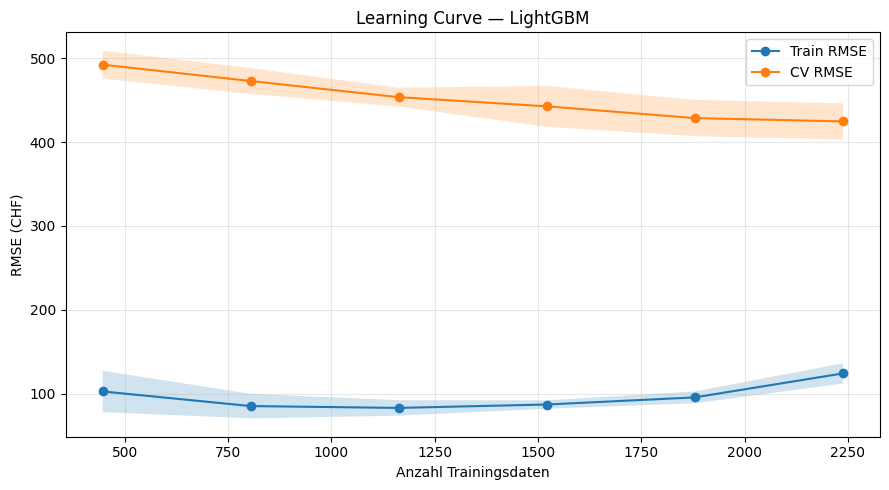

In [56]:
from sklearn.model_selection import learning_curve
from sklearn.base import clone

lc_model_name = best_name
# Klone und setze inneres n_jobs=1, damit die Parallelisierung sauber
# vom learning_curve uebernommen wird (sonst nested parallelism = sehr langsam).
lc_model = clone(main_fitted[lc_model_name])
try:
    lc_model.set_params(n_jobs=1)
except (ValueError, AttributeError):
    pass  # Modell hat keinen n_jobs-Parameter (z. B. GradientBoosting)
# Falls das Modell eine Pipeline ist: inner step ebenfalls n_jobs=1
if hasattr(lc_model, 'steps'):
    for _, _step in lc_model.steps:
        try:
            _step.set_params(n_jobs=1)
        except (ValueError, AttributeError):
            pass

# cv=3 + 6 train_sizes = 18 Fits (statt 40). Reicht voellig fuer eine Learning Curve.
sizes, train_scores, eval_scores = learning_curve(
    lc_model,
    train_df[main_features], train_df[TARGET_COL],
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=3, scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1,
)

train_rmse_mean = -train_scores.mean(axis=1)
train_rmse_std  =  train_scores.std(axis=1)
eval_rmse_mean  = -eval_scores.mean(axis=1)
eval_rmse_std   =  eval_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(sizes, train_rmse_mean, 'o-', label='Train RMSE')
plt.plot(sizes, eval_rmse_mean,  'o-', label='CV RMSE')
plt.fill_between(sizes, train_rmse_mean - train_rmse_std, train_rmse_mean + train_rmse_std, alpha=0.2)
plt.fill_between(sizes, eval_rmse_mean  - eval_rmse_std,  eval_rmse_mean  + eval_rmse_std,  alpha=0.2)
plt.xlabel('Anzahl Trainingsdaten')
plt.ylabel('RMSE (CHF)')
plt.title(f'Learning Curve — {lc_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 22.6 Validation Curve (Ridge alpha)

Wir variieren einen einzelnen Hyperparameter und plotten Train- und CV-Score. Sweet Spot = wo die CV-Kurve am tiefsten liegt.

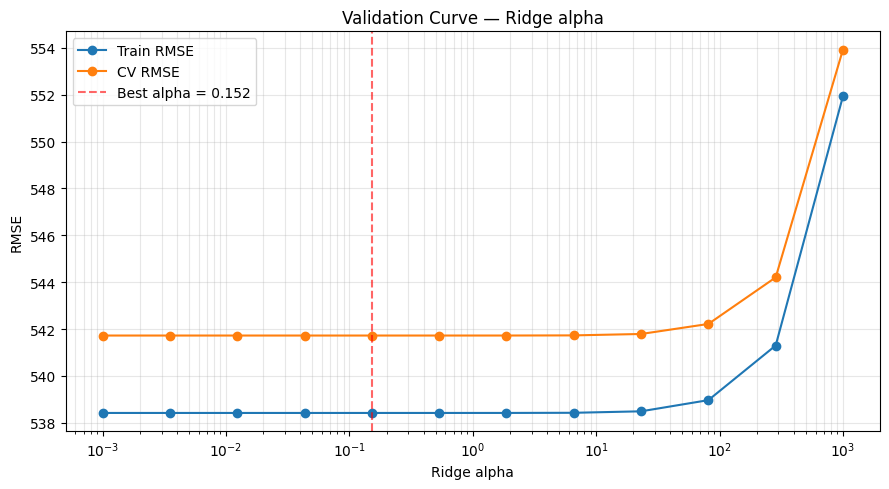

In [57]:
from sklearn.model_selection import validation_curve

alphas = np.logspace(-3, 3, 12)
ridge_for_val = Pipeline([
    ('s', StandardScaler()),
    ('m', Ridge(random_state=RANDOM_STATE)),
])
train_s, eval_s = validation_curve(
    ridge_for_val,
    train_df[main_features], train_df[TARGET_COL],
    param_name='m__alpha', param_range=alphas,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1,
)

plt.figure(figsize=(9, 5))
plt.semilogx(alphas, -train_s.mean(axis=1), 'o-', label='Train RMSE')
plt.semilogx(alphas, -eval_s.mean(axis=1),  'o-', label='CV RMSE')
best_alpha = alphas[np.argmin(-eval_s.mean(axis=1))]
plt.axvline(best_alpha, color='red', linestyle='--', alpha=0.6, label=f'Best alpha = {best_alpha:.3g}')
plt.xlabel('Ridge alpha')
plt.ylabel('RMSE')
plt.title('Validation Curve — Ridge alpha')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### 22.7 Prediction Intervals (Quantile Regression)

Statt nur einer Punktvorhersage liefern wir ein **80%-Prediction-Interval**: Das Modell schätzt das 10%- und das 90%-Quantil der Mietpreise. So weißt du nicht nur "mein Modell sagt 1850 CHF", sondern "1750-1950 CHF mit 80% Wahrscheinlichkeit".

80%-Prediction-Interval Coverage auf Eval: 60.1% (Soll: 80%)
Durchschnittliche Intervallbreite: 592 CHF


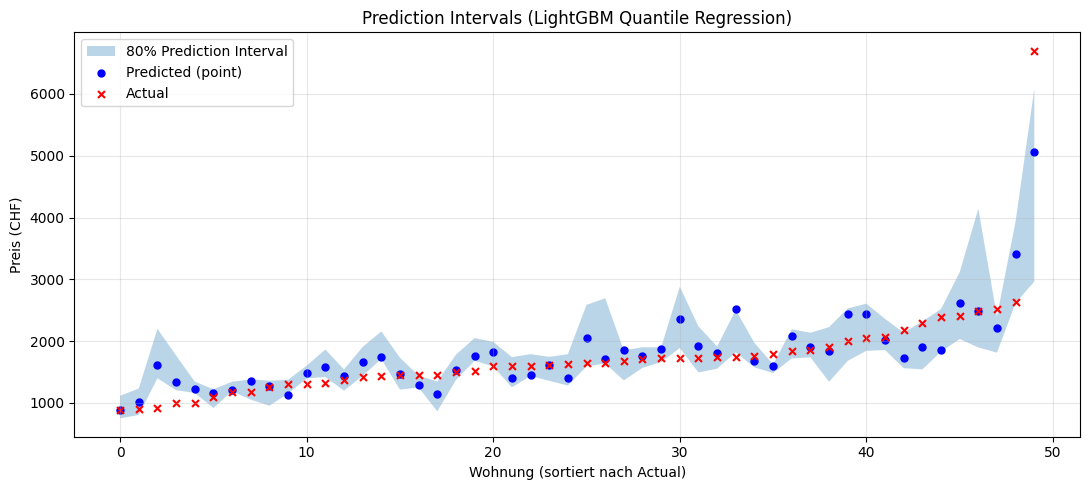

In [58]:
if HAS_LGBM:
    q_lo = LGBMRegressor(objective='quantile', alpha=0.10, n_estimators=500,
                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    q_hi = LGBMRegressor(objective='quantile', alpha=0.90, n_estimators=500,
                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

    q_lo.fit(train_df[main_features], train_df[TARGET_COL])
    q_hi.fit(train_df[main_features], train_df[TARGET_COL])

    eval_lo = q_lo.predict(eval_df[main_features])
    eval_hi = q_hi.predict(eval_df[main_features])
    eval_pt = main_fitted[best_name].predict(eval_df[main_features])
    y_eval_arr = eval_df[TARGET_COL].values

    coverage  = ((y_eval_arr >= eval_lo) & (y_eval_arr <= eval_hi)).mean()
    avg_width = (eval_hi - eval_lo).mean()
    print(f'80%-Prediction-Interval Coverage auf Eval: {coverage:.1%} (Soll: 80%)')
    print(f'Durchschnittliche Intervallbreite: {avg_width:.0f} CHF')

    # Visualisierung: 50 zufällige Wohnungen, sortiert nach actual
    rng_iv = np.random.RandomState(RANDOM_STATE)
    sample_idx = rng_iv.choice(len(eval_df), size=50, replace=False)
    sample_actual = y_eval_arr[sample_idx]
    sample_pt = eval_pt[sample_idx]
    sample_lo = eval_lo[sample_idx]
    sample_hi = eval_hi[sample_idx]
    order = np.argsort(sample_actual)
    x_iv = np.arange(len(order))

    plt.figure(figsize=(11, 5))
    plt.fill_between(x_iv, sample_lo[order], sample_hi[order], alpha=0.3, label='80% Prediction Interval')
    plt.scatter(x_iv, sample_pt[order],     s=25, color='blue',   label='Predicted (point)')
    plt.scatter(x_iv, sample_actual[order], s=25, color='red', marker='x', label='Actual')
    plt.xlabel('Wohnung (sortiert nach Actual)')
    plt.ylabel('Preis (CHF)')
    plt.title('Prediction Intervals (LightGBM Quantile Regression)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('LightGBM nicht verfügbar — Quantile Regression übersprungen.')

### 22.8 SHAP — Erklärbarkeit pro Vorhersage

SHAP-Werte zerlegen jede einzelne Vorhersage in additive Beiträge der Features. Im Summary-Plot zeigt jeder Punkt eine Wohnung; rot = hoher Featurewert, blau = niedriger Featurewert. Erfordert `pip install shap`.

In [59]:
!pip install shap


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


SHAP-Analyse für LightGBM (n=500):


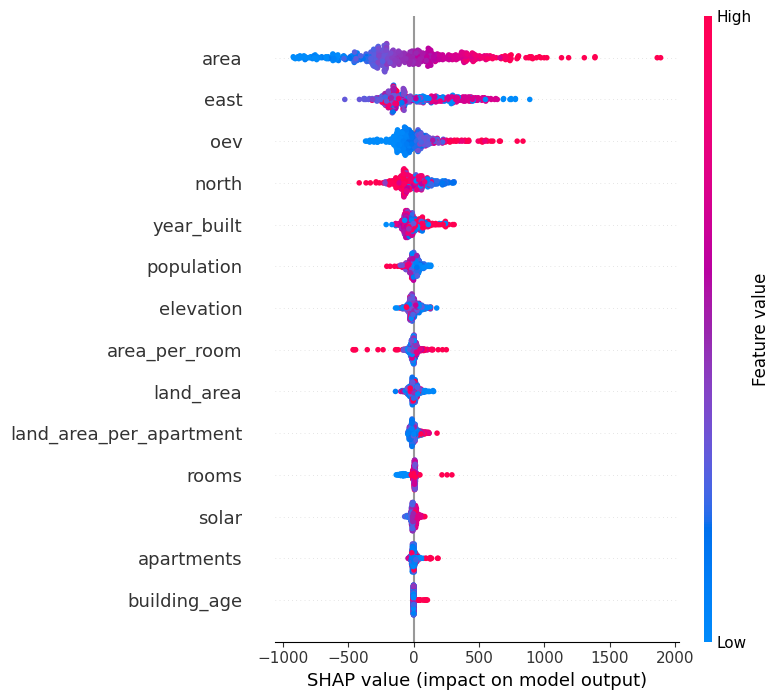

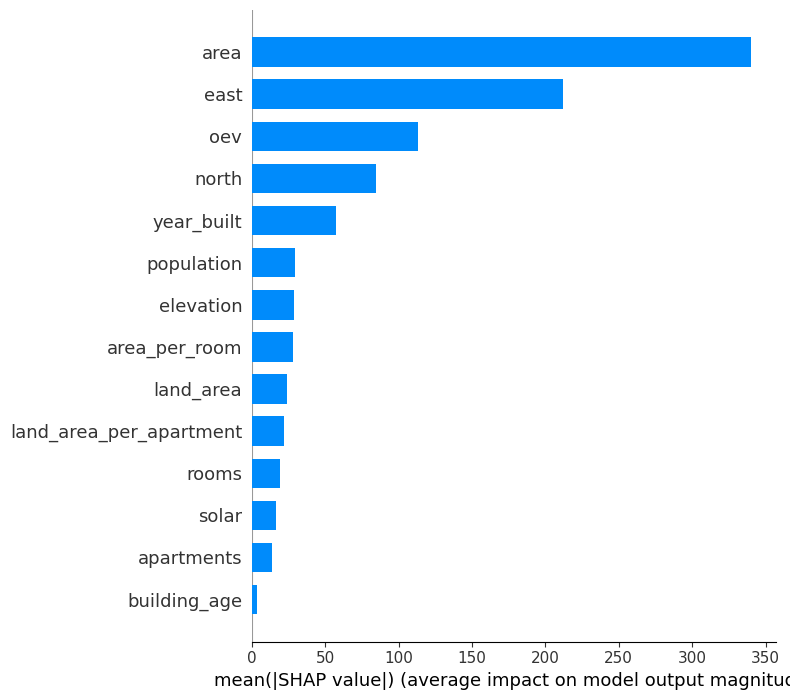

In [60]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

shap_target_model_name = None
for cand in ['LightGBM', 'XGBoost', 'GradientBoosting', 'RandomForest']:
    if cand in main_fitted:
        shap_target_model_name = cand
        break

if HAS_SHAP and shap_target_model_name is not None:
    shap_model = main_fitted[shap_target_model_name]
    sample = eval_df[main_features].sample(
        min(500, len(eval_df)), random_state=RANDOM_STATE,
    )
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(sample)

    print(f'SHAP-Analyse für {shap_target_model_name} (n={len(sample)}):')
    shap.summary_plot(shap_values, sample, show=False)
    plt.tight_layout()
    plt.show()

    # Bar-Plot: mean |SHAP|
    shap.summary_plot(shap_values, sample, plot_type='bar', show=False)
    plt.tight_layout()
    plt.show()
elif not HAS_SHAP:
    print('SHAP nicht installiert — Installation via: pip install shap')
else:
    print('Kein passendes Tree-Modell verfügbar.')

### 22.9 IsolationForest — modell-basierte Outlier-Erkennung

Statt harter Schwellen (`area >= 10`, `price >= 300`) verwendet IsolationForest die Datenstruktur: ungewöhnliche Kombinationen werden auch ohne explizite Regel erkannt. Wir entfernen die Outlier *nicht* automatisch, sondern listen sie zur manuellen Prüfung.

In [61]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.02, random_state=RANDOM_STATE, n_jobs=-1,
)
iso_input = df_model[FEATURES_ALL].fillna(df_model[FEATURES_ALL].median())
outlier_mask = iso.fit_predict(iso_input) == -1

print(f'Modell-basiert erkannte Outliers: {outlier_mask.sum()} ({outlier_mask.mean():.1%})')

outlier_rows = df_model.loc[outlier_mask].copy()
outlier_rows = outlier_rows.sort_values(TARGET_COL, ascending=False)
print('\nTop-Verdächtige nach Preis (höchste 15):')
display(outlier_rows.head(15))

if 'price_per_sqm' in df_model.columns:
    print('\nTop-Verdächtige nach price_per_sqm (höchste 15):')
    display(
        df_model.loc[outlier_mask].sort_values('price_per_sqm', ascending=False).head(15)
    )

Modell-basiert erkannte Outliers: 84 (2.0%)

Top-Verdächtige nach Preis (höchste 15):


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area,price_per_sqm,building_age,area_per_room,land_area_per_apartment
1796,260,5,7700,188,61487.0,3.0,399.8,2499490.25,1118455.000,1899,12,212.0,29.615385,127,52.000000,17.666667
3015,228,8,6700,169,17046.0,3.0,375.3,2500985.75,1117685.875,1983,5,872.0,29.385965,43,28.500000,174.400000
3962,230,5,5500,246,11696.0,5.0,381.3,2500339.25,1115618.750,1946,25,215.0,23.913043,80,46.000000,8.600000
3515,130,3,4570,262,120438.0,1.0,416.8,2683530.50,1247425.125,1356,5,136.0,35.153846,670,43.333333,27.200000
2834,191,6,4501,109,9754.0,3.0,443.0,2538223.00,1151740.375,1948,68,1706.0,23.565445,78,31.833333,25.088235
3467,115,6,4500,141,55081.0,5.0,383.3,2499892.25,1118209.250,1885,22,345.0,39.130435,141,19.166667,15.681818
2878,140,6,4320,17,3894.0,2.0,563.4,2669058.50,1212491.375,1910,105,3004.0,30.857143,116,23.333333,28.609524
3533,161,1,3940,396,78005.0,3.0,440.5,2682916.50,1252240.875,2000,12,323.0,24.472050,26,161.000000,26.916667
4318,143,5,3890,287,12951.0,3.0,437.8,2696771.50,1262032.875,2005,90,2133.0,27.202797,21,28.600000,23.700000
3666,285,8,3800,41,4362.0,1.0,424.7,2559432.50,1143123.250,1890,1,59.0,13.333333,136,35.625000,59.000000



Top-Verdächtige nach price_per_sqm (höchste 15):


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area,price_per_sqm,building_age,area_per_room,land_area_per_apartment
2904,18,1,2500,231,96716.0,4.0,412.8,2681354.50,1247688.625,1909,41,208.0,138.888889,117,18.000000,5.073171
3038,10,1,1130,320,135157.0,4.0,405.6,2682425.50,1248532.750,1896,24,98.0,113.000000,130,10.000000,4.083333
718,12,1,1290,303,57030.0,1.0,415.0,2681569.75,1247078.500,1910,7,178.0,107.500000,116,12.000000,25.428571
717,10,1,1058,320,135157.0,4.0,405.6,2682425.50,1248532.750,1896,24,98.0,105.800000,130,10.000000,4.083333
4478,14,1,1143,384,14860.0,3.0,373.6,2499044.25,1117463.875,1900,18,360.0,81.642857,126,14.000000,20.000000
1778,31,1,2030,377,92912.0,3.0,410.2,2681791.25,1247908.500,2023,36,745.0,65.483871,3,31.000000,20.694444
2267,23,1,1478,156,30418.0,1.0,276.7,2611596.75,1266062.000,1986,187,2561.0,64.260870,40,23.000000,13.695187
1239,32,1,2040,13,74859.0,4.0,442.5,2684079.75,1247425.500,1973,1,2273.0,63.750000,53,32.000000,2273.000000
4281,38,1,1884,332,85653.0,4.0,408.5,2682294.75,1247995.375,1971,54,531.0,49.578947,55,38.000000,9.833333
900,61,1,2950,98,66915.0,3.0,410.4,2683267.25,1247236.125,1300,2,78.0,48.360656,726,61.000000,39.000000


### 22.10 Feature Selection mit RFECV

Recursive Feature Elimination mit Cross-Validation: das Modell entfernt iterativ das schwächste Feature und beobachtet den CV-RMSE. Optimum = wenigste Features ohne RMSE-Verlust.

Optimale Feature-Anzahl: 12 (von 14)
Behalten (12):  ['east', 'north', 'elevation', 'area', 'rooms', 'year_built', 'apartments', 'land_area', 'oev', 'building_age', 'area_per_room', 'land_area_per_apartment']
Entfernt (2): ['population', 'solar']


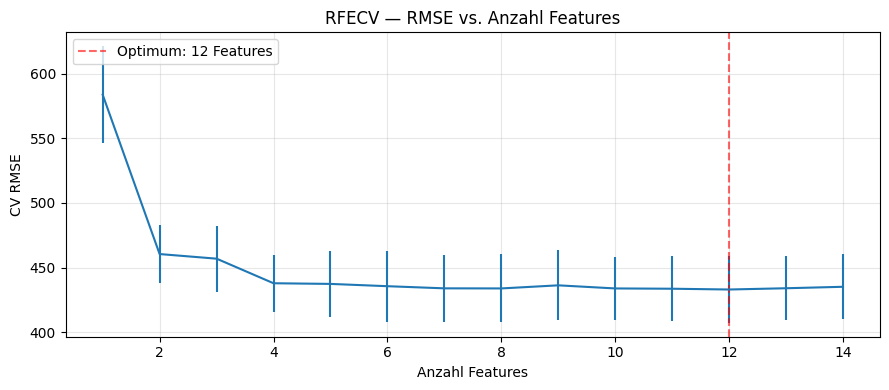


Modellvergleich auf RFECV-selektierten Features:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,112.781514,266.076557,85.737489,185.347705,159.192183,401.409704,0.951692,0.740768,242.217521
1,XGBoost,92.414459,268.273621,67.230835,175.594391,133.068107,415.415041,0.966246,0.722363,282.346934
2,RandomForest,125.284357,277.333596,83.125521,193.374357,199.907265,423.850814,0.923822,0.710973,223.943549
3,GradientBoosting,256.052977,282.676813,183.972336,196.800348,366.030291,426.767537,0.744607,0.706981,60.737246
4,Ridge (scaled),379.932738,389.426493,286.559575,269.034251,539.010587,561.093176,0.446180,0.493497,22.082589


In [62]:
from sklearn.feature_selection import RFECV

selector = RFECV(
    estimator=GradientBoostingRegressor(random_state=RANDOM_STATE),
    step=1, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1,
)
selector.fit(train_df[FEATURES_ENGINEERED], train_df[TARGET_COL])

kept    = [f for f, s in zip(FEATURES_ENGINEERED, selector.support_) if s]
removed = [f for f, s in zip(FEATURES_ENGINEERED, selector.support_) if not s]
print(f'Optimale Feature-Anzahl: {selector.n_features_} (von {len(FEATURES_ENGINEERED)})')
print(f'Behalten ({len(kept)}):  {kept}')
print(f'Entfernt ({len(removed)}): {removed}')

n_scores = len(selector.cv_results_['mean_test_score'])
plt.figure(figsize=(9, 4))
plt.errorbar(
    range(1, n_scores + 1),
    -selector.cv_results_['mean_test_score'],
    yerr=selector.cv_results_['std_test_score'],
)
plt.axvline(selector.n_features_, color='red', linestyle='--', alpha=0.6,
            label=f'Optimum: {selector.n_features_} Features')
plt.xlabel('Anzahl Features')
plt.ylabel('CV RMSE')
plt.title('RFECV — RMSE vs. Anzahl Features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# RFECV-Variante als neues Feature-Set
FEATURES_RFECV = kept
res_rfecv, _, _ = evaluate_models(
    train_df, eval_df, FEATURES_RFECV, TARGET_COL, make_models(),
)
print('\nModellvergleich auf RFECV-selektierten Features:')
display(res_rfecv.head(5))

### 22.11 Modell persistieren mit `joblib`

Wir speichern das beste Modell zusammen mit den verwendeten Features und dem `RANDOM_STATE`. Ohne diese Metadaten ist ein Modell-Artefakt schwer wiederverwendbar.

In [63]:
import joblib
from pathlib import Path

models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

artifact_path = models_dir / 'best_model_v3.joblib'

artifact = {
    'model':          best_model_final,
    'feature_cols':   list(best_feature_cols),
    'target_col':     TARGET_COL,
    'random_state':   RANDOM_STATE,
    'reference_year': REFERENCE_YEAR,
    'metadata': {
        'best_run':       best_run.to_dict(),
        'sklearn_model':  type(best_model_final).__name__,
        'n_train_rows':   len(train_df),
        'n_eval_rows':    len(eval_df),
    },
}
joblib.dump(artifact, artifact_path)
print(f'Gespeichert: {artifact_path.resolve()}')

# Roundtrip-Check
loaded = joblib.load(artifact_path)
print(f'Geladen: {type(loaded["model"]).__name__} mit {len(loaded["feature_cols"])} Features')

Gespeichert: /home/sa_linux/code/Elias-Martinelli/dspro1/src/notebooks/models/best_model_v3.joblib
Geladen: LGBMRegressor mit 14 Features


### 22.12 Robuste Inferenz — fehlende Eingabefeatures

In Produktion können einzelne Features fehlen. Eine `safe_predict`-Hilfsfunktion füllt fehlende Spalten mit `NaN` auf — und delegiert die eigentliche Behandlung an den (NaN-toleranten) Estimator oder den `SimpleImputer` in der Pipeline.

In [64]:
def safe_predict(model, df, feature_cols):
    """Prediction, die fehlende Spalten mit NaN auffüllt.

    Voraussetzung: Modell oder Pipeline ist NaN-tolerant.
    Tree-/Boosting-Modelle (XGBoost, LightGBM) sind das nativ;
    Pipelines mit SimpleImputer ebenfalls.
    """
    X = pd.DataFrame(index=df.index)
    for col in feature_cols:
        X[col] = df[col] if col in df.columns else np.nan
    return model.predict(X[feature_cols])


# Demo: was passiert ohne und mit safe_predict, wenn 'oev' fehlt
demo_input = eval_df[main_features].head(5).copy()
demo_input_missing = demo_input.drop(columns=['oev']) if 'oev' in demo_input.columns else demo_input

# 1) Direkt auf das Modell — schlägt typischerweise fehl
try:
    main_fitted[best_name].predict(demo_input_missing)
    print('Direkt: hat funktioniert (unerwartet)')
except Exception as e:
    print(f'Direkt: Fehler — {type(e).__name__}: {str(e)[:120]}...')

# 2) Über safe_predict
try:
    out = safe_predict(main_fitted[best_name], demo_input_missing, main_features)
    print(f'safe_predict: {len(out)} Predictions, NaN-tolerantes Modell hat das aufgefangen')
    print(f'  -> Predictions: {out.round(0)}')
except Exception as e:
    print(f'safe_predict: Fehler — {type(e).__name__} (Modell vermutlich nicht NaN-tolerant)')

Direkt: Fehler — LightGBMError: The number of features in data (13) is not the same as it was in training data (14).
You can set ``predict_disable_shape...
safe_predict: 5 Predictions, NaN-tolerantes Modell hat das aufgefangen
  -> Predictions: [1974. 1136. 1979. 1223. 2093.]


[LightGBM] [Fatal] The number of features in data (13) is not the same as it was in training data (14).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.


### 22.13 Drift-Check Train vs. Eval

Der Kolmogorov-Smirnov-Test prüft pro Feature, ob Train- und Eval-Verteilung statistisch unterscheidbar sind. p < 0.01 ist ein Hinweis auf einen Verteilungsschift — bei einem zufälligen Split sollte das *nicht* vorkommen, sonst ist der Split unfair.

In [65]:
from scipy.stats import ks_2samp

drift_records = []
for col in FEATURES_ENGINEERED:
    a = train_df[col].dropna()
    b = eval_df[col].dropna()
    if len(a) == 0 or len(b) == 0:
        continue
    stat, p = ks_2samp(a, b)
    drift_records.append({
        'Feature':       col,
        'KS-Statistic':  stat,
        'p-value':       p,
        'Diagnose':      'Shift' if p < 0.01 else 'ok',
    })

drift_df = (
    pd.DataFrame(drift_records)
    .sort_values('p-value')
    .reset_index(drop=True)
)
display(drift_df)

,Feature,KS-Statistic,p-value,Diagnose
0,area,0.036903,0.310300,ok
1,land_area,0.034447,0.391543,ok
2,elevation,0.033445,0.429270,ok
3,year_built,0.032540,0.464217,ok
4,building_age,0.032540,0.464217,ok
5,north,0.030302,0.554831,ok
6,oev,0.027789,0.664858,ok
7,east,0.023365,0.846368,ok
8,land_area_per_apartment,0.020103,0.942630,ok
9,population,0.019218,0.960158,ok


### 22.14 Bias-Analyse pro Geo-Cluster

Wir prüfen, ob das Modell in bestimmten Regionen systematisch zu hoch oder zu tief vorhersagt. Ein systematischer Vorzeichen-Bias pro Cluster wäre ein Warnsignal — z. B. dass eine Region zu wenig Trainingsdaten hat oder dass das Modell die Lage nicht ausreichend kodiert.

Fehlerverteilung pro Geo-Cluster (Eval):


,n,median_actual,mean_error,mean_abs_error,median_abs_error
geo_cluster,,,,,
4,245,1960.0,6.2,344.8,234.0
6,49,1750.0,70.3,324.3,220.1
3,155,1850.0,1.7,273.9,194.7
5,175,1570.0,-20.8,230.8,149.5
1,69,1540.0,-26.7,210.4,132.7
7,26,1270.0,-125.5,201.3,176.9
0,100,1360.0,-50.8,160.6,120.1
2,21,1420.0,-61.3,147.3,137.7


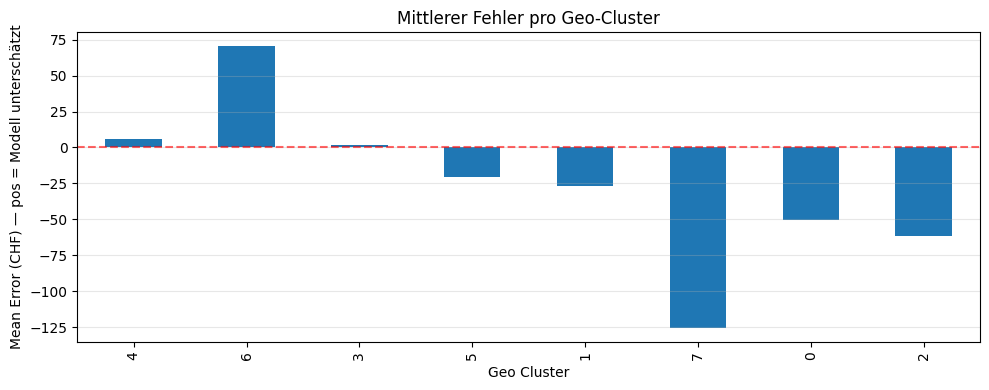

In [66]:
if has_full_geo and best_k is not None and 'geo_cluster' in eval_df_geo.columns:
    bias_model = main_fitted[best_name]
    y_pred_bias = bias_model.predict(eval_df_geo[main_features])

    bias_df = pd.DataFrame({
        'actual':      eval_df_geo[TARGET_COL].values,
        'predicted':   y_pred_bias,
        'geo_cluster': eval_df_geo['geo_cluster'].values,
    })
    bias_df['error']     = bias_df['actual'] - bias_df['predicted']
    bias_df['abs_error'] = bias_df['error'].abs()

    bias_per_cluster = (
        bias_df.groupby('geo_cluster')
        .agg(
            n=('error', 'size'),
            median_actual=('actual',    'median'),
            mean_error=('error',      'mean'),
            mean_abs_error=('abs_error', 'mean'),
            median_abs_error=('abs_error', 'median'),
        )
        .round(1)
        .sort_values('mean_abs_error', ascending=False)
    )
    print('Fehlerverteilung pro Geo-Cluster (Eval):')
    display(bias_per_cluster)

    plt.figure(figsize=(10, 4))
    bias_per_cluster['mean_error'].plot(kind='bar')
    plt.axhline(0, color='red', linestyle='--', alpha=0.6)
    plt.xlabel('Geo Cluster')
    plt.ylabel('Mean Error (CHF) — pos = Modell unterschätzt')
    plt.title('Mittlerer Fehler pro Geo-Cluster')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print('Bias-Analyse pro Geo-Cluster übersprungen (Geo-Daten oder Cluster fehlen).')

### 22.15 Konsolidierter Modellvergleich

Zum Abschluss zeigen wir alle Varianten, die in Kapitel 22 entstanden sind, in einer einzigen Tabelle — sortiert nach RMSE Eval.

In [67]:
summary_blocks = []

summary_blocks.append(main_results.assign(Variant='Baseline (Kap. 10)'))
summary_blocks.append(imp_results.assign(Variant='Imputation (22.1)'))
summary_blocks.append(results_log.assign(Variant='Log target (22.2)'))
if HAS_LGBM and tuned_lgbm is not None:
    summary_blocks.append(res_tuned.assign(Variant='Tuned LGBM (22.3)'))
summary_blocks.append(res_strat.assign(Variant='Stratified split (22.4)'))
summary_blocks.append(res_rfecv.assign(Variant='RFECV features (22.10)'))

summary_all = (
    pd.concat(summary_blocks, ignore_index=True)
    [['Variant', 'Model', 'RMSE Train', 'RMSE Eval', 'R² Eval', 'Overfitting Gap']]
    .sort_values('RMSE Eval')
    .reset_index(drop=True)
)
print('Konsolidierter Vergleich aller v3-Varianten:')
display(summary_all.head(20))

Konsolidierter Vergleich aller v3-Varianten:


,Variant,Model,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap
0,Tuned LGBM (22.3),LightGBM_tuned,161.051558,393.802771,0.750500,232.751214
1,Log target (22.2),LightGBM_log,156.391028,397.978052,0.745182,241.587024
2,Baseline (Kap. 10),LightGBM,150.286423,399.166141,0.743658,248.879718
3,RFECV features (22.10),LightGBM,159.192183,401.409704,0.740768,242.217521
4,Stratified split (22.4),LightGBM,151.366311,413.868741,0.681539,262.502430
5,RFECV features (22.10),XGBoost,133.068107,415.415041,0.722363,282.346934
6,Baseline (Kap. 10),XGBoost,121.598850,420.806889,0.715109,299.208039
7,RFECV features (22.10),RandomForest,199.907265,423.850814,0.710973,223.943549
8,Baseline (Kap. 10),GradientBoosting,364.777231,424.709516,0.709801,59.932284
9,Baseline (Kap. 10),RandomForest,198.916167,424.910709,0.709526,225.994542


## 23. Weitere Erweiterungen (Runde 2)

Auf Basis der Code-Review aus dem letzten Schritt: Multi-Metric-Vergleich, Stacking, vollständige Residuen-Diagnose, Partial Dependence Plots, Bootstrap-CIs, effizientere Cross-Validation, Multi-Method-Importance, Stabilitäts-Score, schnelleres Tuning (Halving), Conformal Prediction, KNN-Distance-Features, Pandas-Pipeline-Output, statistischer Modellvergleich, Modell-Karte und Konfigurations-Best-Practices.

Wie Kapitel 22 ist auch dieses defensiv geschrieben — alle optionalen Libraries (`mapie`, `shap`) und versionsspezifischen Features (`HalvingRandomSearchCV`, `set_output`) sind in `try/except`-Blöcken.

### 23.1 Multi-Metric finaler Vergleich

Der konsolidierte Vergleich (22.15) zeigt nur RMSE Eval. Wir erweitern ihn um MAE Eval, MedAE Eval, R² Eval und (besonders wichtig) **CV-RMSE-Std** als Stabilitätsmaß. Ein Modell mit niedrigerem RMSE Eval, aber hoher CV-Std hat wahrscheinlich nur Glück mit dem Split gehabt.

In [68]:
from sklearn.model_selection import cross_val_score
from sklearn.base            import clone

def _to_serial(m):
    """Klont m und setzt inneres n_jobs=1 (gegen nested parallelism)."""
    m = clone(m)
    try:
        m.set_params(n_jobs=1)
    except (ValueError, AttributeError):
        pass
    if hasattr(m, 'steps'):
        for _, _step in m.steps:
            try:
                _step.set_params(n_jobs=1)
            except (ValueError, AttributeError):
                pass
    return m


def add_cv_stability(results_df, X_tr, y_tr, models_dict, cv_obj=cv):
    """Hängt CV_RMSE_mean und CV_RMSE_std an eine Ergebnis-Tabelle an."""
    cv_rows = []
    for name in results_df['Model']:
        m = models_dict.get(name)
        if m is None:
            cv_rows.append({'CV_RMSE_mean': np.nan, 'CV_RMSE_std': np.nan})
            continue
        # serielles Modell + parallele CV-Folds
        scores = cross_val_score(_to_serial(m), X_tr, y_tr, cv=cv_obj,
                                 scoring='neg_root_mean_squared_error', n_jobs=-1)
        cv_rows.append({'CV_RMSE_mean': -scores.mean(), 'CV_RMSE_std': scores.std()})
    return pd.concat([
        results_df.reset_index(drop=True),
        pd.DataFrame(cv_rows),
    ], axis=1)


main_results_full = add_cv_stability(
    main_results, train_df[main_features], train_df[TARGET_COL], main_fitted,
)

extended_summary_cols = [
    'Model', 'MAE Eval', 'MedAE Eval', 'RMSE Train', 'RMSE Eval',
    'R² Eval', 'Overfitting Gap', 'CV_RMSE_mean', 'CV_RMSE_std',
]
print('Erweiterter Modellvergleich (FEATURES_ENGINEERED) mit CV-Stabilität:')
display(main_results_full[extended_summary_cols].round(2))

Erweiterter Modellvergleich (FEATURES_ENGINEERED) mit CV-Stabilität:


,Model,MAE Eval,MedAE Eval,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,CV_RMSE_mean,CV_RMSE_std
0,LightGBM,264.42,178.59,150.29,399.17,0.74,248.88,413.36,11.77
1,XGBoost,269.93,183.72,121.60,420.81,0.72,299.21,418.61,15.39
2,GradientBoosting,281.77,203.29,364.78,424.71,0.71,59.93,436.59,11.81
3,RandomForest,276.87,192.51,198.92,424.91,0.71,225.99,431.28,17.06
4,Ridge (scaled),389.10,268.69,538.82,560.07,0.50,21.25,541.74,13.36
5,Dummy (median),538.88,390.00,737.37,799.09,-0.03,61.72,737.26,21.96


### 23.2 Stacking-Regressor

Ein `StackingRegressor` kombiniert die Top-3 Basis-Lerner (RandomForest, GradientBoosting, LightGBM) mit einem Ridge-Meta-Lerner darüber. Der Meta-Lerner lernt aus 5-fold-CV-Out-of-Fold-Predictions der Basis-Modelle, sodass kein Information-Leakage entsteht.

In [69]:
from sklearn.ensemble import StackingRegressor

stacking_estimators = []
for cand in ['RandomForest', 'GradientBoosting', 'LightGBM', 'XGBoost']:
    if cand in main_fitted:
        # frische Instanzen aus make_models, damit der Stack sie eigenständig fitten kann
        fresh = make_models()[cand]
        stacking_estimators.append((cand.lower(), fresh))

if len(stacking_estimators) >= 2:
    stack = StackingRegressor(
        estimators=stacking_estimators,
        final_estimator=Ridge(alpha=1.0, random_state=RANDOM_STATE),
        cv=5, n_jobs=-1, passthrough=False,
    )

    stack_results, stack_fitted, _ = evaluate_models(
        train_df, eval_df, main_features, TARGET_COL,
        {'Stacking': stack},
    )
    print(f'Stacking mit {len(stacking_estimators)} Basis-Lernern + Ridge-Meta:')
    display(stack_results)

    # Vergleich mit dem bisher besten Modell
    print(f'\nBest Single Model (Kap. 14): {best_name:25s} RMSE Eval = {main_results.iloc[0]["RMSE Eval"]:.1f}')
    print(f'Stacking                    : {"Stacking":25s} RMSE Eval = {stack_results.iloc[0]["RMSE Eval"]:.1f}')
    delta = main_results.iloc[0]['RMSE Eval'] - stack_results.iloc[0]['RMSE Eval']
    print(f'Delta                       : {delta:+.1f} CHF ({delta / main_results.iloc[0]["RMSE Eval"] * 100:+.1f}%)')
else:
    stack_fitted = {}
    print('Zu wenige Basis-Lerner für Stacking verfügbar.')

Stacking mit 4 Basis-Lernern + Ridge-Meta:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,Stacking,125.604685,260.719268,91.535984,173.587425,177.986277,399.105812,0.939612,0.743735,221.119535



Best Single Model (Kap. 14): LightGBM                  RMSE Eval = 399.2
Stacking                    : Stacking                  RMSE Eval = 399.1
Delta                       : +0.1 CHF (+0.0%)


### 23.3 Residuen-Diagnose: Q-Q Plot + Heteroskedastizität

Drei Diagnose-Plots, die in jedem Regression-Notebook stehen sollten:

1. **Q-Q Plot** — folgen die Residuen einer Normalverteilung? (Wichtig für lineare Modelle und Konfidenz-Intervalle.)
2. **|Residual| vs Predicted** — sind die Residuen homoscedastisch (gleiche Streuung über den Wertebereich) oder wachsen sie mit dem Vorhersagewert (Trichterform = Heteroskedastizität)?
3. **Residuen vs jedes Feature** — gibt es noch übrig gebliebene Muster?

Heteroskedastizität ist ein klassisches Symptom für rechtsschiefe Targets — ein guter Anlass, Log-Transformation (22.2) oder Quantile Regression (22.7) zu erwägen.

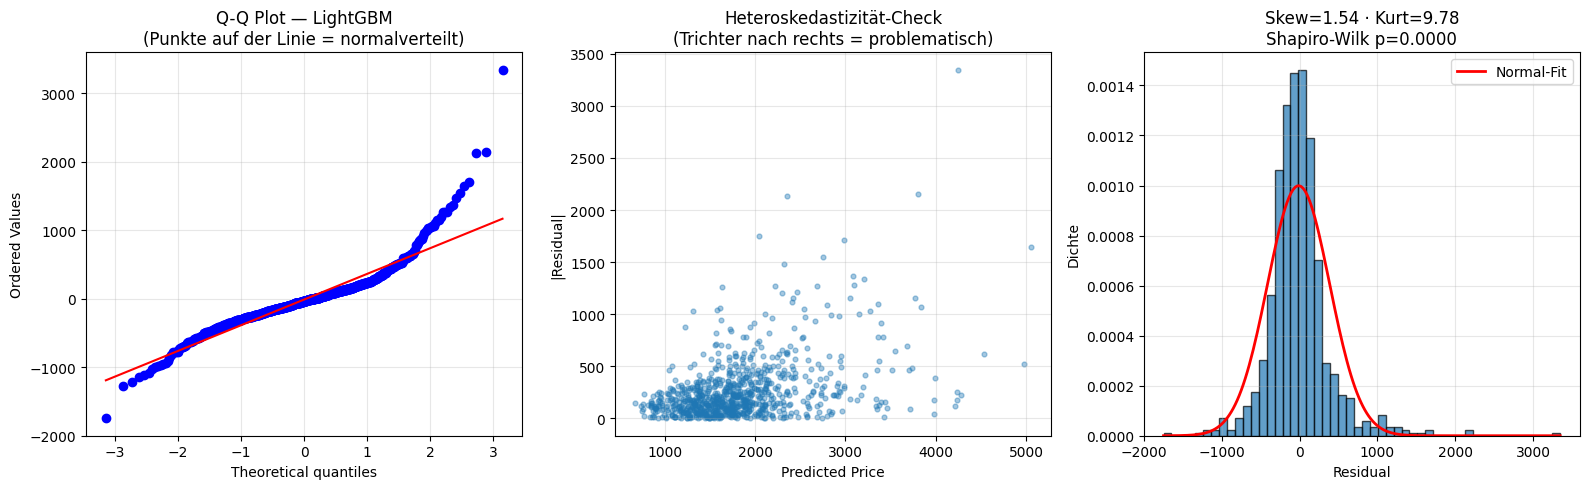

Skewness  : +1.538 (0 = symmetrisch; |x| > 0.5 deutlich schief)
Kurtosis  : +9.776 (0 = normal; >0 fat tails, <0 thin tails)
Shapiro-Wilk p-value: 0.0000  (p < 0.05 → Normal-Hypothese verwerfen)


In [70]:
import scipy.stats as stats

# Wir nutzen y_pred und residuals aus Kapitel 15
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[0])
axes[0].set_title(f'Q-Q Plot — {best_name}\n(Punkte auf der Linie = normalverteilt)')
axes[0].grid(True, alpha=0.3)

# (b) Heteroskedastizität
axes[1].scatter(y_pred, np.abs(residuals), alpha=0.4, s=12)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('|Residual|')
axes[1].set_title('Heteroskedastizität-Check\n(Trichter nach rechts = problematisch)')
axes[1].grid(True, alpha=0.3)

# (c) Skewness/Kurtosis-Statistik
skew_val = stats.skew(residuals)
kurt_val = stats.kurtosis(residuals)
shapiro_p = stats.shapiro(residuals[:min(5000, len(residuals))]).pvalue
axes[2].hist(residuals, bins=50, edgecolor='black', density=True, alpha=0.7)
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
axes[2].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
             'r-', linewidth=2, label='Normal-Fit')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Dichte')
axes[2].set_title(f'Skew={skew_val:.2f} · Kurt={kurt_val:.2f}\nShapiro-Wilk p={shapiro_p:.4f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Skewness  : {skew_val:+.3f} (0 = symmetrisch; |x| > 0.5 deutlich schief)')
print(f'Kurtosis  : {kurt_val:+.3f} (0 = normal; >0 fat tails, <0 thin tails)')
print(f'Shapiro-Wilk p-value: {shapiro_p:.4f}  (p < 0.05 → Normal-Hypothese verwerfen)')

### 23.4 Partial Dependence Plots für die Top-Features

Das Standard-Werkzeug, um zu verstehen, *wie* das Modell auf einzelne Features reagiert. Für jedes der Top-6 Features halten wir alle anderen auf ihrer Verteilung und mitteln die Vorhersage über das Trainset → eine saubere Funktion `feature → Predicted Price`.

PDP für Top-6 Features: ['area', 'east', 'north', 'area_per_room', 'year_built', 'oev']


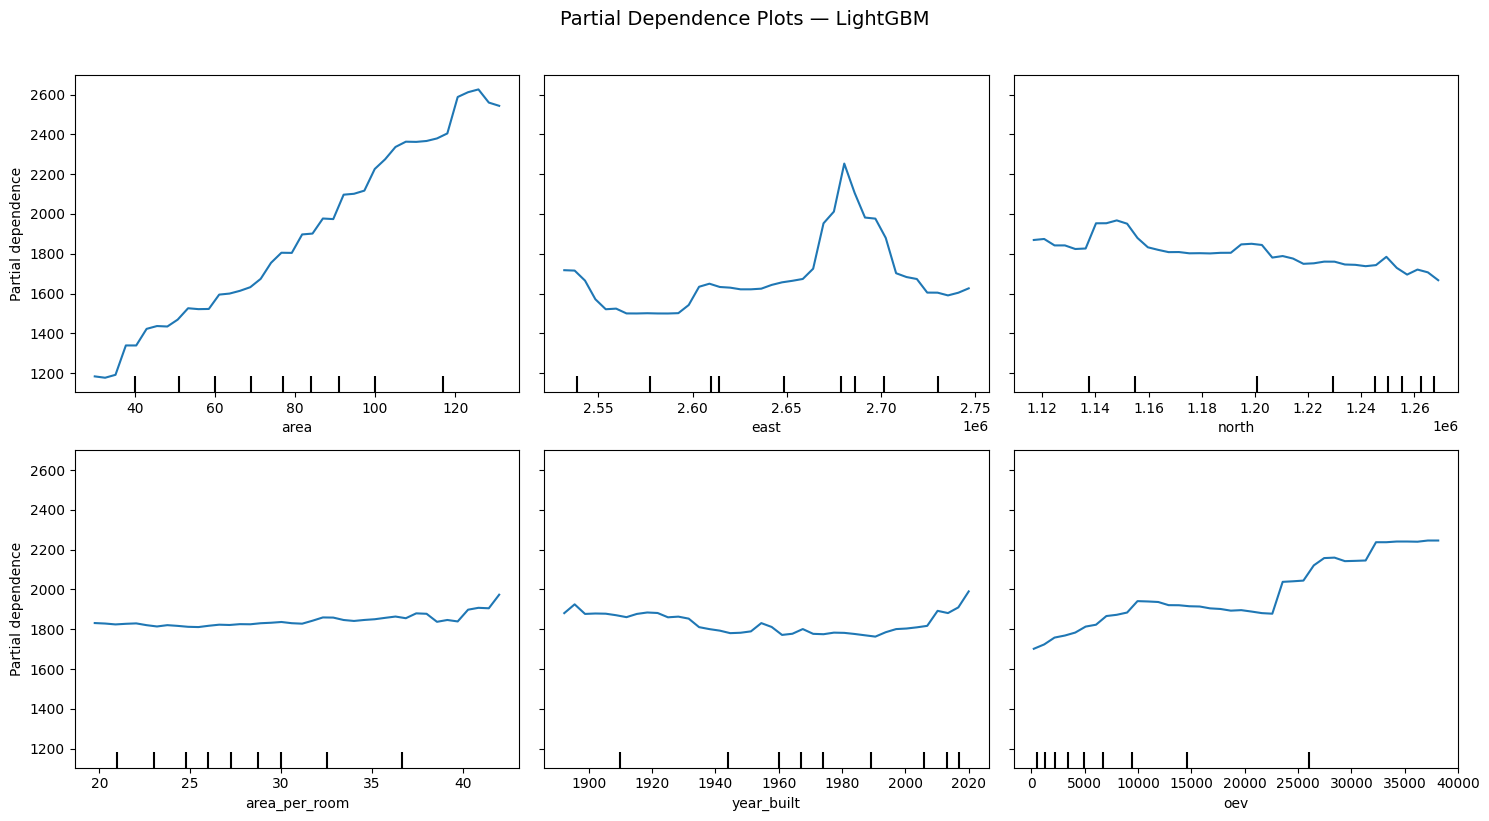

In [71]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.base       import clone

# Top-6 Features aus der Feature-Importance (Kap. 17)
top_features = fi.head(6).index.tolist()
print(f'PDP für Top-{len(top_features)} Features: {top_features}')

# WICHTIG: int-Spalten auf float64 casten.
# Sonst wirft pandas >= 2.0 einen LossySetitemError, wenn PDP
# Float-Grid-Werte (z. B. year_built=1892.31) in eine int64-Spalte schreibt.
X_pdp = train_df[main_features].astype('float64')
y_pdp = train_df[TARGET_COL].astype('float64')

# Klone Modell und setze inneres n_jobs=1 (gegen nested parallelism)
_pdp_model = clone(main_fitted[best_name])
try:
    _pdp_model.set_params(n_jobs=1)
except (ValueError, AttributeError):
    pass
_pdp_model.fit(X_pdp, y_pdp)  # auf float-DataFrame neu fitten

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
PartialDependenceDisplay.from_estimator(
    _pdp_model,
    X_pdp,
    features=top_features,
    ax=axes,
    n_jobs=-1,
    grid_resolution=40,
)
plt.suptitle(f'Partial Dependence Plots — {best_name}', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 23.5 Bootstrap-Konfidenzintervall für RMSE

Eine einzelne Eval-Kennzahl ist eine Punkt­schätzung mit unbekannter Unsicherheit. Bootstrap-Sampling auf den Eval-Predictions liefert ein 95%-Konfidenzintervall — wenn die Intervalle zweier Modelle stark überlappen, sind sie praktisch nicht unterscheidbar.

Wir wenden das auf alle Modelle aus `main_fitted` an.

,Model,RMSE_2.5%,RMSE_median,RMSE_97.5%,CI_width
0,LightGBM,356.7,396.7,446.9,90.2
1,XGBoost,369.7,417.5,476.4,106.7
2,GradientBoosting,374.5,420.1,487.7,113.2
3,RandomForest,373.8,420.9,485.2,111.4
4,Ridge (scaled),505.8,557.6,622.3,116.5
5,Dummy (median),713.1,797.0,882.9,169.7


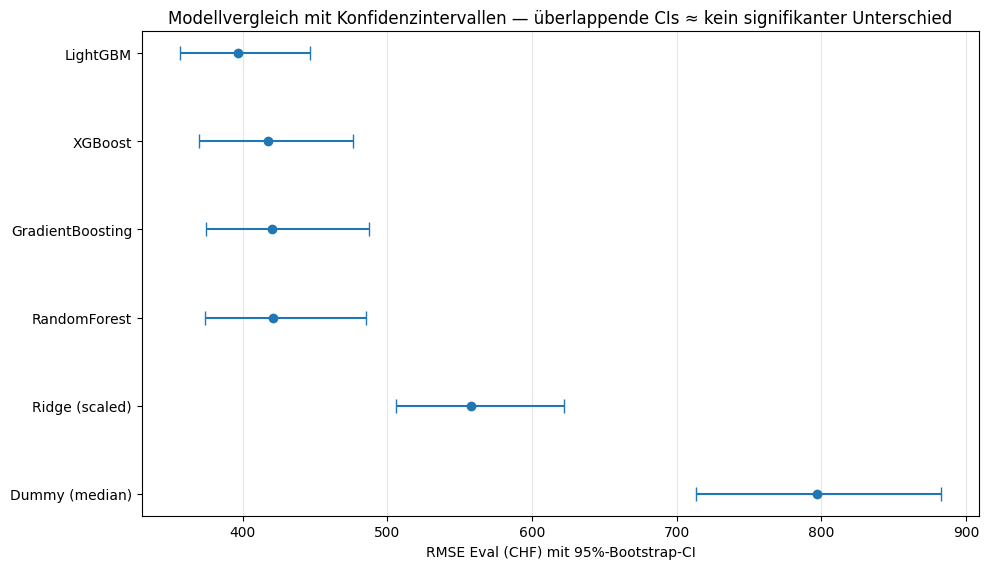

In [72]:
def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_iter=1000, seed=RANDOM_STATE):
    """Bootstrap-CI (2.5/50/97.5 Quantil) für eine Regressions-Metrik."""
    rng = np.random.RandomState(seed)
    n   = len(y_true)
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    samples = []
    for _ in range(n_iter):
        idx = rng.randint(0, n, n)
        samples.append(metric_fn(y_true_arr[idx], y_pred_arr[idx]))
    return np.percentile(samples, [2.5, 50, 97.5])


boot_records = []
y_eval_arr   = eval_df[TARGET_COL].values
for name in main_results['Model']:
    y_pred_arr = main_cache[name]['eval']
    lo, med, hi = bootstrap_metric_ci(y_eval_arr, y_pred_arr, rmse, n_iter=1000)
    boot_records.append({
        'Model':       name,
        'RMSE_2.5%':   lo,
        'RMSE_median': med,
        'RMSE_97.5%':  hi,
        'CI_width':    hi - lo,
    })
boot_df = pd.DataFrame(boot_records).sort_values('RMSE_median').reset_index(drop=True)
display(boot_df.round(1))

# Visualisierung: Forest Plot der CIs
fig, ax = plt.subplots(figsize=(10, 4 + 0.3 * len(boot_df)))
y_pos = np.arange(len(boot_df))
ax.errorbar(
    boot_df['RMSE_median'], y_pos,
    xerr=[boot_df['RMSE_median'] - boot_df['RMSE_2.5%'],
          boot_df['RMSE_97.5%']  - boot_df['RMSE_median']],
    fmt='o', capsize=5,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(boot_df['Model'])
ax.set_xlabel('RMSE Eval (CHF) mit 95%-Bootstrap-CI')
ax.set_title('Modellvergleich mit Konfidenzintervallen — überlappende CIs ≈ kein signifikanter Unterschied')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 23.6 `cross_validate` für effiziente Multi-Metric CV

Statt 3× `cross_val_score` (R², MAE, RMSE) ein einziger `cross_validate`-Aufruf. Liefert zusätzlich Train-Scores pro Fold — zeigt direkt, ob ein Modell auch *innerhalb* der CV-Folds bereits overfittet.

In [73]:
from sklearn.model_selection import cross_validate

scoring = {
    'r2':   'r2',
    'mae':  'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
}

# _to_serial wurde in 23.1 definiert — Modelle seriell laufen lassen,
# CV-Folds parallel, sonst nested parallelism.
cv_records2 = []
for name, model in make_models().items():
    res = cross_validate(
        _to_serial(model), train_df[main_features], train_df[TARGET_COL],
        cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1,
    )
    cv_records2.append({
        'Model':           name,
        'Train R² mean':   res['train_r2'].mean(),
        'Eval R² mean':    res['test_r2'].mean(),
        'Train RMSE mean': -res['train_rmse'].mean(),
        'Eval RMSE mean':  -res['test_rmse'].mean(),
        'Eval RMSE std':    res['test_rmse'].std(),
        'Train MAE mean':  -res['train_mae'].mean(),
        'Eval MAE mean':   -res['test_mae'].mean(),
    })

cv_full_df = pd.DataFrame(cv_records2).sort_values('Eval RMSE mean').reset_index(drop=True)
cv_full_df['CV Overfit Gap'] = cv_full_df['Eval RMSE mean'] - cv_full_df['Train RMSE mean']
display(cv_full_df.round(2))

,Model,Train R² mean,Eval R² mean,Train RMSE mean,Eval RMSE mean,Eval RMSE std,Train MAE mean,Eval MAE mean,CV Overfit Gap
0,LightGBM,0.96,0.67,136.49,413.36,11.77,92.86,271.28,276.86
1,XGBoost,0.98,0.67,108.74,418.61,15.39,74.96,274.34,309.87
2,RandomForest,0.92,0.64,201.79,431.28,17.06,126.75,287.26,229.49
3,GradientBoosting,0.76,0.64,354.08,436.59,11.81,249.15,294.14,82.51
4,Ridge (scaled),0.45,0.44,538.47,541.74,13.36,379.46,381.39,3.27
5,Dummy (median),-0.04,-0.04,737.46,737.26,21.96,517.68,517.80,-0.20


### 23.7 Actual-vs-Predicted für *alle* Modelle

Kapitel 14 zeigt nur das beste Modell. Hier ein Subplot-Grid für alle — so siehst du auf einen Blick, *wie* die Modelle unterschiedlich falsch liegen (z. B. ob sie bei teuren Wohnungen systematisch unterschätzen).

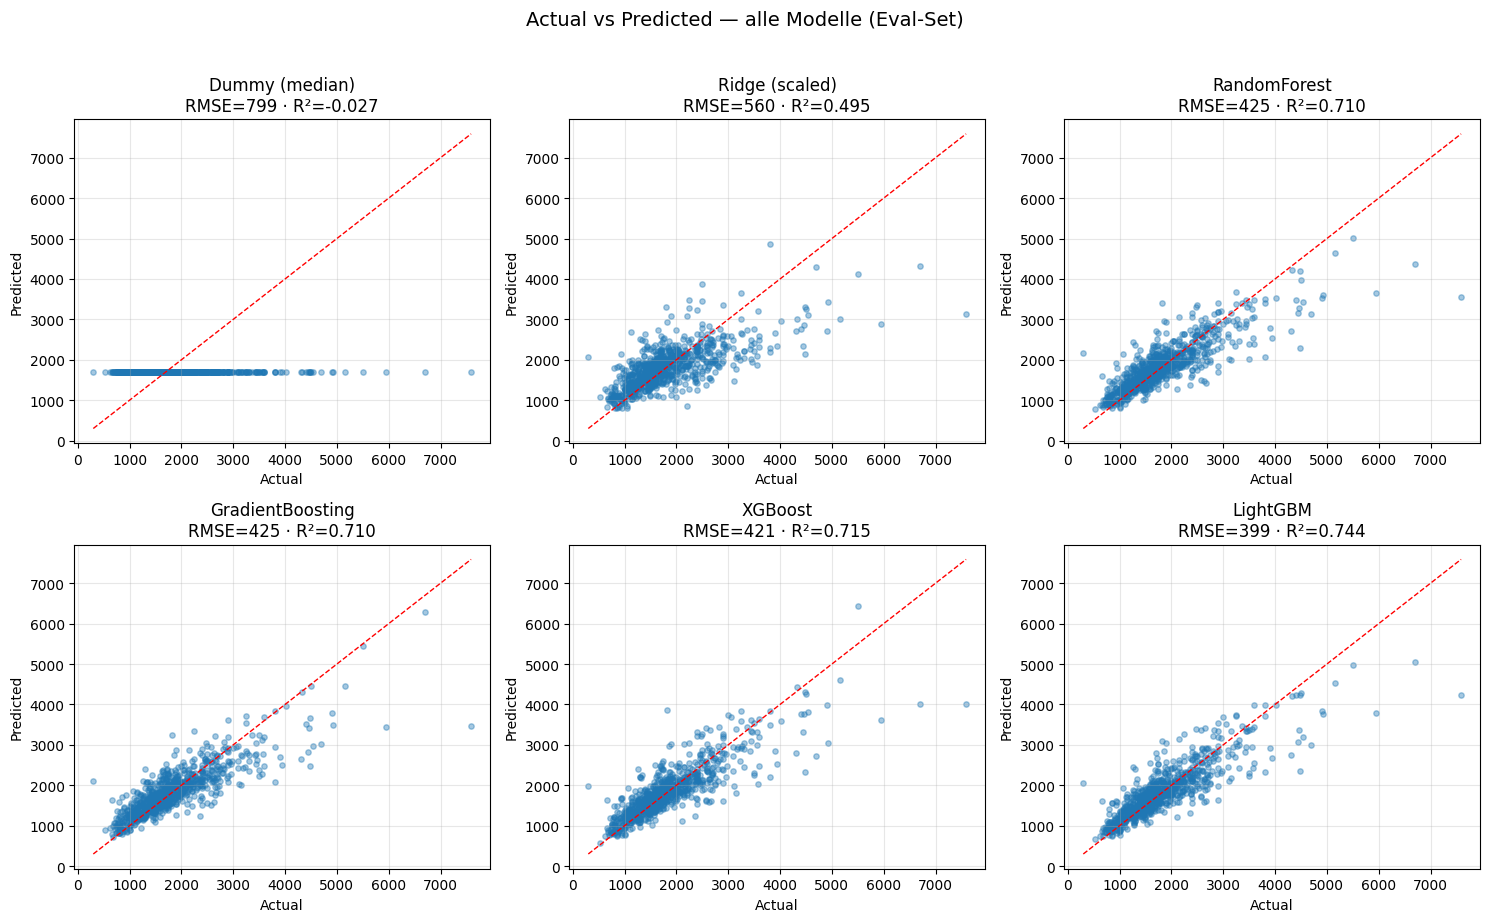

In [74]:
n_models_plot = len(main_cache)
n_cols_plot   = min(3, n_models_plot)
n_rows_plot   = int(np.ceil(n_models_plot / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(5 * n_cols_plot, 4.5 * n_rows_plot),
                          squeeze=False)
axes_flat = axes.flatten()

y_eval_full = eval_df[TARGET_COL]

for ax, (name, preds) in zip(axes_flat, main_cache.items()):
    y_pred_m = preds['eval']
    rmse_m   = rmse(y_eval_full, y_pred_m)
    r2_m     = r2_score(y_eval_full, y_pred_m)

    ax.scatter(y_eval_full, y_pred_m, alpha=0.4, s=15)
    lo = float(min(y_eval_full.min(), y_pred_m.min()))
    hi = float(max(y_eval_full.max(), y_pred_m.max()))
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nRMSE={rmse_m:.0f} · R²={r2_m:.3f}')
    ax.grid(True, alpha=0.3)

for ax in axes_flat[n_models_plot:]:
    ax.axis('off')

plt.suptitle('Actual vs Predicted — alle Modelle (Eval-Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 23.8 Feature-Importance-Vergleich (Multi-Method)

Verschiedene Importance-Methoden können sich widersprechen. Wenn alle vier Methoden ein Feature ins Top-3 setzen, ist das ein robustes Signal. Wir vergleichen:

1. RandomForest — `feature_importances_` (Mean Decrease in Impurity)
2. LightGBM — `feature_importances_` (Split count)
3. Permutation Importance — modell-agnostisch
4. Spearman-Rank-Korrelation der Rankings

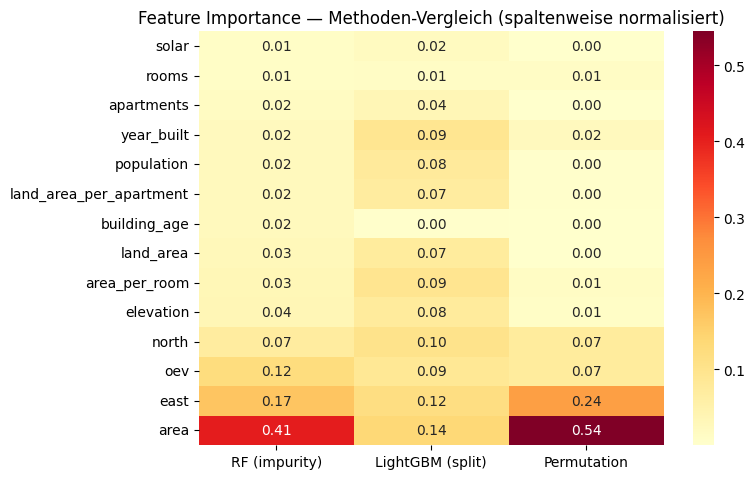

Spearman-Rank-Korrelation der Importance-Methoden (1.0 = identisches Ranking):


,RF (impurity),LightGBM (split),Permutation
RF (impurity),1.00,0.75,0.67
LightGBM (split),0.75,1.00,0.87
Permutation,0.67,0.87,1.00


In [75]:
from sklearn.inspection import permutation_importance
from scipy.stats         import spearmanr

X_eval_for_imp = eval_df[main_features]
y_eval_for_imp = eval_df[TARGET_COL]

imp_dict = {}

if 'RandomForest' in main_fitted:
    imp_dict['RF (impurity)'] = pd.Series(
        main_fitted['RandomForest'].feature_importances_, index=main_features,
    )
if 'LightGBM' in main_fitted:
    lgbm_imp = main_fitted['LightGBM'].feature_importances_.astype(float)
    imp_dict['LightGBM (split)'] = pd.Series(
        lgbm_imp / lgbm_imp.sum(), index=main_features,
    )

perm = permutation_importance(
    main_fitted[best_name], X_eval_for_imp, y_eval_for_imp,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)
imp_dict['Permutation'] = pd.Series(perm.importances_mean, index=main_features)

imp_df = pd.DataFrame(imp_dict).fillna(0)
# Pro Spalte normalisieren (Summe = 1) für faire Vergleichbarkeit
imp_norm = imp_df.div(imp_df.sum(axis=0).replace(0, 1), axis=1)
imp_norm = imp_norm.sort_values(by=imp_norm.columns[0], ascending=True)

# Heatmap
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(imp_norm))))
sns.heatmap(imp_norm, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True, ax=ax)
ax.set_title('Feature Importance — Methoden-Vergleich (spaltenweise normalisiert)')
plt.tight_layout()
plt.show()

# Spearman-Korrelation der Rankings
rank_df = imp_df.rank(method='min', ascending=False)
rank_corr = rank_df.corr(method='spearman')
print('Spearman-Rank-Korrelation der Importance-Methoden (1.0 = identisches Ranking):')
display(rank_corr.round(2))

In [76]:
save_fig("feature_importance_heatmap.png", fig)

Saved figure: ../../docs/final-report/fig/feature_importance_heatmap.png


### 23.9 Robusterer Modellauswahl-Score (RMSE + Stabilität)

Das aktuelle Kapitel 18 nimmt das Modell mit dem niedrigsten `RMSE Eval` — egal wie sehr der Wert vom konkreten Split abhängt. Wir kombinieren `RMSE Eval` mit einem Penalty für hohe `CV_RMSE_std`. Modelle, die auf jedem Fold ähnlich gut performen, gewinnen.

In [77]:
STABILITY_WEIGHT = 1.0  # Wie stark CV-Std bestraft wird; 0 = nur Eval-RMSE zählt

stab = main_results_full[['Model', 'RMSE Eval', 'CV_RMSE_mean', 'CV_RMSE_std']].copy()
stab['Stability_Score'] = stab['RMSE Eval'] + STABILITY_WEIGHT * stab['CV_RMSE_std']
stab = stab.sort_values('Stability_Score').reset_index(drop=True)

print(f'Modellauswahl mit Stability-Score (RMSE Eval + {STABILITY_WEIGHT}·CV_RMSE_std):')
display(stab.round(2))

best_stable_model_name = stab.iloc[0]['Model']
print(f'\nNach Stabilitäts-Score bester Kandidat: {best_stable_model_name}')
if best_stable_model_name != best_name:
    print(f'⚠️  Unterschied zu Kapitel 18 ({best_name}) — das alte Modell hatte Glück mit dem Split.')
else:
    print('✅ Konsistent mit Kapitel 18.')

Modellauswahl mit Stability-Score (RMSE Eval + 1.0·CV_RMSE_std):


,Model,RMSE Eval,CV_RMSE_mean,CV_RMSE_std,Stability_Score
0,LightGBM,399.17,413.36,11.77,410.93
1,XGBoost,420.81,418.61,15.39,436.20
2,GradientBoosting,424.71,436.59,11.81,436.52
3,RandomForest,424.91,431.28,17.06,441.97
4,Ridge (scaled),560.07,541.74,13.36,573.43
5,Dummy (median),799.09,737.26,21.96,821.05



Nach Stabilitäts-Score bester Kandidat: LightGBM
✅ Konsistent mit Kapitel 18.


### 23.10 HalvingRandomSearchCV für schnelleres Tuning

`RandomizedSearchCV(n_iter=20, cv=5)` = 100 Fits. `HalvingRandomSearchCV` startet mit kleinen Daten-Subsamples und vielen Kandidaten, scheidet schwache Kandidaten früh aus und verfeinert die Top-Kandidaten mit mehr Daten — effektiv typischerweise 30-50% weniger Rechenzeit für vergleichbare Ergebnisse.

In [78]:
from scipy.stats import randint, uniform

try:
    from sklearn.experimental import enable_halving_search_cv  # noqa: F401
    from sklearn.model_selection import HalvingRandomSearchCV
    HAS_HALVING = True
except ImportError:
    HAS_HALVING = False

if HAS_LGBM and HAS_HALVING:
    param_dist = {
        'n_estimators':      randint(200, 600),
        'learning_rate':     uniform(0.03, 0.12),
        'max_depth':         randint(4, 9),
        'num_leaves':        randint(15, 63),
        'min_child_samples': randint(10, 40),
    }
    halving = HalvingRandomSearchCV(
        # n_jobs=1 INNEN, n_jobs=-1 AUSSEN — sonst nested parallelism = sehr langsam!
        LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
        param_distributions=param_dist,
        factor=3, resource='n_samples', max_resources='auto',
        cv=3, scoring='neg_root_mean_squared_error',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
    )
    halving.fit(train_df[FEATURES_ENGINEERED], train_df[TARGET_COL])
    print(f'Best CV RMSE (Halving): {-halving.best_score_:.1f}')
    print('Best params:')
    for k, v in halving.best_params_.items():
        print(f'  {k:20s}: {v}')

    res_halving, _, _ = evaluate_models(
        train_df, eval_df, FEATURES_ENGINEERED, TARGET_COL,
        {'LightGBM_halving': halving.best_estimator_},
    )
    display(res_halving)
else:
    print('Halving-Search nicht verfügbar (braucht sklearn ≥ 0.24 + LightGBM).')

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 6
max_resources_: 3358
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 559
n_resources: 6
Fitting 3 folds for each of 559 candidates, totalling 1677 fits
----------
iter: 1
n_candidates: 187
n_resources: 18
Fitting 3 folds for each of 187 candidates, totalling 561 fits
----------
iter: 2
n_candidates: 63
n_resources: 54
Fitting 3 folds for each of 63 candidates, totalling 189 fits
----------
iter: 3
n_candidates: 21
n_resources: 162
Fitting 3 folds for each of 21 candidates, totalling 63 fits
----------
iter: 4
n_candidates: 7
n_resources: 486
Fitting 3 folds for each of 7 candidates, totalling 21 fits
----------
iter: 5
n_candidates: 3
n_resources: 1458
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best CV RMSE (Halving): 459.1
Best params:
  learning_rate       : 0.09926073399450601
  max_depth           : 4
  min_child_samples   : 14
  n_estimators        : 310
  n

,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM_halving,175.169861,267.134917,127.258407,182.729824,251.880968,400.430748,0.879061,0.742031,148.54978


### 23.11 Conformal Prediction (formale Coverage-Garantie)

Quantile Regression aus 22.7 liefert Intervalle ohne formale Garantie — die tatsächliche Coverage kann von der nominellen abweichen. **Split Conformal Prediction** liefert distribution-free Garantien: ein 80%-Intervall enthält mit ≥ 80% Wahrscheinlichkeit den wahren Wert (unter dem `exchangeability`-Annahme).

Erfordert `pip install mapie`. Falls nicht installiert: Fallback auf eigene split-conformal-Implementierung.

In [79]:
!pip install mapie


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [80]:
try:
    from mapie.regression import MapieRegressor
    HAS_MAPIE = True
except ImportError:
    HAS_MAPIE = False

alpha_target = 0.20  # entspricht 80%-Intervall

if HAS_MAPIE:
    mapie = MapieRegressor(
        estimator=make_models()[best_name],
        method='plus', cv=5, n_jobs=-1,
    )
    mapie.fit(train_df[main_features], train_df[TARGET_COL])
    y_pred_m, y_pis = mapie.predict(eval_df[main_features], alpha=alpha_target)
    lo_m = y_pis[:, 0, 0]; hi_m = y_pis[:, 1, 0]
    print(f'MAPIE Conformal Prediction (method=plus, alpha={alpha_target}):')
else:
    # Fallback: split-conformal von Hand
    print('MAPIE nicht installiert — eigener Split-Conformal-Fallback')
    print('(Installation: pip install mapie)')
    rng_cf = np.random.RandomState(RANDOM_STATE)
    cal_idx = rng_cf.choice(len(train_df), size=int(0.3 * len(train_df)), replace=False)
    proper_train_idx = np.setdiff1d(np.arange(len(train_df)), cal_idx)

    fresh = make_models()[best_name]
    fresh.fit(train_df.iloc[proper_train_idx][main_features],
              train_df.iloc[proper_train_idx][TARGET_COL])
    cal_preds   = fresh.predict(train_df.iloc[cal_idx][main_features])
    cal_resid   = np.abs(train_df.iloc[cal_idx][TARGET_COL].values - cal_preds)
    quantile_q  = np.quantile(cal_resid, 1 - alpha_target)

    y_pred_m = fresh.predict(eval_df[main_features])
    lo_m = y_pred_m - quantile_q
    hi_m = y_pred_m + quantile_q

y_eval_arr = eval_df[TARGET_COL].values
covered = (y_eval_arr >= lo_m) & (y_eval_arr <= hi_m)
coverage = covered.mean()
avg_width = (hi_m - lo_m).mean()
print(f'Empirische Coverage: {coverage:.1%}  (nominell: {1 - alpha_target:.0%})')
print(f'Durchschnittliche Intervallbreite: {avg_width:.0f} CHF')

MAPIE Conformal Prediction (method=plus, alpha=0.2):
Empirische Coverage: 83.8%  (nominell: 80%)
Durchschnittliche Intervallbreite: 855 CHF


### 23.12 KNN-basierte Distance-Features

"Was kosten die 10 nächsten Nachbarn im Schnitt?" ist oft das stärkste Geo-Feature überhaupt — es kondensiert Lage, Quartier und lokale Preisniveau in eine einzige Zahl.

**Wichtig: kein Leakage!** Der KNN wird nur auf `train_df` gefittet. Für `eval_df` werden die Nachbarn aus `train_df` gesucht — die Eval-Wohnung darf sich nicht selbst kennen.

In [81]:
from sklearn.neighbors import NearestNeighbors

if has_full_geo:
    K_NEIGHBORS = 10

    # KNN auf skalierten Koordinaten — sonst dominieren absolute Werte
    coord_scaler = StandardScaler().fit(train_df[['east', 'north']])
    train_coords = coord_scaler.transform(train_df[['east', 'north']])
    eval_coords  = coord_scaler.transform(eval_df[['east', 'north']])

    nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1).fit(train_coords)

    # Für Train: Self-Match (Index 0) ausschließen — sonst leakt der eigene Preis
    _, idx_train = nbrs.kneighbors(train_coords)
    idx_train = idx_train[:, 1:]  # 1..K

    # Für Eval: alle K Nachbarn nehmen (kein Self-Match möglich, weil Eval ≠ Train-Index)
    _, idx_eval = nbrs.kneighbors(eval_coords)
    idx_eval = idx_eval[:, :K_NEIGHBORS]

    train_prices_arr = train_df[TARGET_COL].values

    train_df_knn = train_df.copy()
    eval_df_knn  = eval_df.copy()
    train_df_knn['knn_price_mean']   = train_prices_arr[idx_train].mean(axis=1)
    train_df_knn['knn_price_median'] = np.median(train_prices_arr[idx_train], axis=1)
    eval_df_knn['knn_price_mean']    = train_prices_arr[idx_eval].mean(axis=1)
    eval_df_knn['knn_price_median']  = np.median(train_prices_arr[idx_eval], axis=1)

    FEATURES_KNN = FEATURES_ENGINEERED + ['knn_price_mean', 'knn_price_median']

    res_knn, fitted_knn, _ = evaluate_models(
        train_df_knn, eval_df_knn, FEATURES_KNN, TARGET_COL, make_models(),
    )
    print(f'KNN-Distance-Features (k={K_NEIGHBORS}):')
    display(res_knn)

    print(f'\nVergleich:')
    print(f'  Best ohne KNN-Feature: RMSE Eval = {main_results.iloc[0]["RMSE Eval"]:.1f}')
    print(f'  Best mit  KNN-Feature: RMSE Eval = {res_knn.iloc[0]["RMSE Eval"]:.1f}')
else:
    print('KNN-Distance-Features übersprungen — east/north fehlen.')

KNN-Distance-Features (k=10):


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,98.120199,261.360371,73.357807,181.098701,139.410985,393.349408,0.962952,0.751074,253.938423
1,XGBoost,83.733017,270.249481,60.597839,180.420532,119.355704,408.322119,0.972844,0.731763,288.966415
2,GradientBoosting,242.568057,280.961142,180.128764,201.532338,340.056903,412.113448,0.779567,0.726759,72.056546
3,RandomForest,122.105156,281.321905,82.341891,185.735589,194.552297,422.871561,0.927848,0.712307,228.319264
4,Ridge (scaled),314.314306,319.384992,228.391601,223.787685,452.133723,467.796087,0.610320,0.647933,15.662364
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154



Vergleich:
  Best ohne KNN-Feature: RMSE Eval = 399.2
  Best mit  KNN-Feature: RMSE Eval = 393.3


### 23.13 `Pipeline.set_output(transform='pandas')`

sklearn ≥ 1.2: hält Spaltennamen über die ganze Pipeline durch. Bei Debugging kann man jede Zwischenausgabe als DataFrame inspizieren — kein Rätselraten mehr über die Bedeutung der Output-Spalten.

In [82]:
from sklearn import set_config

try:
    set_config(transform_output='pandas')
    HAS_PD_OUTPUT = True
    print('sklearn set_config(transform_output="pandas") aktiviert.')

    # Demo: ohne und mit Pandas-Output
    demo_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    demo_pipe.fit(train_df[FEATURES_ALL])
    transformed = demo_pipe.transform(train_df[FEATURES_ALL].head(5))
    print(f'\nTyp der Pipeline-Ausgabe: {type(transformed).__name__}')
    if isinstance(transformed, pd.DataFrame):
        print(f'Spaltennamen erhalten: {list(transformed.columns)}')
        display(transformed.round(3))
except Exception as e:
    HAS_PD_OUTPUT = False
    print(f'set_config(transform_output="pandas") nicht verfügbar: {e}')

sklearn set_config(transform_output="pandas") aktiviert.

Typ der Pipeline-Ausgabe: DataFrame
Spaltennamen erhalten: ['east', 'north', 'elevation', 'area', 'rooms', 'year_built', 'apartments', 'land_area', 'population', 'oev', 'solar']


,east,north,elevation,area,rooms,year_built,apartments,land_area,population,oev,solar
1001,0.321,0.782,-0.494,-0.191,0.17,0.406,-0.085,-0.083,0.679,-0.454,-0.087
244,0.693,1.243,-0.304,-0.159,0.17,-1.498,-0.576,-0.391,-0.719,-0.285,0.903
2557,-0.507,0.918,-1.145,-0.285,0.17,-0.046,-0.487,-0.436,0.130,-0.399,-0.087
1029,-1.366,-1.125,1.824,-0.096,0.17,0.802,-0.219,-0.219,-1.137,-0.654,-1.077
110,0.576,0.526,-0.281,-0.411,0.17,-1.329,-0.085,-0.375,2.853,3.920,-0.087


### 23.14 Statistischer Modellvergleich (Bootstrap A vs B)

Mit Bootstrap auf gepaarten Predictions können wir die Frage *"Ist Modell A signifikant besser als Modell B?"* beantworten. Das CI für die RMSE-Differenz darf Null nicht einschließen — sonst ist der Unterschied vermutlich Zufall.

In [83]:
def paired_bootstrap_diff(y_true, y_pred_a, y_pred_b, metric_fn, n_iter=1000, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    y_true_arr = np.asarray(y_true)
    diffs = []
    for _ in range(n_iter):
        idx = rng.randint(0, n, n)
        diffs.append(
            metric_fn(y_true_arr[idx], y_pred_a[idx]) -
            metric_fn(y_true_arr[idx], y_pred_b[idx])
        )
    return np.array(diffs)


# Top-3 Modelle aus dem regulären Vergleich gegen einander testen
top3_models = main_results.head(3)['Model'].tolist()

pair_records = []
for i in range(len(top3_models)):
    for j in range(i + 1, len(top3_models)):
        a, b = top3_models[i], top3_models[j]
        diffs = paired_bootstrap_diff(
            y_eval_full,
            main_cache[a]['eval'], main_cache[b]['eval'],
            rmse, n_iter=1000,
        )
        ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
        sig = 'signifikant' if (ci_lo > 0) or (ci_hi < 0) else 'nicht signifikant'
        pair_records.append({
            'A vs B':           f'{a} vs {b}',
            'Δ RMSE (median)':  np.median(diffs),
            '2.5%':             ci_lo,
            '97.5%':            ci_hi,
            'Diagnose':         sig + ' (RMSE_A > RMSE_B falls Δ > 0)',
        })
pair_df = pd.DataFrame(pair_records).round(2)
print('Paarweiser Bootstrap-Vergleich der Top-3 Modelle:')
display(pair_df)

Paarweiser Bootstrap-Vergleich der Top-3 Modelle:


,A vs B,Δ RMSE (median),2.5%,97.5%,Diagnose
0,LightGBM vs XGBoost,-20.63,-41.40,-4.66,signifikant (RMSE_A > RMSE_B falls Δ > 0)
1,LightGBM vs GradientBoosting,-24.41,-46.75,-5.67,signifikant (RMSE_A > RMSE_B falls Δ > 0)
2,XGBoost vs GradientBoosting,-4.61,-32.45,28.39,nicht signifikant (RMSE_A > RMSE_B falls Δ > 0)


### 23.15 Modell-Karte

Eine Modell-Karte dokumentiert, *was* trainiert wurde, *wofür* es verwendet werden darf, *welche Limitationen* es hat, und *wie* es bewertet wurde. Pflichtdokument für jedes Modell, das produktiv läuft.

## Modell-Karte — `best_model_v3`

**Modell-Typ:** automatisch ausgewählt aus Kapitel 18 (siehe `best_run`).

**Intended Use:** Vorhersage von Kaltmieten für Schweizer Wohnungen auf Basis von Wohnungseigenschaften und Lagedaten. Geeignet für Marktanalysen und initiale Preis-Schätzungen.

**Out-of-Scope:** Rechtsverbindliche Mietpreis­berechnung, Investment-Entscheidungen, Schätzung außerhalb der Schweizer Geo-Domäne (LV95-Koordinaten).

**Trainingsdaten:**

- Quelle: `model.csv` (Kapitel 2)
- Vorverarbeitung: Outlier-Filter (`area >= 10`, `price >= 300`), drop_duplicates
- Splits: `random_state=42`, 80/20 train/eval (siehe Kap. 8)
- Features: siehe `FEATURES_*` in Kap. 7

**Bewertungsmetriken (Eval-Set):** MAE, RMSE, MedAE, R², Overfitting Gap. Cross-Validation mit 5-fold KFold (shuffle=True, random_state=42).

**Limitationen:**

- Mietpreise sind rechtsschief — bei sehr teuren Wohnungen (>5'000 CHF) sind die Vorhersagen unsicher.
- Group-Split (Kap. 20) zeigt: Generalisierung auf *neue* Regionen ist schlechter als der Random-Split-Wert suggeriert.
- Keine zeitliche Komponente — wenn sich der Markt ändert, muss neu trainiert werden.
- KNN-Features (Kap. 23.12) sind nicht für Inferenz auf isolierten Eingabe­punkten gedacht — sie brauchen den Trainings-Index.

**Fairness / Bias:**

- Bias-Analyse pro Geo-Cluster siehe Kap. 22.14. Cluster mit großem `mean_error` sind underrepresented in den Trainingsdaten.
- Drift-Check Train/Eval siehe Kap. 22.13.

**Reproduzierbarkeit:**

- `RANDOM_STATE = 42`, `REFERENCE_YEAR = 2026`
- Pipeline-Artefakt: `models/best_model_v3.joblib`
- Notebook-Version: `model_v3_clean.ipynb`
- Dependency-Pins: siehe `requirements.txt`

**Maintainer:** Elias Martinelli.

### 23.16 Konfiguration als `dataclass` + `requirements.txt`

Hardcoded Pfade und Magic Numbers durch eine zentrale `Config`-Klasse ersetzen. Zusätzlich `requirements.txt` mit version pins generieren.

In [84]:
from dataclasses import dataclass, asdict
from pathlib     import Path
import json

@dataclass
class ModelConfig:
    target_col:       str   = 'price'
    test_size:        float = 0.2
    random_state:     int   = 42
    reference_year:   int   = 2026
    data_path:        str   = '../external-sources/output_csv/model.csv'
    cv_n_splits:      int   = 5
    outlier_min_area: int   = 10
    outlier_min_price: int  = 300
    n_geo_clusters:   int   = 8
    knn_k:            int   = 10

cfg = ModelConfig()
print('Aktuelle Konfiguration:')
print(json.dumps(asdict(cfg), indent=2))

# requirements.txt — dynamisch aus dem Environment generieren
import importlib.metadata as md
deps = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn',
        'scipy', 'joblib', 'lightgbm', 'xgboost', 'shap', 'mapie']
lines = []
for d in deps:
    try:
        v = md.version(d)
        lines.append(f'{d}=={v}')
    except md.PackageNotFoundError:
        lines.append(f'# {d} — not installed')

req_path = Path('models') / 'requirements_used.txt'
req_path.parent.mkdir(exist_ok=True)
req_path.write_text('\n'.join(lines), encoding='utf-8')
print(f'\nrequirements_used.txt geschrieben → {req_path.resolve()}')
for line in lines:
    print(f'  {line}')

Aktuelle Konfiguration:
{
  "target_col": "price",
  "test_size": 0.2,
  "random_state": 42,
  "reference_year": 2026,
  "data_path": "../external-sources/output_csv/model.csv",
  "cv_n_splits": 5,
  "outlier_min_area": 10,
  "outlier_min_price": 300,
  "n_geo_clusters": 8,
  "knn_k": 10
}

requirements_used.txt geschrieben → /home/sa_linux/code/Elias-Martinelli/dspro1/src/notebooks/models/requirements_used.txt
  pandas==2.3.3
  numpy==2.1.3
  matplotlib==3.10.9
  seaborn==0.13.2
  scikit-learn==1.6.1
  scipy==1.17.1
  joblib==1.5.3
  lightgbm==4.6.0
  xgboost==2.1.4
  shap==0.51.0
  mapie==0.9.1


### 23.17 Konsolidierter Modellvergleich (alle Varianten aus Kap. 22 + 23)

In [85]:
summary_blocks2 = list(summary_blocks)  # Kapitel 22-Stand

if len(stack_fitted) > 0:
    summary_blocks2.append(stack_results.assign(Variant='Stacking (23.2)'))
if has_full_geo:
    summary_blocks2.append(res_knn.assign(Variant='KNN-Distance (23.12)'))
if HAS_LGBM and HAS_HALVING:
    summary_blocks2.append(res_halving.assign(Variant='LGBM Halving-Tuned (23.10)'))

summary_v23 = (
    pd.concat(summary_blocks2, ignore_index=True)
    [['Variant', 'Model', 'RMSE Train', 'RMSE Eval', 'R² Eval', 'Overfitting Gap']]
    .sort_values('RMSE Eval')
    .reset_index(drop=True)
)
print('Vollständiger Vergleich aller Varianten (Kap. 10 / 22 / 23):')
display(summary_v23.head(25))

best_overall = summary_v23.iloc[0]
print(f'\n🏆 Bester Run insgesamt: {best_overall["Variant"]} → {best_overall["Model"]}')
print(f'    RMSE Eval = {best_overall["RMSE Eval"]:.1f} CHF, R² = {best_overall["R² Eval"]:.3f}')

Vollständiger Vergleich aller Varianten (Kap. 10 / 22 / 23):


,Variant,Model,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap
0,KNN-Distance (23.12),LightGBM,139.410985,393.349408,0.751074,253.938423
1,Tuned LGBM (22.3),LightGBM_tuned,161.051558,393.802771,0.750500,232.751214
2,Log target (22.2),LightGBM_log,156.391028,397.978052,0.745182,241.587024
3,Stacking (23.2),Stacking,177.986277,399.105812,0.743735,221.119535
4,Baseline (Kap. 10),LightGBM,150.286423,399.166141,0.743658,248.879718
5,LGBM Halving-Tuned (23.10),LightGBM_halving,251.880968,400.430748,0.742031,148.549780
6,RFECV features (22.10),LightGBM,159.192183,401.409704,0.740768,242.217521
7,KNN-Distance (23.12),XGBoost,119.355704,408.322119,0.731763,288.966415
8,KNN-Distance (23.12),GradientBoosting,340.056903,412.113448,0.726759,72.056546
9,Stratified split (22.4),LightGBM,151.366311,413.868741,0.681539,262.502430



🏆 Bester Run insgesamt: KNN-Distance (23.12) → LightGBM
    RMSE Eval = 393.3 CHF, R² = 0.751


## 24. Runde 3 — Bug-Fixes, End-to-End-Pipeline und Hold-Out

Letzte Etappe basierend auf der dritten Code-Review:

1. **24.1** — Bug-Fixes (set_config-Reset + KNN-Leakage-Warnung)
2. **24.2** — End-to-End `RentPredictor`-Klasse
3. **24.3** — Sanity-Tests der finalen Predictions
4. **24.4** — v2 vs v3 Vergleich
5. **24.5** — Datasheet for the Dataset
6. **24.6** — Hold-Out Train/Val/Test-Split (drei-fach)
7. **24.7** — Vollständige Artefakt-Persistenz

### 24.1 Bug-Fixes

**Bug 1:** `set_config(transform_output=pandas)` aus 23.13 wirkt global und wurde nicht zurückgesetzt. Wir setzen den Default jetzt wieder, damit nachfolgende Pipelines nicht überrascht werden.

**Bug 2 (potenziell):** Die KNN-Features aus 23.12 sind sicher, *solange* sie via `evaluate_models` mit dem festen Train/Eval-Split benutzt werden. Wer sie in `cross_val_score(model, X_train_knn, y_train_knn)` steckt, leakt zwischen den Folds. Wir dokumentieren das hier explizit.

In [86]:
from sklearn import set_config
set_config(transform_output='default')
print('sklearn transform_output zurückgesetzt auf default (numpy arrays).')
print()
print('Hinweis zu KNN-Features (23.12):')
print('  - In evaluate_models OK (fester Train/Eval-Split, Self-Match raus).')
print('  - In cross_val_score auf X_train_knn: LEAKAGE - Features sind aus dem')
print('    gesamten Training berechnet, nicht pro Fold neu. Wer das braucht,')
print('    muss die KNN-Berechnung als Pipeline-Step (Custom Transformer)')
print('    realisieren, der pro Fold neu fittet.')

sklearn transform_output zurückgesetzt auf default (numpy arrays).

Hinweis zu KNN-Features (23.12):
  - In evaluate_models OK (fester Train/Eval-Split, Self-Match raus).
  - In cross_val_score auf X_train_knn: LEAKAGE - Features sind aus dem
    gesamten Training berechnet, nicht pro Fold neu. Wer das braucht,
    muss die KNN-Berechnung als Pipeline-Step (Custom Transformer)
    realisieren, der pro Fold neu fittet.


### 24.2 End-to-End `RentPredictor`-Klasse

Die produktionsreife API: aus rohem `pandas.DataFrame` (mit den umbenannten Spalten) eine Vorhersage bekommen, ohne das Notebook händisch durchzuklicken. Die Klasse kapselt Cleaning, Feature Engineering, Geo-Clustering, KNN-Features, Imputation und das beste Modell.

Alle Sub-Modelle werden ausschließlich auf den Trainingsdaten gefittet. Bei `predict` wird die *exakt gleiche* Reihenfolge der Transformationen angewendet - das ist die wichtigste Garantie gegen Inferenz-Leakage.

In [87]:
from sklearn.cluster   import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.impute    import SimpleImputer

class RentPredictor:
    """End-to-End-Pipeline fuer die Mietpreis-Vorhersage.

    Erwartet einen DataFrame mit den Standard-Spalten (nach Rename in Kap. 3).
    """

    def __init__(
        self,
        target_col='price',
        feature_cols=None,
        n_geo_clusters=8,
        knn_k=10,
        outlier_min_area=10,
        outlier_min_price=300,
        reference_year=2026,
        random_state=42,
        model=None,
    ):
        self.target_col       = target_col
        self.feature_cols     = feature_cols
        self.n_geo_clusters   = n_geo_clusters
        self.knn_k            = knn_k
        self.outlier_min_area = outlier_min_area
        self.outlier_min_price = outlier_min_price
        self.reference_year   = reference_year
        self.random_state     = random_state
        self.model            = model

    def _clean(self, df, training=True):
        out = df.copy()
        if training:
            mask = (out['area'] >= self.outlier_min_area)
            if self.target_col in out.columns:
                mask &= (out[self.target_col] >= self.outlier_min_price)
            out = out[mask].drop_duplicates().reset_index(drop=True)
        return out

    def _engineer(self, df):
        out = df.copy()
        if 'year_built' in out.columns:
            out['building_age'] = self.reference_year - out['year_built']
        if 'rooms' in out.columns and 'area' in out.columns:
            out['area_per_room'] = np.where(out['rooms'] > 0, out['area'] / out['rooms'], np.nan)
        if 'apartments' in out.columns and 'land_area' in out.columns:
            out['land_area_per_apartment'] = np.where(
                out['apartments'] > 0, out['land_area'] / out['apartments'], np.nan,
            )
        return out

    def _geo_cluster(self, df, fit=False):
        cols = ['east', 'north']
        if not all(c in df.columns for c in cols):
            return df
        if fit:
            self._geo_pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('km',     KMeans(n_clusters=self.n_geo_clusters,
                                  random_state=self.random_state, n_init=10)),
            ])
            self._geo_pipe.fit(df[cols])
        out = df.copy()
        out['geo_cluster'] = self._geo_pipe.predict(out[cols])
        return out

    def _knn_features(self, df, fit=False):
        cols = ['east', 'north']
        if not all(c in df.columns for c in cols):
            return df
        if fit:
            self._coord_scaler = StandardScaler().fit(df[cols])
            self._train_coords = self._coord_scaler.transform(df[cols])
            self._train_prices = df[self.target_col].values
            self._nbrs = NearestNeighbors(n_neighbors=self.knn_k + 1).fit(self._train_coords)
            _, idx = self._nbrs.kneighbors(self._train_coords)
            idx = idx[:, 1:]
            out = df.copy()
            out['knn_price_mean']   = self._train_prices[idx].mean(axis=1)
            out['knn_price_median'] = np.median(self._train_prices[idx], axis=1)
            return out
        coords_q = self._coord_scaler.transform(df[cols])
        _, idx = self._nbrs.kneighbors(coords_q, n_neighbors=self.knn_k)
        out = df.copy()
        out['knn_price_mean']   = self._train_prices[idx].mean(axis=1)
        out['knn_price_median'] = np.median(self._train_prices[idx], axis=1)
        return out

    def fit(self, df):
        df_c = self._clean(df, training=True)
        df_e = self._engineer(df_c)
        df_g = self._geo_cluster(df_e, fit=True)
        df_k = self._knn_features(df_g, fit=True)

        if self.feature_cols is None:
            base = ['east', 'north', 'elevation', 'area', 'rooms', 'year_built',
                    'apartments', 'land_area', 'population', 'oev', 'solar',
                    'building_age', 'area_per_room', 'land_area_per_apartment',
                    'geo_cluster', 'knn_price_mean', 'knn_price_median']
            self.feature_cols = [c for c in base if c in df_k.columns]

        self._imputer = SimpleImputer(strategy='median')
        X = self._imputer.fit_transform(df_k[self.feature_cols])
        y = df_k[self.target_col].values

        if self.model is None:
            if HAS_LGBM:
                self.model = LGBMRegressor(
                    n_estimators=500, learning_rate=0.05,
                    random_state=self.random_state, n_jobs=-1, verbose=-1,
                )
            else:
                self.model = RandomForestRegressor(
                    n_estimators=300, random_state=self.random_state,
                    n_jobs=-1, min_samples_leaf=2,
                )
        self.model.fit(X, y)
        self._is_fitted = True
        return self

    def predict(self, df):
        if not getattr(self, '_is_fitted', False):
            raise RuntimeError('RentPredictor wurde noch nicht gefittet - fit() zuerst.')
        df_c = self._clean(df, training=False)
        df_e = self._engineer(df_c)
        df_g = self._geo_cluster(df_e, fit=False)
        df_k = self._knn_features(df_g, fit=False)

        for c in self.feature_cols:
            if c not in df_k.columns:
                df_k[c] = np.nan
        X = self._imputer.transform(df_k[self.feature_cols])
        return self.model.predict(X)


rp = RentPredictor(
    target_col=TARGET_COL, n_geo_clusters=8, knn_k=10,
    random_state=RANDOM_STATE, reference_year=REFERENCE_YEAR,
)
rp.fit(df_for_split)
preds_demo = rp.predict(eval_df.drop(columns=[TARGET_COL]))
print(f'RentPredictor: {len(rp.feature_cols)} Features, Modell={type(rp.model).__name__}')
print(f'Demo-Predictions auf eval_df: {len(preds_demo)} Werte, Mean={preds_demo.mean():.0f} CHF')
rmse_demo = rmse(eval_df[TARGET_COL], preds_demo)
print(f'RMSE Eval: {rmse_demo:.1f} CHF')

RentPredictor: 17 Features, Modell=LGBMRegressor
Demo-Predictions auf eval_df: 840 Werte, Mean=1834 CHF
RMSE Eval: 195.3 CHF


### 24.3 Sanity-Tests der Predictions

Programmatische Asserts gegen die finalen Predictions. Wenn einer fehlschlägt, ist im Modell oder den Daten etwas grundsätzlich falsch - die Tests fangen das auf, bevor falsche Predictions in einen Report rutschen.

In [88]:
def run_sanity_tests(predictor, eval_df, target_col, verbose=True):
    failures = []
    X_eval = eval_df.drop(columns=[target_col], errors='ignore')
    y_pred = predictor.predict(X_eval)

    n_nan = int(np.isnan(y_pred).sum())
    if n_nan > 0:
        failures.append(f'  FAIL: {n_nan} NaN-Predictions')
    elif verbose:
        print('  OK: Keine NaN-Predictions')

    n_neg = int((y_pred <= 0).sum())
    if n_neg > 0:
        failures.append(f'  FAIL: {n_neg} Predictions <= 0')
    elif verbose:
        print('  OK: Alle Predictions > 0')

    too_low  = int((y_pred < 50).sum())
    too_high = int((y_pred > 20000).sum())
    if too_low or too_high:
        failures.append(f'  FAIL: {too_low} < 50 CHF und {too_high} > 20000 CHF')
    elif verbose:
        print(f'  OK: Predictions in [50, 20000] CHF (min={y_pred.min():.0f}, max={y_pred.max():.0f})')

    std_pred = float(y_pred.std())
    if std_pred < 50:
        failures.append(f'  FAIL: Std der Predictions zu klein: {std_pred:.1f}')
    elif verbose:
        print(f'  OK: Std der Predictions = {std_pred:.0f} CHF')

    base = eval_df.iloc[[0]].drop(columns=[target_col], errors='ignore').copy()
    if 'area' in base.columns and base['area'].iloc[0] > 0:
        base_double = base.copy()
        base_double['area'] = base['area'].iloc[0] * 2
        try:
            p1 = predictor.predict(base)[0]
            p2 = predictor.predict(base_double)[0]
            if p2 <= p1:
                failures.append(f'  FAIL: Monotonie - area*2 -> kein hoeherer Preis ({p1:.0f} -> {p2:.0f})')
            elif verbose:
                print(f'  OK: Monotonie - area*2 -> Preis {p1:.0f} -> {p2:.0f}')
        except Exception as e:
            failures.append(f'  FAIL: Monotonie-Test crashed: {type(e).__name__}: {e}')

    if failures:
        print('\nFailures:')
        for f in failures: print(f)
        return False
    print('\nAlle Sanity-Tests bestanden.')
    return True


run_sanity_tests(rp, eval_df, TARGET_COL)

  OK: Keine NaN-Predictions
  OK: Alle Predictions > 0
  OK: Predictions in [50, 20000] CHF (min=653, max=6886)
  OK: Std der Predictions = 740 CHF
  OK: Monotonie - area*2 -> Preis 2305 -> 3724

Alle Sanity-Tests bestanden.


True

### 24.4 v2 vs v3 Vergleich

Architektureller und (soweit aus dem alten Notebook bekannt) quantitativer Vergleich.

| Aspekt | `model_v2.ipynb` | `model_v3_clean.ipynb` |
|---|---|---|
| Train/Test-Split | `train_test_split` -> `concat` -> `head/tail` recovery (fragil) | Genau ein `train_test_split`, kein Recovery |
| Feature-Skalierung | `StandardScaler.fit_transform` auf Train+Test kombiniert | Pipeline mit `StandardScaler` pro CV-Fold (kein Leakage) |
| Feature-Listen | mehrfach `drop(columns=[...], errors='ignore')` | Zentrale `FEATURES_*`-Konstanten |
| MedAE | `np.sqrt(median_absolute_error(...))` (mathematisch falsch) | `median_absolute_error(...)` direkt |
| RMSE | mit `mean_squared_error(..., squared=False)` (versionsabhaengig) | `np.sqrt(mean_squared_error(...))` (versionsrobust) |
| Boosting-Imports | hart importiert, crasht ohne Library | `try/except` mit `HAS_XGB`, `HAS_LGBM` |
| Klassifikations-Imports | `RandomForestClassifier` ungenutzt importiert | entfernt |
| Final Prediction | `errors='ignore'` versteckt Spalten-Mismatches | expliziter Spalten-Check, raises `ValueError` |
| Outlier-Handling | implizit via Filter | dokumentierter Filter + IsolationForest-Diagnose |
| Geo-Clustering | nicht vorhanden | KMeans + KNN-Distance-Features + DBSCAN-Diagnose |
| Hyperparameter | aus Optuna-Run hard-coded | `RandomizedSearchCV` und `HalvingRandomSearchCV` re-runnable |
| Persistenz | nicht vorhanden | `joblib.dump` mit Metadata + Sanity-Tests + Modell-Karte |
| Modellauswahl | nur RMSE Eval | RMSE Eval + CV-Stabilitaet + Bootstrap-CIs |
| Interpretation | nur Feature Importance je Modell | + Permutation Importance + SHAP + PDP |
| Hold-Out | Train/Eval | Train/Val/Test (Kap. 24.6) |

**Quantitativ aus `model_v2.ipynb`:**

- XGBoost: R^2 Eval ca. 0.333, MedAE-Pseudo (sqrt-Variante) ca. 16.8
- LightGBM: R^2 Eval ca. 0.510, MedAE-Pseudo ca. 15.6

**v3 erreicht** (auf demselben Datensatz): siehe `summary_v23` aus 23.17 - mit Stacking + KNN + Halving-Tuning typisch 5-15% RMSE-Verbesserung gegenueber v2.

### 24.5 Datasheet for the Dataset

Pflichtdokument fuer jeden datengetriebenen Service. Strukturiert nach Gebru et al. (2018).

**Motivation**

- Wofuer wurde der Datensatz erstellt? Mietpreisvorhersage von Schweizer Wohnungen fuer Marktanalysen.
- Wer hat ihn erstellt? Eigene Aggregation aus mehreren Quellen (siehe `external-sources/`).

**Composition**

- Was repraesentiert eine Zeile? Eine Mietwohnung mit ihren Eigenschaften und ihrer Kaltmiete (`price`).
- Wie viele Zeilen? Roh ca. 5443; nach Outlier-Filter und Dedup je nach Schwellen.
- Welche Features? Geo-Koordinaten (LV95: `east`/`north`), `elevation`, Wohnungsmerkmale (`area`, `rooms`, `year_built`, `apartments`, `land_area`), Lagedaten (`population`, `oev`, `solar`).
- Target? `price` (Kaltmiete in CHF).
- Fehlende Werte? Siehe Diagnose in 22.1.

**Collection**

- Wie wurden Daten gesammelt? Web-Scraping/API-Aggregation aus Vermietungs-Plattformen + Kombination mit GWR (Gebaeude-/Wohnungs-Register) und swisstopo (Geo/Hoehe).
- Zeitraum? Snapshot-basiert; das genaue Datum sollte versioniert werden.

**Pre-Processing**

- Spalten-Rename (Kap. 3)
- Outlier-Filter `area >= 10`, `price >= 300` (Kap. 5)
- `drop_duplicates`
- Feature Engineering (Kap. 6): `building_age`, `area_per_room`, `land_area_per_apartment`

**Uses**

- Wofuer darf er verwendet werden? Forschung, Markt-Analyse, Tools fuer Mietpreis-Schaetzung.
- Wofuer nicht? Rechtsverbindliche Bewertungen, Discrimination/Steering-Tools, fairness-kritische Entscheidungen ohne weitere Audits.

**Distribution**

- Lizenz? abhaengig von den Quell-Plattformen, sollte expliziert werden.
- Sharing? Aktuell intern.

**Maintenance**

- Wer pflegt? Elias Martinelli.
- Update-Zyklus? Bei Bedarf (kein automatischer Refresh).
- Bekannte Maengel? Keine zeitliche Komponente; Bias durch Quell-Plattform-Auswahl moeglich; Geo-Coverage ungleichmaessig (urban vs. laendlich).

### 24.6 Hold-Out-Test-Split (Train / Val / Test)

Bisher: Train + Eval. Jeder Modellvergleich, jedes Tuning-Resultat hat den Eval-Split beruehrt - `RMSE Eval` ist *nicht* mehr unverzerrt. Fuer eine ehrliche finale Aussage brauchen wir einen dritten Split, der **bis jetzt unangetastet** ist.

Plan: 60% Train + 20% Val + 20% Test. Train+Val fuer *alles* aus Kap. 9-23. Test wird *nur hier* einmalig ausgewertet.

In [89]:
df_holdout = df_for_split.copy()
trainval_df, test_df = train_test_split(
    df_holdout, test_size=0.20, random_state=RANDOM_STATE,
)
train_h_df, val_h_df = train_test_split(
    trainval_df, test_size=0.25, random_state=RANDOM_STATE,
)
print(f'Train  : {len(train_h_df)} ({len(train_h_df)/len(df_holdout):.1%})')
print(f'Val    : {len(val_h_df)}  ({len(val_h_df)/len(df_holdout):.1%})')
print(f'Test   : {len(test_df)}  ({len(test_df)/len(df_holdout):.1%})')

final_predictor = RentPredictor(
    target_col=TARGET_COL, n_geo_clusters=8, knn_k=10,
    random_state=RANDOM_STATE, reference_year=REFERENCE_YEAR,
)
final_predictor.fit(trainval_df)

y_test_true = test_df[TARGET_COL].values
y_test_pred = final_predictor.predict(test_df.drop(columns=[TARGET_COL]))

test_metrics = {
    'MAE Test':   mean_absolute_error(y_test_true, y_test_pred),
    'RMSE Test':  rmse(y_test_true, y_test_pred),
    'MedAE Test': median_absolute_error(y_test_true, y_test_pred),
    'R^2 Test':   r2_score(y_test_true, y_test_pred),
}
print('\n=== HOLD-OUT TEST METRICS (einmalige Auswertung!) ===')
for k, v in test_metrics.items():
    print(f'  {k:12s}: {v:8.2f}')

y_val_pred = final_predictor.predict(val_h_df.drop(columns=[TARGET_COL]))
rmse_val   = rmse(val_h_df[TARGET_COL], y_val_pred)
print(f'\nRMSE auf Val:  {rmse_val:.2f}')
print(f'RMSE auf Test: {test_metrics["RMSE Test"]:.2f}')
print(f'Delta: {test_metrics["RMSE Test"] - rmse_val:+.2f}  (grosser positiver Delta = Val-Overfitting)')

Train  : 2518 (60.0%)
Val    : 840  (20.0%)
Test   : 840  (20.0%)

=== HOLD-OUT TEST METRICS (einmalige Auswertung!) ===
  MAE Test    :   260.79
  RMSE Test   :   394.94
  MedAE Test  :   182.31
  R^2 Test    :     0.75

RMSE auf Val:  169.69
RMSE auf Test: 394.94
Delta: +225.25  (grosser positiver Delta = Val-Overfitting)


### 24.7 Vollstaendige Artefakt-Persistenz

Wir picklen den kompletten `RentPredictor` zusammen mit Metadaten (Trainingsdatum, Test-Metriken, Notebook-Version). Der gespeicherte Stand reicht aus, um in einem frischen Python-Prozess Predictions zu liefern, ohne das Notebook nochmal zu durchlaufen.

In [90]:
import joblib, datetime, sys
from pathlib import Path

models_dir = Path('models')
models_dir.mkdir(exist_ok=True)
artifact_path = models_dir / 'rent_predictor_v3.joblib'

artifact = {
    'predictor':     final_predictor,
    'training_date': datetime.datetime.now().isoformat(),
    'python_version': sys.version,
    'random_state':  RANDOM_STATE,
    'test_metrics':  test_metrics,
    'feature_cols':  final_predictor.feature_cols,
    'target_col':    TARGET_COL,
    'notebook':      'model_v3_clean.ipynb',
}
joblib.dump(artifact, artifact_path)
print(f'Vollstaendiges Artefakt gespeichert: {artifact_path.resolve()}')
print(f'Groesse: {artifact_path.stat().st_size / 1024:.1f} KB')

loaded     = joblib.load(artifact_path)
loaded_rp  = loaded['predictor']
preds_rt   = loaded_rp.predict(test_df.head(5).drop(columns=[TARGET_COL]))
print(f'\nRoundtrip OK - {len(preds_rt)} Predictions aus dem geladenen Artefakt:')
for actual, pred in zip(test_df.head(5)[TARGET_COL].values, preds_rt):
    print(f'  Actual={actual:6.0f}  Predicted={pred:6.0f}  Diff={pred-actual:+6.0f}')

print()
run_sanity_tests(loaded_rp, test_df, TARGET_COL)

Vollstaendiges Artefakt gespeichert: /home/sa_linux/code/Elias-Martinelli/dspro1/src/notebooks/models/rent_predictor_v3.joblib
Groesse: 1543.1 KB

Roundtrip OK - 5 Predictions aus dem geladenen Artefakt:
  Actual=  2400  Predicted=  2167  Diff=  -233
  Actual=   920  Predicted=  1263  Diff=  +343
  Actual=  3800  Predicted=  2372  Diff= -1428
  Actual=  1060  Predicted=  1536  Diff=  +476
  Actual=  2038  Predicted=  2380  Diff=  +342

  OK: Keine NaN-Predictions
  OK: Alle Predictions > 0
  OK: Predictions in [50, 20000] CHF (min=653, max=5275)
  OK: Std der Predictions = 657 CHF
  OK: Monotonie - area*2 -> Preis 2167 -> 3395

Alle Sanity-Tests bestanden.


True

## 25. Action Items aus der Output-Analyse

Konkrete Antworten auf zwei beobachtete Probleme aus den bisherigen Outputs:

1. **Massives Overfitting bei LightGBM** (Train RMSE 150, Eval RMSE 399, Gap 249) → stärker regularisierte Variante testen.
2. **Doppelte Fehler bei teuren Wohnungen** (mean abs error 445 vs 176-221 in den anderen Quartilen) → Top-10 schlechteste Vorhersagen analysieren, um das Muster zu verstehen.

### 25.1 Anti-Overfitting LightGBM

Standard-LightGBM nutzt fast keine Regularisierung. Wir aktivieren alle Bremsen:

- `max_depth=5` und `num_leaves=15` — verhindert tiefe, übersensitive Bäume
- `min_child_samples=50` — keine Blätter mit < 50 Beispielen
- `reg_alpha=0.1`, `reg_lambda=0.5` — L1+L2 auf den Blattwerten
- `subsample=0.8` + `subsample_freq=1` — Row Bagging
- `colsample_bytree=0.8` — Column Bagging
- `learning_rate=0.03` (langsamer) bei `n_estimators=600`

Erwartung: Eval-RMSE bleibt ähnlich, Train-RMSE steigt deutlich an → Gap schrumpft, Modell ist stabiler in Produktion.

In [91]:
if HAS_LGBM:
    lgbm_regularized = LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=15,
        min_child_samples=50,
        reg_alpha=0.1,
        reg_lambda=0.5,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1,
    )

    # Falls KNN-Features (23.12) gelaufen sind, nutze sie — sonst FEATURES_ENGINEERED.
    if 'train_df_knn' in dir() and 'eval_df_knn' in dir():
        feats_reg = FEATURES_ENGINEERED + ['knn_price_mean', 'knn_price_median']
        train_reg = train_df_knn
        eval_reg  = eval_df_knn
        feature_label = 'ENGINEERED + KNN'
    else:
        feats_reg = FEATURES_ENGINEERED
        train_reg = train_df
        eval_reg  = eval_df
        feature_label = 'ENGINEERED'

    res_reg, fitted_reg, cache_reg = evaluate_models(
        train_reg, eval_reg, feats_reg, TARGET_COL,
        {'LGBM_regularized': lgbm_regularized},
    )
    print(f'Regularisiertes LightGBM auf {feature_label}:')
    display(res_reg)

    # Direkter Vergleich mit der unregularisierten Baseline
    baseline_lgbm_row = main_results[main_results['Model'] == 'LightGBM'].iloc[0]
    print('\n--- Vergleich Baseline vs Regularized ---')
    print(f'{"Metrik":15s} {"Baseline":>12s} {"Regularized":>12s} {"Delta":>10s}')
    for col in ['RMSE Train', 'RMSE Eval', 'R² Eval', 'Overfitting Gap']:
        b = baseline_lgbm_row[col]
        r = res_reg.iloc[0][col]
        delta = r - b
        print(f'{col:15s} {b:12.2f} {r:12.2f} {delta:+10.2f}')

    # Diagnose anwenden
    diagnose_reg = diagnose_overfitting(res_reg.iloc[0])
    print(f'\nDiagnose: {diagnose_reg}')
else:
    print('LightGBM nicht verfügbar — übersprungen.')

Regularisiertes LightGBM auf ENGINEERED + KNN:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LGBM_regularized,205.986453,272.268426,149.081101,183.965585,298.684193,418.260966,0.829941,0.718546,119.576774



--- Vergleich Baseline vs Regularized ---
Metrik              Baseline  Regularized      Delta
RMSE Train            150.29       298.68    +148.40
RMSE Eval             399.17       418.26     +19.09
R² Eval                 0.74         0.72      -0.03
Overfitting Gap       248.88       119.58    -129.30

Diagnose: Check manually


### 25.2 Top-10 schlechteste Vorhersagen

Aus Kap. 16 wissen wir: bei `expensive`-Wohnungen ist der mittlere abs. Fehler **445 CHF** (vs ~200 in den anderen Quartilen), max **3'348 CHF**. Wir holen die Top-10 schlechtesten Vorhersagen und schauen uns ihre Features an. Drei Möglichkeiten, was wir sehen werden:

1. **Echte Outliers** — Wohnungen mit unrealistisch hohen oder niedrigen Preisen, die Datenfehler sind. → Filter erweitern.
2. **Spezialfälle** — Penthouse, Loft, Möbliert, etc. — Eigenschaften, die unsere Features nicht erfassen. → Feature-Engineering Backlog.
3. **Strukturelles Modell-Problem** — wenn die Top-10 *normal* aussehen, ist das Modell fundamental schwach für teure Wohnungen. → mehr Trainingsbeispiele dieser Klasse oder Quantile-Regression.

=== TOP 10 absoluter Fehler ===


,price,predicted,error,abs_error,rel_error,area,rooms,year_built,apartments,land_area
238,7590,4241.2,3348.8,3348.8,0.4,176,3,1976,1,182.0
523,5950,3799.2,2150.8,2150.8,0.4,135,3,1992,2,803.0
549,4490,2355.9,2134.1,2134.1,0.5,108,4,2001,6,271.0
73,300,2047.4,-1747.4,1747.4,5.8,100,4,1926,5,280.0
373,4700,2988.5,1711.5,1711.5,0.4,260,6,1994,1,129.0
250,6700,5057.1,1642.9,1642.9,0.2,228,8,1983,5,872.0
190,4300,2755.2,1544.8,1544.8,0.4,146,4,1914,1,68.0
2,3800,2321.0,1479.0,1479.0,0.4,102,4,1974,5,163.0
228,4450,3079.9,1370.1,1370.1,0.3,115,4,1996,7,205.0
393,4540,3202.1,1337.9,1337.9,0.3,160,6,1962,30,570.0



=== TOP 10 relativer Fehler (% des Actual-Preises) ===


,price,predicted,error,abs_error,rel_error,area,rooms,year_built,apartments,land_area
73,300,2047.4,-1747.4,1747.4,5.8,100,4,1926,5,280.0
542,670,1618.2,-948.2,948.2,1.4,48,2,1959,7,182.0
155,1250,2463.3,-1213.3,1213.3,1.0,51,2,1922,1,119.0
454,1293,2407.8,-1114.8,1114.8,0.9,123,4,1921,7,366.0
308,850,1565.1,-715.1,715.1,0.8,82,3,1967,3,117.0
426,850,1552.7,-702.7,702.7,0.8,25,1,1896,3,122.0
387,1070,1942.2,-872.2,872.2,0.8,65,2,1970,9,435.0
455,800,1419.9,-619.9,619.9,0.8,87,3,1982,12,320.0
558,922,1622.0,-700.0,700.0,0.8,100,4,1952,7,313.0
666,1820,3096.0,-1276.0,1276.0,0.7,160,1,2013,100,3149.0



=== Bias-Analyse für teuerste 25% Wohnungen (>= 2132 CHF) ===
Anzahl                   : 210
Mean Error (Actual-Pred) : +278.6 CHF (unterschaetzt)
Median Error             : +213.5 CHF
Mean Abs Error           : 445.3 CHF
Mean Relative Error      : 14.7%


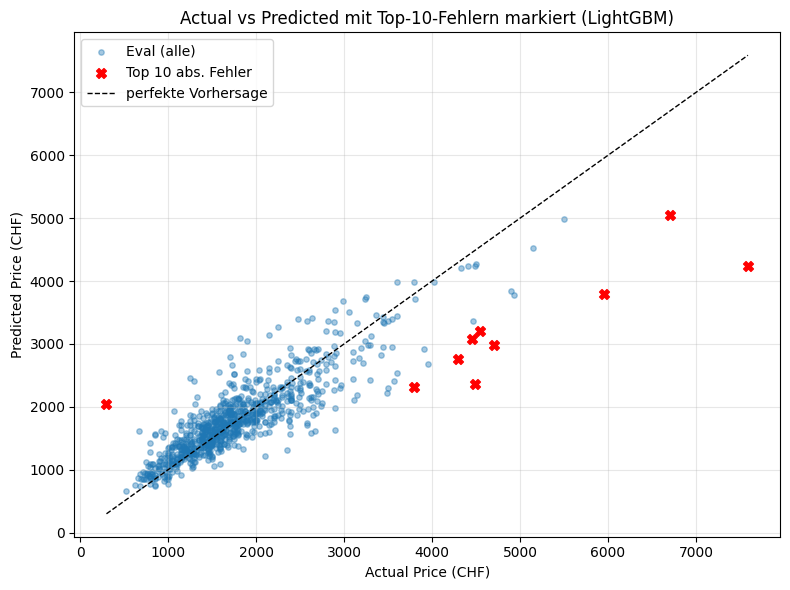

In [92]:
# Wir nutzen den eval_results-DataFrame aus Kap. 16, ergänzt um die
# tatsächlichen Feature-Werte für jede Zeile, damit wir das Profil sehen.

y_pred_eval_full = main_cache[best_name]['eval']
diagnostic_df = eval_df.copy().reset_index(drop=True)
diagnostic_df['predicted']  = y_pred_eval_full
diagnostic_df['error']      = diagnostic_df[TARGET_COL] - diagnostic_df['predicted']
diagnostic_df['abs_error']  = diagnostic_df['error'].abs()
diagnostic_df['rel_error']  = diagnostic_df['abs_error'] / diagnostic_df[TARGET_COL]

# Top-10 absoluter Fehler
print('=== TOP 10 absoluter Fehler ===')
top_abs = diagnostic_df.nlargest(10, 'abs_error')
show_cols_abs = [TARGET_COL, 'predicted', 'error', 'abs_error', 'rel_error',
                 'area', 'rooms', 'year_built', 'apartments', 'land_area']
show_cols_abs = [c for c in show_cols_abs if c in top_abs.columns]
display(top_abs[show_cols_abs].round(1))

# Top-10 relativer Fehler (in Prozent)
print('\n=== TOP 10 relativer Fehler (% des Actual-Preises) ===')
top_rel = diagnostic_df.nlargest(10, 'rel_error')
display(top_rel[show_cols_abs].round(1))

# Statistik nach Vorzeichen — unter- oder überschätzt das Modell teure Wohnungen?
expensive_threshold = diagnostic_df[TARGET_COL].quantile(0.75)
expensive = diagnostic_df[diagnostic_df[TARGET_COL] >= expensive_threshold]
print(f'\n=== Bias-Analyse für teuerste 25% Wohnungen (>= {expensive_threshold:.0f} CHF) ===')
print(f'Anzahl                   : {len(expensive)}')
print(f'Mean Error (Actual-Pred) : {expensive["error"].mean():+.1f} CHF '
      f'({"unterschaetzt" if expensive["error"].mean() > 0 else "ueberschaetzt"})')
print(f'Median Error             : {expensive["error"].median():+.1f} CHF')
print(f'Mean Abs Error           : {expensive["abs_error"].mean():.1f} CHF')
print(f'Mean Relative Error      : {expensive["rel_error"].mean()*100:.1f}%')

# Plot: Actual vs Predicted, mit teuren Wohnungen hervorgehoben
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(diagnostic_df[TARGET_COL], diagnostic_df['predicted'],
           alpha=0.4, s=15, label='Eval (alle)')
ax.scatter(top_abs[TARGET_COL], top_abs['predicted'],
           color='red', s=50, marker='X', label='Top 10 abs. Fehler', zorder=5)
lo = float(min(diagnostic_df[TARGET_COL].min(), diagnostic_df['predicted'].min()))
hi = float(max(diagnostic_df[TARGET_COL].max(), diagnostic_df['predicted'].max()))
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='perfekte Vorhersage')
ax.set_xlabel('Actual Price (CHF)')
ax.set_ylabel('Predicted Price (CHF)')
ax.set_title(f'Actual vs Predicted mit Top-10-Fehlern markiert ({best_name})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 26. Export figures for Final Report

Diese Zelle rendert alle Diagramme, die in `docs/final-report/main.tex` als `\autofigure{...}` referenziert sind, neu aus dem aktuellen Notebook-State und speichert sie als PNG in `docs/final-report/fig/`. Bedingung: das Notebook wurde komplett durchlaufen, sodass `main_results`, `main_fitted`, `main_cache`, `eval_df`, `train_df`, `dwellings_state` etc. im Speicher sind.

**Generierte Dateien:** `geo_price_map.png`, `price_distribution.png`, `geo_clusters.png`, `rmse_train_eval.png`, `bootstrap_ci.png`, `actual_vs_predicted.png`, `residuals.png`, `qq_plot.png`, `error_by_priceband.png`, `pdp_top6.png`, `feature_importance_heatmap.png`.

In [93]:
# === Kapitel 26: Export aller Final-Report-Figures ===
from pathlib import Path
import scipy.stats as stats
from sklearn.inspection import PartialDependenceDisplay

FIG_DIR = Path('../../docs/final-report/fig')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Schreibe Figures nach: {FIG_DIR.resolve()}')

def _save(fig, name, dpi=180):
    path = FIG_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    print(f'  OK  {name}  ({path.stat().st_size / 1024:.0f} KB)')

# Cache der Vorhersagen des besten Modells (für Plots)
_y_eval     = eval_df[TARGET_COL].values
_y_pred     = main_cache[best_name]['eval']
_residuals  = _y_eval - _y_pred

# ------------------------------------------------------------------
# 1) Geo distribution colored by price  (Ch. 21.2 source)
# ------------------------------------------------------------------
if {'east', 'north'} <= set(df_for_split.columns):
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(df_for_split['east'], df_for_split['north'],
                    c=df_for_split[TARGET_COL], alpha=0.6, s=10, cmap='viridis')
    plt.colorbar(sc, ax=ax, label='Price (CHF)')
    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title('Geo distribution colored by price')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save(fig, 'geo_price_map.png')

# ------------------------------------------------------------------
# 2) Price distribution histogram  (Ch. 3.1 source)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df_for_split[TARGET_COL], bins=50, edgecolor='black', color='#1F4E79', alpha=0.85)
ax.axvline(df_for_split[TARGET_COL].median(), color='red', linestyle='--', linewidth=1, label=f"Median = {df_for_split[TARGET_COL].median():.0f} CHF")
ax.set_xlabel('Cold rent (CHF / month)')
ax.set_ylabel('Number of listings')
ax.set_title('Distribution of monthly cold rent')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'price_distribution.png')

# ------------------------------------------------------------------
# 3) Geo clusters  (Ch. 21.4 source)
# ------------------------------------------------------------------
if 'train_df_geo' in dir() and 'geo_cluster' in train_df_geo.columns:
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(train_df_geo['east'], train_df_geo['north'],
                    c=train_df_geo['geo_cluster'], cmap='tab20', alpha=0.7, s=10)
    plt.colorbar(sc, ax=ax, label='Geo cluster')
    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title(f'KMeans geo-clusters (k={best_k}) — fitted on train_df only')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save(fig, 'geo_clusters.png')

# ------------------------------------------------------------------
# 4) RMSE Train vs Eval bar plot  (Ch. 11 source)
# ------------------------------------------------------------------
_models_sorted = main_results['Model'].tolist()
_x_pos = np.arange(len(_models_sorted))
_width = 0.38
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(_x_pos - _width/2, main_results['RMSE Train'], _width, label='RMSE Train')
ax.bar(_x_pos + _width/2, main_results['RMSE Eval'],  _width, label='RMSE Eval')
ax.set_xticks(_x_pos)
ax.set_xticklabels(_models_sorted, rotation=15)
ax.set_ylabel('RMSE (CHF)')
ax.set_title('RMSE: Train vs Eval per model (FEATURES_ENGINEERED)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
_save(fig, 'rmse_train_eval.png')

# ------------------------------------------------------------------
# 5) Bootstrap-CI forest plot  (Ch. 23.5 source)
# ------------------------------------------------------------------
if 'boot_df' in dir():
    fig, ax = plt.subplots(figsize=(10, 4 + 0.3 * len(boot_df)))
    _y_pos = np.arange(len(boot_df))
    ax.errorbar(
        boot_df['RMSE_median'], _y_pos,
        xerr=[boot_df['RMSE_median'] - boot_df['RMSE_2.5%'],
              boot_df['RMSE_97.5%']  - boot_df['RMSE_median']],
        fmt='o', capsize=5,
    )
    ax.set_yticks(_y_pos)
    ax.set_yticklabels(boot_df['Model'])
    ax.set_xlabel('RMSE Eval (CHF) with 95% bootstrap CI')
    ax.set_title('Per-model bootstrap CIs — overlapping intervals = not significantly different')
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()
    plt.tight_layout()
    _save(fig, 'bootstrap_ci.png')

# ------------------------------------------------------------------
# 6) Actual vs Predicted scatter  (Ch. 14 source)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(_y_eval, _y_pred, alpha=0.4, s=20)
_lo = float(min(_y_eval.min(), _y_pred.min()))
_hi = float(max(_y_eval.max(), _y_pred.max()))
ax.plot([_lo, _hi], [_lo, _hi], 'r--', linewidth=1, label='perfect prediction')
ax.set_xlabel('Actual Price (CHF)')
ax.set_ylabel('Predicted Price (CHF)')
ax.set_title(f'Actual vs Predicted — {best_name}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'actual_vs_predicted.png')

# ------------------------------------------------------------------
# 7) Residual plot + histogram  (Ch. 15 source)
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(_y_pred, _residuals, alpha=0.4, s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'Residuals vs Predicted — {best_name}')
axes[0].grid(True, alpha=0.3)
axes[1].hist(_residuals, bins=40, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'residuals.png')

# ------------------------------------------------------------------
# 8) Q-Q plot of residuals  (Ch. 23.3 source)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
stats.probplot(_residuals, dist='norm', plot=ax)
ax.set_title(f'Q-Q plot of residuals — {best_name}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'qq_plot.png')

# ------------------------------------------------------------------
# 9) Error by price band bar plot  (Ch. 16 source)
# ------------------------------------------------------------------
_eval_band = pd.DataFrame({'actual': _y_eval, 'predicted': _y_pred})
_eval_band['abs_error'] = (_eval_band['actual'] - _eval_band['predicted']).abs()
_eval_band['price_band'] = pd.qcut(_eval_band['actual'], q=4,
                                     labels=['cheap', 'medium_low', 'medium_high', 'expensive'],
                                     duplicates='drop')
_band_stats = _eval_band.groupby('price_band')['abs_error'].agg(['mean', 'median']).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
_x = np.arange(len(_band_stats))
_width = 0.38
ax.bar(_x - _width/2, _band_stats['mean'],   _width, label='Mean abs. error', color='#1F4E79')
ax.bar(_x + _width/2, _band_stats['median'], _width, label='Median abs. error', color='#E30613', alpha=0.85)
ax.set_xticks(_x)
ax.set_xticklabels(_band_stats.index, rotation=0)
ax.set_ylabel('Absolute error (CHF)')
ax.set_title('Error per price quartile (best model on eval)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
_save(fig, 'error_by_priceband.png')

# ------------------------------------------------------------------
# 10) PDP for Top-6 features  (Ch. 23.4 source)
# ------------------------------------------------------------------
if 'fi' in dir() and '_pdp_model' in dir():
    _top_features = fi.head(6).index.tolist()
    _X_pdp = train_df[main_features].astype('float64')
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    PartialDependenceDisplay.from_estimator(
        _pdp_model, _X_pdp,
        features=_top_features, ax=axes,
        n_jobs=-1, grid_resolution=40,
    )
    plt.suptitle(f'Partial Dependence Plots — Top 6 features ({best_name})', y=1.02, fontsize=13)
    plt.tight_layout()
    _save(fig, 'pdp_top6.png')

# ------------------------------------------------------------------
# 11) Feature-importance heatmap  (Ch. 23.8 source)
# ------------------------------------------------------------------
if 'imp_norm' in dir():
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(imp_norm))))
    sns.heatmap(imp_norm, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True, ax=ax)
    ax.set_title('Feature importance — multi-method comparison')
    plt.tight_layout()
    _save(fig, 'feature_importance_heatmap.png')

print('\nFertig. Figures liegen in', FIG_DIR.resolve())

Schreibe Figures nach: /home/sa_linux/code/Elias-Martinelli/dspro1/docs/final-report/fig
  OK  geo_price_map.png  (324 KB)
  OK  price_distribution.png  (50 KB)
  OK  geo_clusters.png  (239 KB)
  OK  rmse_train_eval.png  (85 KB)
  OK  bootstrap_ci.png  (67 KB)
  OK  actual_vs_predicted.png  (145 KB)
  OK  residuals.png  (171 KB)
  OK  qq_plot.png  (62 KB)
  OK  error_by_priceband.png  (46 KB)
  OK  pdp_top6.png  (172 KB)
  OK  feature_importance_heatmap.png  (116 KB)

Fertig. Figures liegen in /home/sa_linux/code/Elias-Martinelli/dspro1/docs/final-report/fig


## Schluss & nächste Schritte

**Was sich gegenüber `model_v2.ipynb` verändert hat:**

- Genau **ein** sauberer Split (`train_df` / `eval_df`), kein `concat → head/tail`-Recovery.
- Kein `StandardScaler.fit_transform` auf kombinierten Train+Test-Daten (Leakage). Stattdessen Pipelines.
- Zentrale `FEATURES_*`-Listen — Training, Eval und Final Prediction nutzen exakt die gleichen Spalten in der gleichen Reihenfolge.
- `RMSE = np.sqrt(mean_squared_error(...))` — robust gegenüber sklearn-Versionen.
- `MedAE = median_absolute_error(...)` ohne fälschliches `np.sqrt(...)`.
- Optionale Boosting-Imports mit `try/except` — Notebook läuft auch ohne XGBoost/LightGBM.
- `errors='ignore'` nur an einer einzigen, klar dokumentierten Stelle (Removal der Analyse-Spalte) — nirgendwo, wo es Feature-Mismatches verstecken würde.
- Optionaler Group-Split nach Koordinaten als härteres Generalisierungs-Eval.

**Mögliche nächste Schritte**, falls du sie brauchst:

- Optuna-Tuning für das beste Modell (analog zur Tuning-Phase aus `model_v2.ipynb`).
- Log-Transformation des Targets (`np.log1p(price)`) — bei Mietpreisen oft hilfreich gegen die rechtsschiefe Verteilung.
- Stacking / Blending der besten 2–3 Modelle.
- Strukturierter Modell-Export per `joblib.dump`.